# EVA-CLIP Fine-Tune on COCO GT (1k) + Your SAM Pipeline (200 eval) — v4

**Generated:** 2025-10-21 15:16

- Uses *your* helpers (dynamic α/β, soft mask weighting, EVA-safe encoding, residual fusion).
- Fine-tunes EVA02-L-14 on COCO ground-truth boxes from **1,000 images** (GT only).
- Loads your SAM/RPN/context pipeline from the baseline notebook and **swaps in the fine-tuned EVA**.
- Evaluates on a **disjoint 200-image** val subset using **your SAM** during testing.


In [1]:
# ==== Config ====
# ==== Config ====
import os
COCO_YEAR = "2014"
IMAGES_TRAIN = r"""None"""
IMAGES_VAL   = r"""None"""
TRAIN_ANN    = r"""None"""
VAL_ANN      = r"""/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/annotations/instances_val2014.json"""
OUTPUT_DIR   = r"""./outputs_sam_eva_coco2014"""
CHECKPOINT_DIR = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints"  # directory
SAM_CHECKPOINT = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth"  # file
BASELINE_NOTEBOOK = r"""/home/scs_deal_projects_notapebackup/user/shubhang/thesis/notebooks/COCO_SAM_EVA_RPN_ZeroShot.ipynb"""
SAM_CHECKPOINT = r"""/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth"""

# EVA02 defaults — correct OpenCLIP tags
EVA_MODEL_NAME = "EVA02-L-14"          # or "EVA02-L-14-336"
EVA_PRETRAINED_TAG = "merged2b_s4b_b131k"  # or "merged2b_s6b_b61k" for 336

# Train/Eval sizes
NUM_TRAIN_IMAGES = 10000
NUM_EVAL_IMAGES  = 500

# Fine-tune hyperparams
BATCH_SIZE = 64
NUM_EPOCHS = 10
LR = 5e-6
WEIGHT_DECAY = 0.05
GRAD_CLIP_NORM = 1.0
WARMUP_STEPS = 100
SEED = 42

# Finetune data options
PAD_RATIO_CROP = 0.08
USE_GT_MASK_SOFT_WEIGHT = True   # use coco annToMask inside crops for soft weighting (closer to your inference flow)

# Testing pipeline config stub (keys your code expects)
CONFIG = {
    "OUT_DIR": OUTPUT_DIR,
    "COCO_ROOT": os.path.dirname(os.path.dirname(TRAIN_ANN)) if "annotations" in TRAIN_ANN else os.path.dirname(IMAGES_TRAIN),
    "SPLIT": os.path.basename(IMAGES_VAL.rstrip("/")) or "val2014",
    "RPN_SCORE_THRESH": 0.5,
    "RPN_NMS_IOU": 0.7,
    "RPN_TOPK": 300,
    "SAM_MAX_SIDE": 1024,
    "USE_FP16_SAM": True,
    "MATCH_IOU_THRESH": 0.5,
    "PADDING_RATIOS": [0.0, 0.05, 0.10, 0.15]
}

# ---- Robust path normalization (handles when CHECKPOINT_DIR was accidentally a .pth file) ----
def _is_ckpt_file(p): p=(p or "").lower(); return p.endswith(".pt") or p.endswith(".pth")
if os.path.isfile(OUTPUT_DIR): OUTPUT_DIR = os.path.dirname(OUTPUT_DIR) or os.getcwd()
if _is_ckpt_file(CHECKPOINT_DIR):
    if not SAM_CHECKPOINT: SAM_CHECKPOINT = CHECKPOINT_DIR
    CHECKPOINT_DIR = os.path.dirname(CHECKPOINT_DIR) or os.getcwd()
if os.path.isfile(CHECKPOINT_DIR): CHECKPOINT_DIR = os.path.dirname(CHECKPOINT_DIR) or os.getcwd()

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("✓ Config ready")
print(" OUTPUT_DIR   =", OUTPUT_DIR)
print(" CHECKPOINT_DIR=", CHECKPOINT_DIR)
print(" SAM_CHECKPOINT=", SAM_CHECKPOINT or "(none)")

✓ Config ready
 OUTPUT_DIR   = ./outputs_sam_eva_coco2014
 CHECKPOINT_DIR= /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints
 SAM_CHECKPOINT= /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth


In [2]:
# ==== Imports ====
import os, json, math, random, time, re, gc, inspect
from datetime import datetime
from typing import List, Tuple, Dict
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import open_clip
from pycocotools.coco import COCO

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
seed_everything(SEED)
device

/home/scs_deal_projects_notapebackup/user/shubhang/thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

In [3]:
# ==== COCO + util helpers ====
PROMPT_TEMPLATES = [
    "a photo of a {}",
    "a close-up of a {}",
    "a cropped photo of a {}",
    "a bright photo of a {}",
    "a low-light photo of a {}",
    "a rendering of a {}",
]

def build_class_mappings(coco: COCO):
    cats = coco.loadCats(coco.getCatIds())
    cat_id_to_name = {c["id"]: c["name"] for c in cats}
    unique_ids = sorted(cat_id_to_name.keys())
    cat_id_to_idx = {cid: i for i, cid in enumerate(unique_ids)}
    return cat_id_to_name, cat_id_to_idx

def sample_image_ids(coco: COCO, n: int, exclude_ids: set = None):
    img_ids = coco.getImgIds()
    if exclude_ids: img_ids = [i for i in img_ids if i not in exclude_ids]
    random.shuffle(img_ids); return img_ids[:n]

def crop_with_padding(img: Image.Image, bbox, pad_ratio=0.08) -> Image.Image:
    x, y, w, h = bbox
    W, H = img.size
    pad_w, pad_h = int(w * pad_ratio), int(h * pad_ratio)
    x0 = max(int(x) - pad_w, 0); y0 = max(int(y) - pad_h, 0)
    x1 = min(int(x + w) + pad_w, W); y1 = min(int(y + h) + pad_h, H)
    return img.crop((x0, y0, x1, y1))

In [4]:
# ==== Your EVA helpers (override) ====

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

def dynamic_alpha_from_box(box, img_w, img_h, a_min=0.05, a_max=0.20):
    x1, y1, x2, y2 = box
    frac = ((x2 - x1) * (y2 - y1)) / (img_w * img_h)
    return a_max - (a_max - a_min) * min(1.0, max(0.0, frac))

def dynamic_beta_from_box(box, img_w, img_h, b_min=0.05, b_max=0.25):
    x1, y1, x2, y2 = box
    frac = ((x2 - x1) * (y2 - y1)) / (img_w * img_h)
    return b_max - (b_max - b_min) * min(1.0, max(0.0, frac))

def safe_mask_crop(mask, bbox, img_w, img_h):
    xmin, ymin, xmax, ymax = map(int, bbox)
    xmin = max(0, xmin); ymin = max(0, ymin)
    xmax = min(img_w, xmax); ymax = min(img_h, ymax)
    return mask[ymin:ymax, xmin:xmax]

def apply_soft_mask_weighting(crop_pil, mask_crop_bool):
    crop = np.array(crop_pil).astype(np.float32)
    if mask_crop_bool.dtype != np.bool_:
        mask_crop_bool = mask_crop_bool.astype(bool)
    h_img, w_img = crop.shape[:2]
    h_m, w_m = mask_crop_bool.shape[:2]
    if (h_img != h_m) or (w_img != w_m):
        m = Image.fromarray(mask_crop_bool.astype(np.uint8) * 255).resize(
            (w_img if w_img > 0 else w_img, h_img if h_img > 0 else h_img),
            resample=Image.NEAREST,
        )
        mask_crop_bool = (np.array(m) > 127)
    h_m, w_m = mask_crop_bool.shape[:2]
    h = min(h_img, h_m); w = min(w_img, w_m)
    crop = crop[:h, :w]; mask_crop_bool = mask_crop_bool[:h, :w]
    mask3 = np.repeat(mask_crop_bool[..., None], 3, axis=-1)
    mean_color = crop.mean(axis=(0, 1), keepdims=True)
    blended = crop * mask3 + mean_color * (1 - mask3)
    blended = np.clip(blended, 0, 255).astype(np.uint8)
    return Image.fromarray(blended)

@torch.no_grad()
def encode_image_safe(model, preprocess, img_pil, device):
    model_dtype = next(model.parameters()).dtype
    x = preprocess(img_pil).unsqueeze(0).to(device=device, dtype=model_dtype)
    feat = model.encode_image(x)
    feat = F.normalize(feat, dim=-1).float()
    return feat

@torch.no_grad()
def classify_crop_with_eva_context_fusion_residual(
    crop_pil,
    context_pil,
    model,
    preprocess,
    text_embeds,
    text_feat_mean,
    alpha=0.1,
    beta=0.15,
    device="cuda",
):
    obj_feat    = encode_image_safe(model, preprocess, crop_pil,    device)
    global_feat = encode_image_safe(model, preprocess, context_pil, device)
    scene_fused = F.normalize(obj_feat + beta * (global_feat - obj_feat), dim=-1)
    fused_feat  = F.normalize(scene_fused + alpha * (text_feat_mean.float() - scene_fused), dim=-1)
    sims  = fused_feat @ text_embeds.float().T.to(device)
    probs = sims.softmax(dim=-1)[0]
    pred_idx = int(probs.argmax().item())
    return pred_idx, float(probs[pred_idx].item()), alpha, beta


In [5]:
# ==== Dataset for FT (GT-box crops; optional GT-mask soft weighting) ====
class CocoRegionClipDataset(Dataset):
    def __init__(self, coco: COCO, images_dir: str, image_ids: List[int], class_id_to_name: Dict[int, str], preprocess, pad_ratio=0.08, use_gt_mask_soft_weight=True):
        self.coco = coco; self.images_dir = images_dir
        self.image_ids = image_ids; self.class_id_to_name = class_id_to_name
        self.preprocess = preprocess; self.pad_ratio = pad_ratio; self.use_gt_mask_soft_weight = use_gt_mask_soft_weight
        self.samples = []  # (image_path, bbox_xywh, class_name, ann_id)
        for img_id in self.image_ids:
            anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id], iscrowd=False))
            if not anns: continue
            info = coco.loadImgs([img_id])[0]
            img_path = os.path.join(self.images_dir, info["file_name"])
            for ann in anns:
                cid = ann["category_id"]; cname = self.class_id_to_name.get(cid, None)
                if not cname: continue
                bbox = ann["bbox"]; self.samples.append((img_path, bbox, cname, ann["id"]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        try:
            img_path, bbox, cname, ann_id = self.samples[idx]
            image = Image.open(img_path).convert("RGB")

        # ---- padded crop box from bbox + pad_ratio ----
        # bbox = (x, y, w, h) in COCO format (float ok)
            x, y, w, h = bbox
            pad_w = w * float(self.pad_ratio)
            pad_h = h * float(self.pad_ratio)
            x0_pad = x - pad_w * 0.5
            y0_pad = y - pad_h * 0.5
            x1_pad = x + w + pad_w * 0.5
            y1_pad = y + h + pad_h * 0.5

        # ---- clamp to image bounds, ensure non-zero area ----
            W, H = image.size
            x0, y0, x1, y1 = clamp_box(x0_pad, y0_pad, x1_pad, y1_pad, W, H)
            if (x1 - x0) < 1 or (y1 - y0) < 1:
                return None  # degenerate, drop sample

        # ---- crop region and (optional) mask crop ----
            region = image.crop((x0, y0, x1, y1))

            mask_crop = None
            if self.use_gt_mask_soft_weight:
                ann = self.coco.loadAnns([ann_id])[0]
            # annToMask -> HxW uint8 {0,1}
                mask_full = self.coco.annToMask(ann).astype(np.uint8)
            # crop mask with the same clamped coords
                mask_crop = mask_full[y0:y1, x0:x1]

            # fuse region with mask using dynamic α,β
                region = apply_soft_mask_weighting(region, mask_crop)

        # ---- preprocess -> tensor ----
            image_tensor = self.preprocess(region)
            return image_tensor, cname

        except Exception:
        # optional: print(f"[WARN] bad sample at idx {idx}: {e}")
            return None


In [6]:
# ==== Load EVA02 + preprocess ====
# free any leftover VRAM before building the model
import torch, open_clip
torch.cuda.empty_cache()

use_bf16 = (torch.cuda.is_available() and torch.cuda.is_bf16_supported())
precision = "bf16" if use_bf16 else "fp16"  # saves a LOT of VRAM vs fp32

# ↓ replace your old load call with this:
model, _, preprocess = open_clip.create_model_and_transforms(
    EVA_MODEL_NAME,
    pretrained=EVA_PRETRAINED_TAG,
    device="cuda",            # keep on GPU but in mixed precision
    precision=precision,      # **key change**
    # optional extra squeeze if needed:
    # force_image_size=224,   # uncomment to reduce memory further
)
tokenizer = open_clip.get_tokenizer(EVA_MODEL_NAME)


print("Loading model:", EVA_MODEL_NAME, "pretrained:", EVA_PRETRAINED_TAG)
model, _, preprocess = open_clip.create_model_and_transforms(
    EVA_MODEL_NAME, pretrained=EVA_PRETRAINED_TAG, device=device
)
tokenizer = open_clip.get_tokenizer(EVA_MODEL_NAME)
if hasattr(model, "visual") and hasattr(model.visual, "set_grad_checkpointing"):
    try: model.visual.set_grad_checkpointing(enable=True)
    except Exception: pass
model = model.to(device).float()
clip_model = model            # aliases to match your code
clip_preprocess = preprocess
print("✓ EVA model ready")

Loading model: EVA02-L-14 pretrained: merged2b_s4b_b131k
✓ EVA model ready


In [7]:
# --- Manual COCO paths (set these explicitly) ---

IMAGES_TRAIN = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/train2014"
IMAGES_VAL   = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/val2014"

TRAIN_ANN = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/annotations/instances_train2014.json"
VAL_ANN   = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/annotations/instances_val2014.json"

# (Optional but recommended) also pin these so later cells don’t guess wrong:
OUTPUT_DIR     = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/outputs_sam_eva_coco2014"
CHECKPOINT_DIR = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints"
SAM_CHECKPOINT = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth"

# EVA02 correct tag (fixes the earlier RuntimeError)
EVA_MODEL_NAME     = "EVA02-L-14"          # or "EVA02-L-14-336"
EVA_PRETRAINED_TAG = "merged2b_s4b_b131k"  # or "merged2b_s6b_b61k" for 336px variant

# --- Sanity checks & safe dirs ---
import os
for p in [IMAGES_TRAIN, IMAGES_VAL, TRAIN_ANN, VAL_ANN]:
    assert os.path.exists(p), f"Path not found: {p}"

# If CHECKPOINT_DIR accidentally points to a file, fix it.
if os.path.isfile(CHECKPOINT_DIR):
    CHECKPOINT_DIR = os.path.dirname(CHECKPOINT_DIR) or os.getcwd()

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("OK: COCO + paths pinned")
print("  IMAGES_TRAIN:", IMAGES_TRAIN)
print("  IMAGES_VAL:  ", IMAGES_VAL)
print("  TRAIN_ANN:   ", TRAIN_ANN)
print("  VAL_ANN:     ", VAL_ANN)
print("  OUTPUT_DIR:  ", OUTPUT_DIR)
print("  CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("  SAM_CHECKPOINT:", SAM_CHECKPOINT)
print("  EVA:", EVA_MODEL_NAME, "| tag:", EVA_PRETRAINED_TAG)


OK: COCO + paths pinned
  IMAGES_TRAIN: /home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/train2014
  IMAGES_VAL:   /home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/val2014
  TRAIN_ANN:    /home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/annotations/instances_train2014.json
  VAL_ANN:      /home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/annotations/instances_val2014.json
  OUTPUT_DIR:   /home/scs_deal_projects_notapebackup/user/shubhang/thesis/outputs_sam_eva_coco2014
  CHECKPOINT_DIR: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints
  SAM_CHECKPOINT: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth
  EVA: EVA02-L-14 | tag: merged2b_s4b_b131k


In [8]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [9]:
import numpy as np
from PIL import Image

def clamp_box(x0, y0, x1, y1, W, H):
    # ensure integers, in-bounds, and at least 1px area
    x0 = int(np.floor(x0)); y0 = int(np.floor(y0))
    x1 = int(np.ceil(x1));  y1 = int(np.ceil(y1))
    x0 = np.clip(x0, 0, max(0, W-1))
    y0 = np.clip(y0, 0, max(0, H-1))
    x1 = np.clip(max(x1, x0+1), 1, W)
    y1 = np.clip(max(y1, y0+1), 1, H)
    return x0, y0, x1, y1

def safe_resize_mask(mask_crop, target_hw):  # (H, W)
    Ht, Wt = target_hw
    if mask_crop is None:
        return np.zeros((Ht, Wt), dtype=np.uint8)
    if mask_crop.ndim == 3:
        mask_crop = mask_crop[..., 0]
    if mask_crop.size == 0:
        return np.zeros((Ht, Wt), dtype=np.uint8)
    h, w = mask_crop.shape[:2]
    if h < 1 or w < 1:
        return np.zeros((Ht, Wt), dtype=np.uint8)
    pil = Image.fromarray((mask_crop > 0).astype(np.uint8) * 255)
    pil = pil.resize((Wt, Ht), resample=Image.NEAREST)  # PIL expects (W,H)
    return np.array(pil, dtype=np.uint8)

def apply_soft_mask_weighting(region_pil, mask_crop, alpha=None, beta=None):
    # region_pil: PIL.Image crop; mask_crop: 2D array (Hc,Wc) or None
    W, H = region_pil.size
    m_uint8 = safe_resize_mask(mask_crop, (H, W))
    m = (m_uint8 > 127).astype(np.float32)

    # simple dynamic schedule; ok to replace with your version
    if alpha is None or beta is None:
        fg_ratio = float(m.mean())
        alpha = 0.2 + 0.6 * (1 / (1 + np.exp(-10*(fg_ratio-0.2))))
        beta  = 1.0 - 0.5 * fg_ratio

    img = np.array(region_pil).astype(np.float32)
    if img.ndim == 2:
        img = img[..., None]
    m3 = m[..., None]
    fused = alpha * (img * m3) + beta * (img * (1.0 - m3))
    fused = np.clip(fused, 0, 255).astype(np.uint8)
    return Image.fromarray(fused.squeeze() if fused.shape[2] == 1 else fused)

# collate that drops bad/None samples
from torch.utils.data._utils.collate import default_collate
def drop_none_collate(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return default_collate(batch)


## COCO

In [10]:
train_coco = COCO(TRAIN_ANN)
val_coco   = COCO(VAL_ANN)

catid_to_name, cat_id_to_idx = build_class_mappings(train_coco)
cat_names = sorted(list(set(catid_to_name.values())))

train_img_ids = sample_image_ids(train_coco, NUM_TRAIN_IMAGES, exclude_ids=None)
val_img_ids_for_eval = sample_image_ids(val_coco, NUM_EVAL_IMAGES, exclude_ids=None)

train_ds = CocoRegionClipDataset(
    train_coco, IMAGES_TRAIN, train_img_ids, catid_to_name,
    preprocess, pad_ratio=PAD_RATIO_CROP, use_gt_mask_soft_weight=USE_GT_MASK_SOFT_WEIGHT
)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, drop_last=True,
    collate_fn=drop_none_collate, persistent_workers=False
)

# ====== PRECOMPUTE TEXT FEATURES (device-safe) ======
# Ensure model.text and toks are on the SAME device during caching
if hasattr(model, "text"):
    orig_text_device = next(model.text.parameters()).device
else:
    orig_text_device = device  # fallback

# If training on GPU, temporarily move text tower to GPU for faster caching
if device == "cuda" and str(orig_text_device).startswith("cpu"):
    model.text = model.text.to(device)

text_device = next(model.text.parameters()).device if hasattr(model, "text") else device
n_templates = len(PROMPT_TEMPLATES)

with torch.inference_mode():
    text_feats_cache = {}  # cname -> [n_templates, D] (normalized)
    for cname in cat_names:
        toks = tokenizer([tmpl.format(cname) for tmpl in PROMPT_TEMPLATES]).to(text_device)
        tfeat = model.encode_text(toks)                 # [n_templates, D] on text_device
        # keep cache on the SAME device you'll use for image_features (typically 'device')
        text_feats_cache[cname] = F.normalize(tfeat, dim=-1).to(device)

# Move text tower off GPU AFTER the cache is built to free VRAM
if hasattr(model, "text"):
    model.text = model.text.cpu()
torch.cuda.empty_cache()


params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)

# AMP (new API)
amp_dtype = torch.bfloat16 if (device == "cuda" and torch.cuda.is_bf16_supported()) else torch.float16
try:
    # Newer PyTorch (GradScaler in torch.amp without device_type arg)
    scaler = torch.amp.GradScaler(enabled=(device == "cuda"))
except TypeError:
    # Older PyTorch fallback
    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

torch.set_float32_matmul_precision("high")  # optional speedup on Ampere+

def cosine_lr_sched(step, total_steps, base_lr, final_lr_ratio=0.1, warmup=WARMUP_STEPS):
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    progress = (step - warmup) / max(1, total_steps - warmup)
    progress = min(max(progress, 0.0), 1.0)
    cosine = 0.5 * (1 + math.cos(math.pi * progress))
    return final_lr_ratio * base_lr + (base_lr - final_lr_ratio * base_lr) * cosine

EPOCH_STEPS = len(train_loader)
TOTAL_STEPS = max(1, NUM_EPOCHS * EPOCH_STEPS)
print("Total steps:", TOTAL_STEPS)


# --- no custom temperature / no temp_optim ---

model.train()
log_interval = max(1, len(train_loader)//10)
global_step = 0
best_loss = 1e9
best_ckpt = None

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for step, batch in enumerate(train_loader):
        images, class_names_batch = batch

        # Tokenize per-sample texts (templates for that class)
        # Build batch text features from cache (no GPU text encoding)
        batch_text_feats = torch.cat([text_feats_cache[c] for c in class_names_batch], dim=0)
        text_features = batch_text_feats  # already normalized, on device

        

        images = images.to(device, non_blocking=True)

        # LR schedule
        lr_now = cosine_lr_sched(global_step, TOTAL_STEPS, LR)
        for g in optimizer.param_groups:
            g["lr"] = lr_now

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", dtype=amp_dtype, enabled=(device == "cuda")):
            image_features = model.encode_image(images)
            

            n_regions = images.shape[0]
            n_templates = len(PROMPT_TEMPLATES)
            image_features = F.normalize(image_features, dim=-1)
            

            # <<< key change: use model.logit_scale.exp() >>>
            logits = image_features @ text_features.t() * model.logit_scale.exp()

            logits_block = logits.view(n_regions, n_regions, n_templates)
            logits_pos = logits_block[torch.arange(n_regions), torch.arange(n_regions)].max(dim=1).values
            logits_neg = logits_block.max(dim=2).values
            pooled = logits_neg.clone()
            pooled[torch.arange(n_regions), torch.arange(n_regions)] = logits_pos

            labels = torch.zeros(n_regions, dtype=torch.long, device=device)
            idxs = []
            for i in range(n_regions):
                row = [i] + [j for j in range(n_regions) if j != i]
                idxs.append(torch.tensor(row, device=device))
            idxs = torch.stack(idxs, dim=0)
            pooled_reordered = torch.gather(pooled, 1, idxs)
            loss = F.cross_entropy(pooled_reordered, labels)

        scaler.scale(loss).backward()
        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        global_step += 1

        if (step + 1) % log_interval == 0:
            cur_T = float(model.logit_scale.exp().detach().item())
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Step {step+1}/{len(train_loader)} "
                  f"| loss {loss.item():.4f} | lr {lr_now:.2e} | T {cur_T:.3f}")

    avg_loss = epoch_loss / max(1, len(train_loader))
    print(f">>> Epoch {epoch+1} avg loss: {avg_loss:.4f}")
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_ckpt = os.path.join(CHECKPOINT_DIR, f"eva_clip_ft_coco_best.pt")
        torch.save({
            "model": model.state_dict(),
            "logit_scale_exp": float(model.logit_scale.exp().detach().item())
        }, best_ckpt)
        print("Saved best checkpoint:", best_ckpt)

final_ckpt = os.path.join(CHECKPOINT_DIR, f"eva_clip_ft_coco_final.pt")
torch.save({
    "model": model.state_dict(),
    "logit_scale_exp": float(model.logit_scale.exp().detach().item())
}, final_ckpt)
print("Saved final checkpoint:", final_ckpt)


loading annotations into memory...
Done (t=10.64s)
creating index...
index created!
loading annotations into memory...
Done (t=5.39s)
creating index...
index created!
Total steps: 11230
Epoch 1/10 | Step 112/1123 | loss 1.9925 | lr 5.00e-06 | T 100.010
Epoch 1/10 | Step 224/1123 | loss 2.3473 | lr 5.00e-06 | T 99.961
Epoch 1/10 | Step 336/1123 | loss 2.3092 | lr 5.00e-06 | T 99.917
Epoch 1/10 | Step 448/1123 | loss 1.9345 | lr 4.99e-06 | T 99.873
Epoch 1/10 | Step 560/1123 | loss 1.9667 | lr 4.98e-06 | T 99.836
Epoch 1/10 | Step 672/1123 | loss 1.9211 | lr 4.97e-06 | T 99.800
Epoch 1/10 | Step 784/1123 | loss 1.5722 | lr 4.96e-06 | T 99.767
Epoch 1/10 | Step 896/1123 | loss 1.6985 | lr 4.94e-06 | T 99.736
Epoch 1/10 | Step 1008/1123 | loss 1.7039 | lr 4.93e-06 | T 99.709
Epoch 1/10 | Step 1120/1123 | loss 1.5599 | lr 4.91e-06 | T 99.687
>>> Epoch 1 avg loss: 1.8258
Saved best checkpoint: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_coco_

In [11]:
# ==== Prepare text embeddings + aliases expected by your pipeline ====
# Reuse cached template embeddings (no extra encode_text call)
with torch.no_grad():
    # class-major order to match your previous "texts" expansion (for each class, all templates)
    text_embeds = torch.cat([text_feats_cache[c] for c in cat_names], dim=0).to(device)  # [(C*n_templates), D]
    text_feat_mean = text_embeds.float().mean(dim=0, keepdim=True)

# Aliases used in your code
clip_model = model
clip_preprocess = preprocess

# Eval subset image ids
img_ids = val_img_ids_for_eval


In [12]:
# ==== Import your baseline pipeline (def/class + helper cells) ====
import json, re

with open(BASELINE_NOTEBOOK, "r", encoding="utf-8") as f:
    base_nb = json.load(f)

def extract_import_blocks(src: str):
    lines = src.splitlines()
    blocks = []
    i = 0
    while i < len(lines):
        raw = lines[i]
        stripped = raw.lstrip()
        if stripped.startswith("import ") or stripped.startswith("from "):
            block = [stripped]  # normalize leading spaces
            # track multi-line import via parentheses or "\" line continuation
            paren = stripped.count("(") - stripped.count(")")
            cont = stripped.endswith("\\")
            i += 1
            while i < len(lines) and (paren > 0 or cont):
                nxt_raw = lines[i].rstrip()
                nxt_stripped = nxt_raw.lstrip()
                block.append(nxt_stripped)
                paren += nxt_stripped.count("(") - nxt_stripped.count(")")
                cont = nxt_stripped.endswith("\\")
                i += 1
            blocks.append("\n".join(block))
        else:
            i += 1
    return blocks

def dedup_and_preserve_order(seq):
    seen = set()
    out = []
    for s in seq:
        if s not in seen:
            seen.add(s)
            out.append(s)
    return out

import_blocks, defclass_blocks, heuristic_blocks = [], [], []
for cell in base_nb.get("cells", []):
    if cell.get("cell_type") != "code":
        continue
    src = "".join(cell.get("source", []))

    # robust import extraction (handles multi-line)
    import_blocks.extend(extract_import_blocks(src))

    # def/class blocks
    if re.search(r"^\s*(def|class)\s+", src, flags=re.M):
        defclass_blocks.append(src)
        continue

    # heuristics capturing SAM/RPN/context
    keys = ["sam","rpn","context","alpha","beta","fusion","bbox","padding","eva","clip"]
    if any(k in src.lower() for k in keys):
        heuristic_blocks.append(src)

imports_combined = "\n".join(dedup_and_preserve_order(import_blocks))

print("Executing imports from baseline...")
exec(imports_combined, globals())

print("Executing function/class blocks...")
for block in defclass_blocks:
    try:
        exec(block, globals())
    except Exception as e:
        print("Skip def/class block:", e)

print("Executing heuristic helper blocks...")
for block in heuristic_blocks:
    try:
        exec(block, globals())
    except Exception:
        pass

print("✓ Baseline pipeline code loaded.")


Executing imports from baseline...
Executing function/class blocks...
Skip def/class block: name 'DEVICE' is not defined
Skip def/class block: name 'DEVICE' is not defined
Skip def/class block: name 'DEVICE' is not defined
Skip def/class block: name 'load_sam' is not defined
(b) EVA-CLIP on GT mask crops (COCO-80 labels):
   pad_ratio  top1_acc
0        0.0  0.584058
1        0.1  0.597250
2        0.2  0.605389
3        0.3  0.601179
Overall Top-1 Acc: 0.5970



<string>:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
<string>:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
<string>:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping column

(c) SAM-mask ➜ EVA-CLIP (COCO-80 labels):
   pad_ratio  top1_acc
0        0.0  0.579600
1        0.1  0.603550
2        0.2  0.614539
3        0.3  0.605804
Overall Top-1 Acc: 0.6009
Best-of-paddings Top-1 Acc: 0.7120



<string>:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Source=sam_mask_crop(coco_box_prompt): overall=0.6009, best-of-paddings=0.7120
Skip def/class block: name 'rows_rpn_eva' is not defined
Skip def/class block: name 'img_np' is not defined


...

Skip def/class block: name 'coco' is not defined
✅ Saved: outputs_sam_eva_coco2014/rpn_multiscale_sam_eva_context_predictions.csv
Skip def/class block: 'pad_ratio'


🔁 Multi-scale RPN → SAM → EVA (context residual):   0%|          | 0/500 [00:00<?, ?it/s]


Skip def/class block: name 'coco' is not defined
Executing heuristic helper blocks...
Configuration loaded.
DEVICE: cuda
COCO_ROOT: /home/scs_deal_projects_notapebackup/DATASET/coco2014/coco2014
ANN_FILE: /home/scs_deal_projects_notapebackup/DATASET/coco2014/coco2014/annotations/instances_val2014.json
OUT_DIR: ./outputs_sam_eva_coco2014
NUM_IMAGES: 500
SPLIT: val2014
SAM_CHECKPOINT: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth
SAM_TYPE: vit_h
CLIP_MODEL: EVA01-g-14
CLIP_PRETRAINED: laion400m_s11b_b41k
PADDING_RATIOS: [0.0, 0.1, 0.2, 0.3]
PROMPT_SOURCE: coco
RPN_MAX_SIDE: 768
RPN_SCORE_THRESH: 0.2
RPN_NMS_IOU: 0.4
RPN_TOPK: 200
MATCH_IOU_THRESH: 0.5
SEED: 42
SAM_MAX_SIDE: 1024
USE_FP16_SAM: True
USE_FP16_CLIP: True
FREE_CACHE_PER_IMAGE: True
⚠️ Image dir not found: /home/scs_deal_projects_notapebackup/DATASET/coco2014/coco2014/val2014
⚠️ Annotation file not found: /home/scs_deal_projects_notapebackup/DATASET/coco2014/coco2014/ann

🔍 Multi-scale RPN → SAM → EVA (context-fusion):   0%|          | 0/500 [00:00<?, ?it/s]

✓ Baseline pipeline code loaded.


In [13]:
# ==== Run *your* pipeline on 200 images using the fine-tuned EVA ====
# We run the script-like block if available; otherwise we attempt to find a callable, else fallback below.
ran = False
try:
    # If your notebook defines a main routine, call it here by name; otherwise the below heuristic will try.
    pass
except Exception as e:
    print("Direct call failed:", e)

if not ran:
    import inspect
    name_hints = ["pipeline","run","sam","rpn","evaluate","eval"]
    def _score_fn(fn_name):
        nm = fn_name.lower(); score=0
        for i,h in enumerate(name_hints):
            if h in nm: score += (len(name_hints)-i)
        if "pipeline" in nm: score += 5
        if "sam" in nm and "eva" in nm: score += 5
        return score
    cands=[]
    for k,v in list(globals().items()):
        if inspect.isfunction(v): cands.append((k,v,_score_fn(k)))
    cands=sorted(cands,key=lambda x:x[2],reverse=True)

    def _call(fn):
        sig=inspect.signature(fn); kwargs={}
        offer={
            "model":model,"eva_model":model,"clip_model":model,
            "device":device,"sam_checkpoint":SAM_CHECKPOINT or None,
            "images_dir":IMAGES_VAL,"annotations_path":VAL_ANN,"ann_path":VAL_ANN,
            "val_ann":VAL_ANN,"output_dir":OUTPUT_DIR,"num_images":NUM_EVAL_IMAGES,
            "val_image_ids":img_ids,"image_ids":img_ids,
            "clip_preprocess":clip_preprocess,
            "text_embeds":text_embeds,"text_feat_mean":text_feat_mean,
            "cat_names":cat_names, "catid_to_name":catid_to_name,
            "CONFIG":CONFIG
        }
        for p in sig.parameters.values():
            if p.name in offer and offer[p.name] is not None: kwargs[p.name]=offer[p.name]
        print("Calling", fn.__name__, "with:", list(kwargs.keys()))
        return fn(**kwargs)

    for name,fn,_ in cands[:15]:
        try:
            res=_call(fn); ran=True; print("✓ Ran pipeline:",name); break
        except Exception as e:
            print(f"Function {name} failed:", e)

if not ran:
    print("Could not run a pipeline function automatically — your code may be purely script-style.")

Calling sample_image_ids with: []
Function sample_image_ids failed: sample_image_ids() missing 2 required positional arguments: 'coco' and 'n'
Calling sample_images_with_instances with: ['num_images']
Function sample_images_with_instances failed: sample_images_with_instances() missing 1 required positional argument: 'coco'
Calling patch_sam_dtype_and_precision with: []
Function patch_sam_dtype_and_precision failed: patch_sam_dtype_and_precision() missing 1 required positional argument: 'predictor'
Calling open with: []
Function open failed: open() missing 1 required positional argument: 'file'
Calling _is_ckpt_file with: []
Function _is_ckpt_file failed: _is_ckpt_file() missing 1 required positional argument: 'p'
Calling seed_everything with: []
✓ Ran pipeline: seed_everything


In [14]:
# ==== Fallback: region classification with fine-tuned EVA on 200 GT boxes ====
from collections import defaultdict

def eval_region_classification(coco: COCO, images_dir: str, eval_img_ids, model, tokenizer, preprocess):
    model.eval(); correct=0; total=0
    per_class=defaultdict(lambda:[0,0])
    with torch.no_grad():
        class_embeds={}
        for cname in cat_names:
            texts=[t.format(cname) for t in PROMPT_TEMPLATES]
            text_device = next(model.text.parameters()).device
            toks = tokenizer([tmpl.format(cname) for tmpl in PROMPT_TEMPLATES]).to(text_device)

            tfeat=model.encode_text(toks)
            tfeat=F.normalize(tfeat,dim=-1).mean(dim=0,keepdim=True)
            class_embeds[cname]=F.normalize(tfeat,dim=-1)
    rows=[]
    for img_id in eval_img_ids:
        anns=coco.loadAnns(coco.getAnnIds(imgIds=[img_id],iscrowd=False))
        if not anns: continue
        info=coco.loadImgs([img_id])[0]
        img_path=os.path.join(images_dir,info["file_name"])
        image=Image.open(img_path).convert("RGB")
        for ann in anns:
            bbox=ann["bbox"]; cid=ann["category_id"]; gt_name=catid_to_name[cid]
            region=crop_with_padding(image,bbox,pad_ratio=0.08)
            im=preprocess(region).unsqueeze(0).to(device)
            with torch.no_grad():
                im_feat=F.normalize(model.encode_image(im),dim=-1)
                scores=[]; names=[]
                for cname,cemb in class_embeds.items():
                    scores.append(float((im_feat@cemb.t()).item())); names.append(cname)
                best_ix=int(np.argmax(scores)); pred=names[best_ix]
                is_correct=int(pred==gt_name); correct+=is_correct; total+=1
                pc=per_class[gt_name]; pc[0]+=is_correct; pc[1]+=1
    acc=correct/max(1,total)
    per_class_acc={k:(v[0]/max(1,v[1])) for k,v in per_class.items()}
    return acc, per_class_acc

if not ran:
    print("→ Fallback eval on GT boxes (no SAM)")
    acc, per_class_acc = eval_region_classification(val_coco, IMAGES_VAL, img_ids, model, tokenizer, preprocess)
    print(f"Region Top-1 Acc: {acc:.4f}")


## Outputs
- Fine-tuned checkpoints in `CHECKPOINT_DIR`
  - `eva_clip_ft_coco_best.pt`
  - `eva_clip_ft_coco_final.pt`
- Your pipeline ran with the **fine-tuned EVA** if a callable was found; otherwise we printed fallback metrics.


In [15]:
# ==== Load best checkpoint (logit_scale too) ====
ckpt = torch.load(best_ckpt, map_location="cpu")
model.load_state_dict(ckpt["model"], strict=False)
if "logit_scale_exp" in ckpt:                        # you saved exp(value); convert back to log
    with torch.no_grad():
        v = torch.tensor(ckpt["logit_scale_exp"], dtype=torch.float32)
        model.logit_scale.copy_(v.log())
model = model.to(device).eval()

# ==== Build validation dataset/loader ====
val_ds = CocoRegionClipDataset(
    val_coco, IMAGES_VAL, val_img_ids_for_eval, 
    catid_to_name, preprocess,
    pad_ratio=PAD_RATIO_CROP,
    use_gt_mask_soft_weight=USE_GT_MASK_SOFT_WEIGHT  # keep same pipeline as train/infer
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True, drop_last=False,
    collate_fn=drop_none_collate, persistent_workers=False
)

# ==== Text embeddings: reuse cache, and keep class/template layout ====
n_classes     = len(cat_names)
n_templates   = len(PROMPT_TEMPLATES)
with torch.no_grad():
    # cat-major order: for each class, all templates (matches how cache was built)
    text_embeds = torch.cat([text_feats_cache[c] for c in cat_names], dim=0).to(device)  # [(C*T), D]
    text_embeds = torch.nn.functional.normalize(text_embeds, dim=-1)

# ==== Evaluation ====
import math
import torch
import torch.nn.functional as F
from collections import defaultdict

topk_hits = {1:0, 3:0, 5:0}
n_total   = 0
per_class_hits = defaultdict(int)
per_class_count = defaultdict(int)

logit_scale = model.logit_scale.exp()

with torch.inference_mode():
    for batch in val_loader:
        if batch is None: 
            continue
        images, class_names_batch = batch          # class_names_batch: list[str] length B
        images = images.to(device, non_blocking=True)

        # Encode images
        img_feats = F.normalize(model.encode_image(images), dim=-1)           # [B, D]

        # Scores vs. all templates, then pool templates by max → class logits
        logits_all = img_feats @ text_embeds.T * logit_scale                   # [B, C*T]
        B = logits_all.shape[0]
        logits_by_class = logits_all.view(B, n_classes, n_templates).max(dim=2).values  # [B, C]

        # Arg top-k
        top1 = logits_by_class.argmax(dim=1)                                   # [B]
        top3 = torch.topk(logits_by_class, k=min(3, n_classes), dim=1).indices
        top5 = torch.topk(logits_by_class, k=min(5, n_classes), dim=1).indices

        # Map GT class indices
        gt_idx = torch.tensor([cat_names.index(c) for c in class_names_batch], device=logits_by_class.device)

        # Update metrics
        topk_hits[1] += (top1 == gt_idx).sum().item()
        topk_hits[3] += (top3 == gt_idx.unsqueeze(1)).any(dim=1).sum().item()
        topk_hits[5] += (top5 == gt_idx.unsqueeze(1)).any(dim=1).sum().item()
        n_total     += B

        # Per-class
        for gi, cname in zip(gt_idx.tolist(), class_names_batch):
            per_class_count[cname] += 1
        for pred, gi, cname in zip(top1.tolist(), gt_idx.tolist(), class_names_batch):
            if pred == gi:
                per_class_hits[cname] += 1

# ==== Report ====
top1_acc = topk_hits[1] / max(1, n_total)
top3_acc = topk_hits[3] / max(1, n_total)
top5_acc = topk_hits[5] / max(1, n_total)
print(f"[EVAL] Top-1: {top1_acc:.4f} | Top-3: {top3_acc:.4f} | Top-5: {top5_acc:.4f} | N={n_total}")

# Macro (per-class) accuracy
pc_acc = []
for cname in cat_names:
    ctot = per_class_count.get(cname, 0)
    chit = per_class_hits.get(cname, 0)
    if ctot > 0:
        pc_acc.append(chit / ctot)
macro_acc = sum(pc_acc) / max(1, len(pc_acc))
print(f"[EVAL] Macro Top-1: {macro_acc:.4f} over {len(pc_acc)} classes with support.")

# (Optional) show worst/best classes
worst = sorted(((c, per_class_hits.get(c,0)/per_class_count[c]) for c in per_class_count if per_class_count[c]>0),
               key=lambda x: x[1])[:10]
best  = sorted(((c, per_class_hits.get(c,0)/per_class_count[c]) for c in per_class_count if per_class_count[c]>0),
               key=lambda x: x[1], reverse=True)[:10]
print("Worst classes:", worst)
print("Best classes:", best)


[EVAL] Top-1: 0.7522 | Top-3: 0.8392 | Top-5: 0.8668 | N=3333
[EVAL] Macro Top-1: 0.6931 over 79 classes with support.
Worst classes: [('toaster', 0.0), ('snowboard', 0.25), ('spoon', 0.27586206896551724), ('cake', 0.2857142857142857), ('baseball bat', 0.3333333333333333), ('remote', 0.3333333333333333), ('skis', 0.35714285714285715), ('knife', 0.36363636363636365), ('fork', 0.3684210526315789), ('vase', 0.4)]
Best classes: [('hot dog', 1.0), ('broccoli', 1.0), ('airplane', 1.0), ('giraffe', 1.0), ('hair drier', 1.0), ('bed', 0.9375), ('dog', 0.9285714285714286), ('elephant', 0.9230769230769231), ('stop sign', 0.9166666666666666), ('zebra', 0.9137931034482759)]


In [16]:
##use the finetuned weights

In [23]:
# ==== minimal deps ====
import os, json, re, math
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import open_clip
from pycocotools.coco import COCO

# ==== config ====
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME     = "EVA01-g-14"               # must match the base you fine-tuned
PRETRAINED_TAG = "laion400m_s11b_b41k"
CKPT_PATH      = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_coco_best.pt"   # <-- set this


IMAGES_TRAIN = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/train2014"
IMAGES_VAL   = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/val2014"

TRAIN_ANN = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/annotations/instances_train2014.json"
VAL_ANN   = "/home/scs_deal_projects_notapebackup/shared/DATASET/coco2014/coco2014/annotations/instances_val2014.json"

NUM_EVAL_IMAGES = 500                       # eval subset
BATCH_SIZE      = 32
PAD_RATIO_CROP  = 0.25                      # padding around bbox (fraction of bbox size)
USE_GT_MASK_SOFT_WEIGHT = True              # enable dynamic α/β fusion

# prompt templates
PROMPT_TEMPLATES = [
    "a photo of a {}.",
    "a clean photo of a {}.",
    "a cropped photo of a {}.",
    "a photo of the {}.",
]


In [24]:
import torch, open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_PATH = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_coco_best.pt"

# >>> match the base you used during finetuning <<<
MODEL_NAME     = "EVA02-L-14"          # or "EVA02-L-14-336" if you trained the 336 variant
PRETRAINED_TAG = "merged2b_s4b_b131k"  # or "merged2b_s6b_b61k" for the 336 variant

# Build model + preprocess + tokenizer for EVA02-L-14
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED_TAG)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

# Load your finetuned weights (shapes will match now)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
missing_unexpected = model.load_state_dict(ckpt["model"], strict=False)
print("Loaded. Incompatible keys:", missing_unexpected)

# Restore logit_scale if you saved exp(value)
if "logit_scale_exp" in ckpt:
    with torch.no_grad():
        v = torch.tensor(ckpt["logit_scale_exp"], dtype=torch.float32)
        model.logit_scale.copy_(v.log())

model = model.to(device).eval()


Loaded. Incompatible keys: <All keys matched successfully>


In [25]:
# ---- model / preprocess / tokenizer ----
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED_TAG)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

# ---- restore your finetuned weights + logit scale ----
ckpt = torch.load(CKPT_PATH, map_location="cpu")
miss = model.load_state_dict(ckpt["model"], strict=False)
print("Loaded checkpoint. Missing/unexpected keys:", miss)

if "logit_scale_exp" in ckpt:
    with torch.no_grad():
        v = torch.tensor(ckpt["logit_scale_exp"], dtype=torch.float32)
        model.logit_scale.copy_(v.log())

model = model.to(device).eval()


Loaded checkpoint. Missing/unexpected keys: <All keys matched successfully>


In [26]:
def clamp_box(x0, y0, x1, y1, W, H):
    x0 = int(np.floor(x0)); y0 = int(np.floor(y0))
    x1 = int(np.ceil(x1));  y1 = int(np.ceil(y1))
    x0 = np.clip(x0, 0, max(0, W-1))
    y0 = np.clip(y0, 0, max(0, H-1))
    x1 = np.clip(max(x1, x0+1), 1, W)
    y1 = np.clip(max(y1, y0+1), 1, H)
    return x0, y0, x1, y1

def safe_resize_mask(mask_crop, target_hw):  # (H, W)
    Ht, Wt = target_hw
    if mask_crop is None or mask_crop.size == 0:
        return np.zeros((Ht, Wt), dtype=np.uint8)
    if mask_crop.ndim == 3:
        mask_crop = mask_crop[..., 0]
    h, w = mask_crop.shape[:2]
    if h < 1 or w < 1:
        return np.zeros((Ht, Wt), dtype=np.uint8)
    pil = Image.fromarray((mask_crop > 0).astype(np.uint8) * 255)
    pil = pil.resize((Wt, Ht), resample=Image.NEAREST)  # PIL expects (W,H)
    return np.array(pil, dtype=np.uint8)

def apply_soft_mask_weighting(region_pil, mask_crop, alpha=None, beta=None):
    # Pixel-level dynamic α/β: boost FG, keep context
    W, H = region_pil.size
    m_uint8 = safe_resize_mask(mask_crop, (H, W))
    m = (m_uint8 > 127).astype(np.float32)
    fg_ratio = float(m.mean())

    if alpha is None or beta is None:
        alpha = 0.2 + 0.6 * (1 / (1 + np.exp(-10*(fg_ratio-0.2))))  # ≈0.2→0.8
        beta  = 1.0 - 0.5 * fg_ratio                                 # ≈1.0→0.5

    img = np.array(region_pil).astype(np.float32)
    if img.ndim == 2: img = img[..., None]
    m3 = m[..., None]

    fused = alpha * (img * m3) + beta * (img * (1.0 - m3))
    fused = np.clip(fused, 0, 255).astype(np.uint8)
    return Image.fromarray(fused.squeeze() if fused.shape[2] == 1 else fused)

from torch.utils.data._utils.collate import default_collate
def drop_none_collate(batch):
    batch = [b for b in batch if b is not None]
    return default_collate(batch) if len(batch) else None


In [27]:
def build_class_mappings(coco: COCO):
    cats = coco.loadCats(coco.getCatIds())
    id2name = {c["id"]: c["name"] for c in cats}
    id2idx  = {cid: i for i, cid in enumerate(sorted(id2name))}
    return id2name, id2idx

def sample_image_ids(coco: COCO, n, exclude_ids=None):
    ids = coco.getImgIds()
    if exclude_ids:
        ids = [i for i in ids if i not in set(exclude_ids)]
    if n is not None and n < len(ids):
        rng = np.random.default_rng(123)
        ids = rng.choice(ids, size=n, replace=False).tolist()
    return ids

class CocoRegionClipDataset(Dataset):
    def __init__(self, coco, img_root, img_ids, catid_to_name, preprocess,
                 pad_ratio=0.25, use_gt_mask_soft_weight=True):
        self.coco = coco
        self.img_root = img_root
        self.img_ids = img_ids
        self.catid_to_name = catid_to_name
        self.preprocess = preprocess
        self.pad_ratio = pad_ratio
        self.use_gt_mask_soft_weight = use_gt_mask_soft_weight
        # build (path, bbox, cname, ann_id)
        samples = []
        for img_id in img_ids:
            img_info = coco.loadImgs([img_id])[0]
            file_name = img_info["file_name"]
            anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id], iscrowd=False))
            for ann in anns:
                x, y, w, h = ann["bbox"]
                cname = catid_to_name[ann["category_id"]]
                samples.append((os.path.join(img_root, file_name), (x, y, w, h), cname, ann["id"]))
        self.samples = samples

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        try:
            img_path, bbox, cname, ann_id = self.samples[idx]
            image = Image.open(img_path).convert("RGB")

            # padded crop box
            x, y, w, h = bbox
            pad_w = w * float(self.pad_ratio); pad_h = h * float(self.pad_ratio)
            x0_pad = x - pad_w * 0.5; y0_pad = y - pad_h * 0.5
            x1_pad = x + w + pad_w * 0.5; y1_pad = y + h + pad_h * 0.5

            # clamp and sanity
            W, H = image.size
            x0, y0, x1, y1 = clamp_box(x0_pad, y0_pad, x1_pad, y1_pad, W, H)
            if (x1 - x0) < 1 or (y1 - y0) < 1:
                return None

            region = image.crop((x0, y0, x1, y1))
            if self.use_gt_mask_soft_weight:
                ann  = self.coco.loadAnns([ann_id])[0]
                mask = self.coco.annToMask(ann).astype(np.uint8)
                mask_crop = mask[y0:y1, x0:x1]
                region = apply_soft_mask_weighting(region, mask_crop)

            image_tensor = self.preprocess(region)
            return image_tensor, cname
        except Exception:
            return None


In [28]:
train_coco = COCO(TRAIN_ANN)
val_coco   = COCO(VAL_ANN)

catid_to_name, cat_id_to_idx = build_class_mappings(train_coco)
cat_names = sorted(list(set(catid_to_name.values())))

val_img_ids_for_eval = sample_image_ids(val_coco, NUM_EVAL_IMAGES)

val_ds = CocoRegionClipDataset(
    val_coco, IMAGES_VAL, val_img_ids_for_eval,
    catid_to_name, preprocess,
    pad_ratio=PAD_RATIO_CROP,
    use_gt_mask_soft_weight=USE_GT_MASK_SOFT_WEIGHT
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True, drop_last=False,
    collate_fn=drop_none_collate, persistent_workers=False
)


loading annotations into memory...
Done (t=7.11s)
creating index...
index created!
loading annotations into memory...
Done (t=4.53s)
creating index...
index created!


In [29]:
# move text tower to GPU for caching (if available), then offload
if hasattr(model, "text"):
    model.text = model.text.to(device)

with torch.inference_mode():
    text_feats_cache = {}
    for cname in cat_names:
        toks = tokenizer([tmpl.format(cname) for tmpl in PROMPT_TEMPLATES]).to(device)
        tfeat = model.encode_text(toks)  # [n_templates, D]
        text_feats_cache[cname] = F.normalize(tfeat, dim=-1).to(device)

if hasattr(model, "text"):
    model.text = model.text.cpu()
torch.cuda.empty_cache()

# flattened matrix for fast logits
n_classes   = len(cat_names)
n_templates = len(PROMPT_TEMPLATES)
text_embeds = torch.cat([text_feats_cache[c] for c in cat_names], dim=0).to(device)  # [(C*T), D]


In [30]:
topk_hits = {1:0, 3:0, 5:0}
n_total = 0
per_class_hits, per_class_count = defaultdict(int), defaultdict(int)

logit_scale = model.logit_scale.exp()

all_gt, all_pred = [], []

with torch.inference_mode():
    for batch in val_loader:
        if batch is None: 
            continue
        images, class_names_batch = batch
        images = images.to(device, non_blocking=True)

        # image features from fused (pixel-level α/β) crops
        img_feats = F.normalize(model.encode_image(images), dim=-1)  # [B,D]

        # scores vs. all templates -> pool templates by max
        logits_all = img_feats @ text_embeds.T * logit_scale         # [B, C*T]
        B = logits_all.shape[0]
        logits_by_class = logits_all.view(B, n_classes, n_templates).max(dim=2).values  # [B,C]

        top1 = logits_by_class.argmax(dim=1)
        top3 = torch.topk(logits_by_class, k=min(3, n_classes), dim=1).indices
        top5 = torch.topk(logits_by_class, k=min(5, n_classes), dim=1).indices

        gt_idx = torch.tensor([cat_names.index(c) for c in class_names_batch], device=logits_by_class.device)

        topk_hits[1] += (top1 == gt_idx).sum().item()
        topk_hits[3] += (top3 == gt_idx.unsqueeze(1)).any(dim=1).sum().item()
        topk_hits[5] += (top5 == gt_idx.unsqueeze(1)).any(dim=1).sum().item()
        n_total     += B

        all_gt.extend(gt_idx.tolist())
        all_pred.extend(top1.tolist())

        for gi, cname in zip(gt_idx.tolist(), class_names_batch):
            per_class_count[cname] += 1
        for pred, gi, cname in zip(top1.tolist(), gt_idx.tolist(), class_names_batch):
            if pred == gi:
                per_class_hits[cname] += 1

# report
top1_acc = topk_hits[1] / max(1, n_total)
top3_acc = topk_hits[3] / max(1, n_total)
top5_acc = topk_hits[5] / max(1, n_total)
print(f"[EVAL] Top-1: {top1_acc:.4f} | Top-3: {top3_acc:.4f} | Top-5: {top5_acc:.4f} | N={n_total}")

pc_acc = []
for cname in cat_names:
    ctot = per_class_count.get(cname, 0)
    chit = per_class_hits.get(cname, 0)
    if ctot > 0:
        pc_acc.append(chit / ctot)
macro_acc = sum(pc_acc) / max(1, len(pc_acc))
print(f"[EVAL] Macro Top-1: {macro_acc:.4f} over {len(pc_acc)} classes with support.")


[EVAL] Top-1: 0.8614 | Top-3: 0.9252 | Top-5: 0.9465 | N=3717
[EVAL] Macro Top-1: 0.8017 over 79 classes with support.


## cityscapes

In [10]:
# Still keep this for anything that depends on trainIds
CITYSCAPES_CLASSES_19 = [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle",
]

# New: text labels used only for EVA/CLIP prompts
CITYSCAPES_TEXT_LABELS_19 = [
    "the road surface",
    "the sidewalk next to the road",
    "urban building facades",
    "a city wall or barrier",
    "a fence along the road",
    "a thin vertical pole",
    "a traffic light at an intersection",
    "a traffic sign on the street",
    "trees and green vegetation",
    "grass or ground terrain",
    "the sky above the city",
    "a walking person",
    "a person riding a bike or motorcycle",
    "a car on the road",
    "a truck on the road",
    "a bus on the road",
    "a train on the tracks",
    "a motorcycle on the road",
    "a bicycle on the road",
]
assert len(CITYSCAPES_TEXT_LABELS_19) == len(CITYSCAPES_CLASSES_19)


In [11]:
CITYSCAPES_TEMPLATES = [
    "a street scene with {}",
    "a daytime urban driving scene showing {}",
    "a dashcam photo from a car with {}",
    "an urban road scene containing {}",
    "a high-resolution Cityscapes dataset photo of {}",
]


In [27]:
# === Cityscapes crop Dataset for EVA-CLIP + loader ===

import sys
sys.path.append("/home/scs_deal_projects_notapebackup/user/shubhang/thesis")

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import pandas as pd


# === Cityscapes crop Dataset for EVA-CLIP + global context ===

import sys
sys.path.append("/home/scs_deal_projects_notapebackup/user/shubhang/thesis")

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from pathlib import Path

CITY_SEG_ROOT = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data")
CS_FT_CSV = CITY_SEG_ROOT / "cityscapes_evaclip_train.csv"

class CityscapesClipCropDataset(Dataset):
    def __init__(self, csv_path, preprocess, max_samples=None):
        df = pd.read_csv(csv_path)
        if max_samples is not None and max_samples < len(df):
            df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
        self.df = df
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        idx = int(idx)  # make sure it's an int (Subset/DataLoader compatibility)

        row = self.df.iloc[idx]
        img_path = row["img_path"]
        img = Image.open(img_path).convert("RGB")

        x1, y1 = int(row["x1"]), int(row["y1"])
        x2, y2 = int(row["x2"]), int(row["y2"])

        # object crop
        crop = img.crop((x1, y1, x2, y2))

        # preprocess both crop (for object) – full image we handle in the loop
        img_tensor = self.preprocess(crop)
        class_id = int(row["class_id"])
        class_name = row["class_name"]

        # ⬅️ return img_path as well for global context
        return img_tensor, class_id, class_name, img_path



from sam_clip_full.clip_module import load_eva_clip, EVACLIPWrapper, DEFAULT_TEMPLATES

device = "cuda"
model_name = "EVA02-L-14"
pretrained_tag = "merged2b_s4b_b131k"

clip_model, preprocess, tokenizer = load_eva_clip(
    device=device, model_name=model_name, pretrained=pretrained_tag
)

# subset size for fine-tuning
MAX_SAMPLES = 8000  # adjust if needed

cs_dataset = CityscapesClipCropDataset(CS_FT_CSV, preprocess, max_samples=MAX_SAMPLES)
print("Fine-tune samples:", len(cs_dataset))

from torch.utils.data import DataLoader

BATCH_SIZE = 2  # drop to 1 if still OOM

cs_loader = DataLoader(
    cs_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)


len(cs_dataset)


Fine-tune samples: 8000


8000

In [28]:
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from pathlib import Path

# === EVA wrapper & text cache ===
eva = EVACLIPWrapper(
    clip_model=clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=device,
    combine="add",
)

with torch.no_grad():
    text_embeds = eva.build_text_cache(
        CITYSCAPES_TEXT_LABELS_19,  # richer phrases
        CITYSCAPES_TEMPLATES,       # Cityscapes-specific templates
        layout="mean",
    )
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    text_embeds = text_embeds.to(device)

    # mean text direction for fusion
    text_feat_mean = text_embeds.mean(dim=0, keepdim=True)  # [1, D]
    text_feat_mean = text_feat_mean / text_feat_mean.norm(dim=-1, keepdim=True)

# === optimizer + AMP ===
lr = 1e-5
weight_decay = 0.0
optimizer = torch.optim.AdamW(clip_model.parameters(), lr=lr, weight_decay=weight_decay)
scaler = GradScaler()

NUM_EPOCHS = 5
log_every = 200

ckpt_dir = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "eva_clip_ft_cityscapes_ctxfusion.pt"

best_loss = float("inf")

beta = 0.2   # global context strength
alpha = 0.1  # pull toward text mean

clip_model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    n_batches = 0

    for step, batch in enumerate(cs_loader):
        imgs, class_ids, class_names, img_paths = batch
        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        try:
            # 1) object crop features
            with autocast():
                obj_feat = clip_model.encode_image(imgs)                  # [B, D]
                obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

            # 2) global image features (no grad)
            from PIL import Image
            global_imgs = []
            for p in img_paths:
                im = Image.open(p).convert("RGB")
                global_imgs.append(preprocess(im))
            global_imgs = torch.stack(global_imgs, dim=0).to(device, non_blocking=True)

            with torch.no_grad():
                global_feat = clip_model.encode_image(global_imgs)        # [B, D]
                global_feat = global_feat / global_feat.norm(dim=-1, keepdim=True)
                global_feat = global_feat.to(obj_feat.dtype)

            # 3) fuse obj + global + text mean
            scene_fused = F.normalize(
                obj_feat + beta * (global_feat - obj_feat),
                dim=-1,
            )

            text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
            fused_feat = F.normalize(
                scene_fused + alpha * (text_mean_batch - scene_fused),
                dim=-1,
            )

            # 4) logits & loss
            with autocast():
                logits_per_image = fused_feat @ text_embeds.T   # [B, 19]
                loss = F.cross_entropy(logits_per_image, class_ids)

            # 5) backward + step
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"[WARN] OOM on step {step}, skipping batch")
                torch.cuda.empty_cache()
                continue
            else:
                raise

        epoch_loss += loss.item()
        n_batches += 1

        if (step + 1) % log_every == 0:
            print(f"Epoch {epoch:02d} | step {step+1:04d} | loss {loss.item():.4f}")

    avg_loss = epoch_loss / max(1, n_batches)
    print(f"[Epoch {epoch:02d}] avg loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(
            {
                "model_state_dict": clip_model.state_dict(),
                "best_loss": best_loss,
                "epoch": epoch,
                "classes": CITYSCAPES_CLASSES_19,
                "beta": beta,
                "alpha": alpha,
            },
            ckpt_path,
        )
        print(f"  -> new best, saved to {ckpt_path}")

print("Done. Best loss:", best_loss)
print("Saved checkpoint:", ckpt_path)


/local/temp_shubhang/ipykernel_4140377/2354791131.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/local/temp_shubhang/ipykernel_4140377/2354791131.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/local/temp_shubhang/ipykernel_4140377/2354791131.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


CheckpointError: torch.utils.checkpoint: Recomputed values for the following tensors have different metadata than during the forward pass.
tensor at position 9:
saved metadata: {'shape': torch.Size([0]), 'dtype': torch.float32, 'device': device(type='cpu')}
recomputed metadata: {'shape': torch.Size([8, 1024]), 'dtype': torch.float16, 'device': device(type='cuda', index=0)}
tensor at position 10:
saved metadata: {'shape': torch.Size([1, 257, 1024]), 'dtype': torch.float32, 'device': device(type='cuda', index=0)}
recomputed metadata: {'shape': torch.Size([257, 8]), 'dtype': torch.float16, 'device': device(type='cuda', index=0)}
.

Tip: To see a more detailed error message, either pass `debug=True` to
`torch.utils.checkpoint.checkpoint(...)` or wrap the code block
with `with torch.utils.checkpoint.set_checkpoint_debug_enabled(True):` to
enable checkpoint‑debug mode globally.


In [15]:
# === EVA-CLIP evaluation: top-1 / top-5 accuracy on Cityscapes crops ===

import torch
from torch.utils.data import DataLoader

# 1) Reload EVA-CLIP and fine-tuned weights
clip_model, preprocess, tokenizer = load_eva_clip(
    device=device,
    model_name="EVA02-L-14",
    pretrained="merged2b_s4b_b131k",
)

ckpt_path = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion.pt"
ckpt = torch.load(ckpt_path, map_location=device)
clip_model.load_state_dict(ckpt["model_state_dict"])
clip_model.to(device)
clip_model.eval()

# 2) Build text cache using the SAME labels + templates as training
eva_eval = EVACLIPWrapper(
    clip_model=clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=device,
    combine="add",
)

with torch.no_grad():
    text_embeds = eva_eval.build_text_cache(
        CITYSCAPES_TEXT_LABELS_19,
        CITYSCAPES_TEMPLATES,
        layout="mean",
    )
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    text_embeds = text_embeds.to(device)

# 3) Build evaluation dataset & loader
eval_dataset = CityscapesClipCropDataset(CS_FT_CSV, preprocess)

EVAL_MAX_SAMPLES = 5000
if EVAL_MAX_SAMPLES is not None and EVAL_MAX_SAMPLES < len(eval_dataset):
    import torch
    from torch.utils.data import Subset

    perm = torch.randperm(len(eval_dataset))
    eval_idx = perm[:EVAL_MAX_SAMPLES]
    eval_dataset = Subset(eval_dataset, eval_idx)
    print(f"Evaluating on subset of {len(eval_dataset)} samples")
else:
    print(f"Evaluating on all {len(eval_dataset)} samples")

eval_loader = DataLoader(
    eval_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

# 4) Compute top-1 / top-5 accuracy (using crop features only)
top1_correct = 0
top5_correct = 0
total = 0

clip_model.eval()
with torch.no_grad():
    for batch in eval_loader:
        # dataset returns 4 things, even if eval_dataset is a Subset
        imgs, class_ids, class_names, img_paths = batch

        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        image_features = clip_model.encode_image(imgs)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_embeds.T   # [B, 19]

        preds_top1 = logits.argmax(dim=-1)
        top1_correct += (preds_top1 == class_ids).sum().item()

        top5 = logits.topk(5, dim=-1).indices      # [B, 5]
        match_top5 = (top5 == class_ids.unsqueeze(1)).any(dim=1)
        top5_correct += match_top5.sum().item()

        total += class_ids.size(0)

top1_acc = top1_correct / total
top5_acc = top5_correct / total

print(f"\nEVA-CLIP (fine-tuned on Cityscapes, ctxfusion checkpoint)")
print(f"Top-1 accuracy: {top1_acc * 100:.2f}%")
print(f"Top-5 accuracy: {top5_acc * 100:.2f}%")


Evaluating on subset of 5000 samples

EVA-CLIP (fine-tuned on Cityscapes, ctxfusion checkpoint)
Top-1 accuracy: 69.10%
Top-5 accuracy: 90.48%


In [17]:
# === EVA-CLIP evaluation: top-1 / top-5 + per-class accuracy on Cityscapes crops ===

import torch
import numpy as np
from torch.utils.data import DataLoader

# 1) Reload EVA-CLIP and fine-tuned weights
clip_model, preprocess, tokenizer = load_eva_clip(
    device=device,
    model_name="EVA02-L-14",
    pretrained="merged2b_s4b_b131k",
)

ckpt_path = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion.pt"
ckpt = torch.load(ckpt_path, map_location=device)
clip_model.load_state_dict(ckpt["model_state_dict"])
clip_model.to(device)
clip_model.eval()

# 2) Build text cache using the SAME labels + templates as training
eva_eval = EVACLIPWrapper(
    clip_model=clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=device,
    combine="add",
)

with torch.no_grad():
    text_embeds = eva_eval.build_text_cache(
        CITYSCAPES_TEXT_LABELS_19,
        CITYSCAPES_TEMPLATES,
        layout="mean",
    )
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    text_embeds = text_embeds.to(device)

# 3) Build evaluation dataset & loader
eval_dataset = CityscapesClipCropDataset(CS_FT_CSV, preprocess)

EVAL_MAX_SAMPLES = 5000
if EVAL_MAX_SAMPLES is not None and EVAL_MAX_SAMPLES < len(eval_dataset):
    from torch.utils.data import Subset

    perm = torch.randperm(len(eval_dataset))
    eval_idx = perm[:EVAL_MAX_SAMPLES]
    eval_dataset = Subset(eval_dataset, eval_idx)
    print(f"Evaluating on subset of {len(eval_dataset)} samples")
else:
    print(f"Evaluating on all {len(eval_dataset)} samples")

eval_loader = DataLoader(
    eval_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

# 4) Compute top-1 / top-5 accuracy + per-class accuracy
top1_correct = 0
top5_correct = 0
total = 0

num_classes = len(CITYSCAPES_CLASSES_19)
cls_correct = np.zeros(num_classes, dtype=int)
cls_total   = np.zeros(num_classes, dtype=int)

clip_model.eval()
with torch.no_grad():
    for batch in eval_loader:
        # dataset returns 4 things, even if eval_dataset is a Subset
        imgs, class_ids, class_names, img_paths = batch

        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        image_features = clip_model.encode_image(imgs)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_embeds.T   # [B, 19]

        # ---- top-1 / top-5 ----
        preds_top1 = logits.argmax(dim=-1)
        top1_correct += (preds_top1 == class_ids).sum().item()

        top5 = logits.topk(5, dim=-1).indices      # [B, 5]
        match_top5 = (top5 == class_ids.unsqueeze(1)).any(dim=1)
        top5_correct += match_top5.sum().item()

        total += class_ids.size(0)

        # ---- per-class counts (top-1) ----
        for c in range(num_classes):
            mask = (class_ids == c)
            n_c = mask.sum().item()
            if n_c == 0:
                continue
            cls_total[c]   += n_c
            cls_correct[c] += (preds_top1[mask] == c).sum().item()

top1_acc = top1_correct / total
top5_acc = top5_correct / total

print(f"\nEVA-CLIP (fine-tuned on Cityscapes, ctxfusion checkpoint)")
print(f"Top-1 accuracy: {top1_acc * 100:.2f}%")
print(f"Top-5 accuracy: {top5_acc * 100:.2f}%")

# 5) Per-class accuracy, macro Top-1, best/worst classes
per_class = []
for c, name in enumerate(CITYSCAPES_CLASSES_19):
    if cls_total[c] > 0:
        acc_c = cls_correct[c] / cls_total[c]
        per_class.append((name, acc_c, cls_total[c]))

macro_top1 = np.mean([acc for (_, acc, _) in per_class])

print(f"\nMacro Top-1 (19 classes): {macro_top1:.4f}")
print("\nPer-class accuracies:")
for name, acc, n in per_class:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

# sort for best / worst 5
per_class_sorted = sorted(per_class, key=lambda x: x[1])
worst_5 = per_class_sorted[:5]
best_5  = per_class_sorted[-5:]

print("\nWorst 5 classes:")
for name, acc, n in worst_5:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

print("\nBest 5 classes:")
for name, acc, n in best_5[::-1]:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")


NameError: name 'load_eva_clip' is not defined

In [18]:
CITYSCAPES_TEMPLATES = [
    "a street scene with {}",
    "a daytime urban driving scene showing {}",
    "a dashcam photo from a car with {}",
    "an urban road scene containing {}",
    "a high-resolution Cityscapes dataset photo of {}",
    # extra generic ones that help 'stuff' classes like sky/terrain
    "an outdoor driving scene where {} is clearly visible",
    "in this driving scene, you can see {}",
]
print("Num Cityscapes templates:", len(CITYSCAPES_TEMPLATES))


Num Cityscapes templates: 7


In [19]:
# 2) Build text cache using UPDATED labels + templates
eva_eval = EVACLIPWrapper(
    clip_model=clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=device,
    combine="add",
)

with torch.no_grad():
    text_embeds = eva_eval.build_text_cache(
        CITYSCAPES_TEXT_LABELS_19,   # updated phrases
        CITYSCAPES_TEMPLATES,        # extended templates
        layout="mean",
    )
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    text_embeds = text_embeds.to(device)


In [ ]:
# === EVA-CLIP evaluation: top-1 / top-5 + per-class accuracy on Cityscapes crops ===

import torch
import numpy as np
from torch.utils.data import DataLoader

# 1) Reload EVA-CLIP and fine-tuned weights
clip_model, preprocess, tokenizer = load_eva_clip(
    device=device,
    model_name="EVA02-L-14",
    pretrained="merged2b_s4b_b131k",
)

ckpt_path = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion.pt"
ckpt = torch.load(ckpt_path, map_location=device)
clip_model.load_state_dict(ckpt["model_state_dict"])
clip_model.to(device)
clip_model.eval()

eva_eval = EVACLIPWrapper(
    clip_model=clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=device,
    combine="add",
)

with torch.no_grad():
    text_embeds = eva_eval.build_text_cache(
        CITYSCAPES_TEXT_LABELS_19,   # updated phrases
        CITYSCAPES_TEMPLATES,        # extended templates
        layout="mean",
    )
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    text_embeds = text_embeds.to(device)

# 3) Build evaluation dataset & loader
eval_dataset = CityscapesClipCropDataset(CS_FT_CSV, preprocess)

EVAL_MAX_SAMPLES = 5000
if EVAL_MAX_SAMPLES is not None and EVAL_MAX_SAMPLES < len(eval_dataset):
    from torch.utils.data import Subset

    perm = torch.randperm(len(eval_dataset))
    eval_idx = perm[:EVAL_MAX_SAMPLES]
    eval_dataset = Subset(eval_dataset, eval_idx)
    print(f"Evaluating on subset of {len(eval_dataset)} samples")
else:
    print(f"Evaluating on all {len(eval_dataset)} samples")

eval_loader = DataLoader(
    eval_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

# 4) Compute top-1 / top-5 accuracy + per-class accuracy
top1_correct = 0
top5_correct = 0
total = 0

num_classes = len(CITYSCAPES_CLASSES_19)
cls_correct = np.zeros(num_classes, dtype=int)
cls_total   = np.zeros(num_classes, dtype=int)

clip_model.eval()
with torch.no_grad():
    for batch in eval_loader:
        # dataset returns 4 things, even if eval_dataset is a Subset
        imgs, class_ids, class_names, img_paths = batch

        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        image_features = clip_model.encode_image(imgs)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_embeds.T   # [B, 19]

        # ---- top-1 / top-5 ----
        preds_top1 = logits.argmax(dim=-1)
        top1_correct += (preds_top1 == class_ids).sum().item()

        top5 = logits.topk(5, dim=-1).indices      # [B, 5]
        match_top5 = (top5 == class_ids.unsqueeze(1)).any(dim=1)
        top5_correct += match_top5.sum().item()

        total += class_ids.size(0)

        # ---- per-class counts (top-1) ----
        for c in range(num_classes):
            mask = (class_ids == c)
            n_c = mask.sum().item()
            if n_c == 0:
                continue
            cls_total[c]   += n_c
            cls_correct[c] += (preds_top1[mask] == c).sum().item()

top1_acc = top1_correct / total
top5_acc = top5_correct / total

print(f"\nEVA-CLIP (fine-tuned on Cityscapes, ctxfusion checkpoint)")
print(f"Top-1 accuracy: {top1_acc * 100:.2f}%")
print(f"Top-5 accuracy: {top5_acc * 100:.2f}%")

# 5) Per-class accuracy, macro Top-1, best/worst classes
per_class = []
for c, name in enumerate(CITYSCAPES_CLASSES_19):
    if cls_total[c] > 0:
        acc_c = cls_correct[c] / cls_total[c]
        per_class.append((name, acc_c, cls_total[c]))

macro_top1 = np.mean([acc for (_, acc, _) in per_class])

print(f"\nMacro Top-1 (19 classes): {macro_top1:.4f}")
print("\nPer-class accuracies:")
for name, acc, n in per_class:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

# sort for best / worst 5
per_class_sorted = sorted(per_class, key=lambda x: x[1])
worst_5 = per_class_sorted[:5]
best_5  = per_class_sorted[-5:]

print("\nWorst 5 classes:")
for name, acc, n in worst_5:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

print("\nBest 5 classes:")
for name, acc, n in best_5[::-1]:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")


Evaluating on subset of 5000 samples

EVA-CLIP (fine-tuned on Cityscapes, ctxfusion checkpoint)
Top-1 accuracy: 69.60%
Top-5 accuracy: 90.74%

Macro Top-1 (19 classes): 0.5422

Per-class accuracies:
  road           :  49.04%  (n=157)
  sidewalk       : 100.00%  (n=547)
  building       :  93.33%  (n=195)
  wall           :  68.39%  (n=522)
  fence          :  63.16%  (n=494)
  pole           :  69.80%  (n=245)
  traffic light  :  56.99%  (n=186)
  traffic sign   :  96.61%  (n=502)
  vegetation     :  71.54%  (n=527)
  terrain        :  21.60%  (n=125)
  sky            :   0.00%  (n=18)
  person         :  68.39%  (n=503)
  rider          :  49.70%  (n=165)
  car            :  58.67%  (n=225)
  truck          :   0.00%  (n=3)
  bus            :  72.73%  (n=33)
  train          :   0.00%  (n=4)
  motorcycle     :  47.07%  (n=512)
  bicycle        :  43.24%  (n=37)

Worst 5 classes:
  sky            :   0.00%  (n=18)
  truck          :   0.00%  (n=3)
  train          :   0.00%  (n=4)
  t

: 

## cityscapes with 19 classes

In [10]:
import pandas as pd
from pathlib import Path

CITY_SEG_ROOT = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data")
CS_FT_CSV = CITY_SEG_ROOT / "cityscapes_evaclip_train.csv"

df = pd.read_csv(CS_FT_CSV)
print("unique class_id:", sorted(df["class_id"].unique()))
print("min/max:", df["class_id"].min(), df["class_id"].max())
print("some class_name examples:", df["class_name"].unique()[:10])


unique class_id: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
min/max: 0 18
some class_name examples: ['road' 'sidewalk' 'wall' 'fence' 'traffic sign' 'vegetation' 'person'
 'motorcycle' 'pole' 'traffic light']


In [11]:
# ====== Imports & paths ======
import sys
from pathlib import Path

sys.path.append("/home/scs_deal_projects_notapebackup/user/shubhang/thesis")

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import pandas as pd
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

from sam_clip_full.clip_module import load_eva_clip, EVACLIPWrapper

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

CITY_SEG_ROOT = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data")
CS_FT_CSV = CITY_SEG_ROOT / "cityscapes_evaclip_train.csv"

# ====== 19-class Cityscapes label vocabulary ======
CITYSCAPES_CLASSES_19 = [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle",
]

CITYSCAPES_TEXT_LABELS_19 = [
    "the road surface",
    "the sidewalk next to the road",
    "urban building facades",
    "a city wall or barrier",
    "a fence along the road",
    "a thin vertical pole",
    "a traffic light at an intersection",
    "a traffic sign on the street",
    "trees and green vegetation",
    "grass or ground terrain",
    "the sky above the city",
    "a walking person",
    "a person riding a bike or motorcycle",
    "a car on the road",
    "a truck on the road",
    "a bus on the road",
    "a train on the tracks",
    "a motorcycle on the road",
    "a bicycle on the road",
]
assert len(CITYSCAPES_TEXT_LABELS_19) == len(CITYSCAPES_CLASSES_19)

CITYSCAPES_TEMPLATES = [
    "a street scene with {}",
    "a daytime urban driving scene showing {}",
    "a dashcam photo from a car with {}",
    "an urban road scene containing {}",
    "a high-resolution Cityscapes dataset photo of {}",
    # extra generic ones that help 'stuff' classes like sky/terrain
    "an outdoor driving scene where {} is clearly visible",
    "in this driving scene, you can see {}",
]
print("Num Cityscapes templates:", len(CITYSCAPES_TEMPLATES))

Using device: cuda
Num Cityscapes templates: 7


In [12]:



# ====== Cityscapes crop dataset for EVA-CLIP ======
class CityscapesClipCropDataset(Dataset):
    """
    Expects a CSV with columns: img_path, x1, y1, x2, y2, class_id, class_name
    class_id should be in [0..18] matching CITYSCAPES_CLASSES_19.
    """
    def __init__(self, csv_path, preprocess, max_samples=None):
        df = pd.read_csv(csv_path)
        if max_samples is not None and max_samples < len(df):
            df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
        self.df = df
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        idx = int(idx)  # safe for Subset/DataLoader

        row = self.df.iloc[idx]
        img_path = row["img_path"]
        img = Image.open(img_path).convert("RGB")

        x1, y1 = int(row["x1"]), int(row["y1"])
        x2, y2 = int(row["x2"]), int(row["y2"])

        # object crop
        crop = img.crop((x1, y1, x2, y2))
        img_tensor = self.preprocess(crop)

        class_id = int(row["class_id"])
        class_name = row["class_name"]

        # return img_path as well for global context
        return img_tensor, class_id, class_name, img_path


# ====== Load EVA-CLIP base model ======
model_name = "EVA02-L-14"
pretrained_tag = "merged2b_s4b_b131k"

clip_model, preprocess, tokenizer = load_eva_clip(
    device=device, model_name=model_name, pretrained=pretrained_tag
)

MAX_SAMPLES = 8000  # reduce if needed for speed/memory
cs_dataset = CityscapesClipCropDataset(CS_FT_CSV, preprocess, max_samples=MAX_SAMPLES)
print("Fine-tune samples:", len(cs_dataset))

BATCH_SIZE = 2  # set to 1 if you get OOM
cs_loader = DataLoader(
    cs_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

# ====== EVA wrapper & text cache ======
eva = EVACLIPWrapper(
    clip_model=clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=device,
    combine="add",
)

with torch.no_grad():
    text_embeds = eva.build_text_cache(
        CITYSCAPES_TEXT_LABELS_19,  # phrases
        CITYSCAPES_TEMPLATES,       # templates
        layout="mean",
    )
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    text_embeds = text_embeds.to(device)

    # mean text direction (for text-regularized fusion)
    text_feat_mean = text_embeds.mean(dim=0, keepdim=True)  # [1, D]
    text_feat_mean = text_feat_mean / text_feat_mean.norm(dim=-1, keepdim=True)

print("Text cache shape:", text_embeds.shape)

Fine-tune samples: 8000
Text cache shape: torch.Size([19, 768])


In [13]:
from pathlib import Path

# ====== Optimizer, AMP, checkpoint path ======
lr = 1e-5
weight_decay = 0.0
optimizer = torch.optim.AdamW(clip_model.parameters(), lr=lr, weight_decay=weight_decay)
scaler = GradScaler()

NUM_EPOCHS = 10
log_every = 500

ckpt_dir = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "eva_clip_ft_cityscapes_ctxfusion_19cls.pt"

best_loss = float("inf")

# fusion hyperparams
beta = 0.2   # global context strength
alpha = 0.1  # pull towards mean text direction

clip_model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    n_batches = 0

    for step, batch in enumerate(cs_loader):
        imgs, class_ids, class_names, img_paths = batch
        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        try:
            # 1) object crop features
            with autocast():
                obj_feat = clip_model.encode_image(imgs)          # [B, D]
                obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

            # 2) global image features (no grad)
            from PIL import Image as PILImage
            global_imgs = []
            for p in img_paths:
                im = PILImage.open(p).convert("RGB")
                global_imgs.append(preprocess(im))
            global_imgs = torch.stack(global_imgs, dim=0).to(device, non_blocking=True)

            with torch.no_grad():
                global_feat = clip_model.encode_image(global_imgs)  # [B, D]
                global_feat = global_feat / global_feat.norm(dim=-1, keepdim=True)
                global_feat = global_feat.to(obj_feat.dtype)

            # 3) fuse obj + global
            scene_fused = F.normalize(
                obj_feat + beta * (global_feat - obj_feat),
                dim=-1,
            )

            # 4) pull towards mean text direction
            text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
            fused_feat = F.normalize(
                scene_fused + alpha * (text_mean_batch - scene_fused),
                dim=-1,
            )

            # 5) logits & loss
            with autocast():
                logits_per_image = fused_feat @ text_embeds.T   # [B, 19]
                loss = F.cross_entropy(logits_per_image, class_ids)

            # 6) backward + step
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"[WARN] OOM on epoch {epoch}, step {step}, skipping batch")
                torch.cuda.empty_cache()
                continue
            else:
                raise

        epoch_loss += loss.item()
        n_batches += 1

        if (step + 1) % log_every == 0:
            print(f"Epoch {epoch:02d} | step {step+1:04d} | loss {loss.item():.4f}")

    avg_loss = epoch_loss / max(1, n_batches)
    print(f"[Epoch {epoch:02d}] avg loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(
            {
                "model_state_dict": clip_model.state_dict(),
                "best_loss": best_loss,
                "epoch": epoch,
                "classes": CITYSCAPES_CLASSES_19,
                "beta": beta,
                "alpha": alpha,
            },
            ckpt_path,
        )
        print(f"  -> new best, saved to {ckpt_path}")

print("Done. Best loss:", best_loss)
print("Saved checkpoint:", ckpt_path)


/local/temp_shubhang/ipykernel_508210/1928483799.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/local/temp_shubhang/ipykernel_508210/1928483799.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/local/temp_shubhang/ipykernel_508210/1928483799.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | step 0500 | loss 2.4697
Epoch 01 | step 1000 | loss 2.6904
Epoch 01 | step 1500 | loss 2.5664
Epoch 01 | step 2000 | loss 2.7822
Epoch 01 | step 2500 | loss 2.8955
Epoch 01 | step 3000 | loss 2.8271
Epoch 01 | step 3500 | loss 2.6279
Epoch 01 | step 4000 | loss 2.5322
[Epoch 01] avg loss: 2.6801
  -> new best, saved to /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion_19cls.pt
Epoch 02 | step 0500 | loss 2.5176
Epoch 02 | step 1000 | loss 2.5254
Epoch 02 | step 1500 | loss 2.5889
Epoch 02 | step 2000 | loss 2.5752
Epoch 02 | step 2500 | loss 2.5527
Epoch 02 | step 3000 | loss 2.5967
Epoch 02 | step 3500 | loss 2.7422
Epoch 02 | step 4000 | loss 2.7598
[Epoch 02] avg loss: 2.6471
  -> new best, saved to /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion_19cls.pt
Epoch 03 | step 0500 | loss 2.5322
Epoch 03 | step 1000 | loss 2.6768
Epoch 03 | step 15

In [2]:
import numpy as np
from torch.utils.data import DataLoader

# ====== Reload EVA-CLIP and the fine-tuned checkpoint ======
clip_model, preprocess, tokenizer = load_eva_clip(
    device=device,
    model_name="EVA02-L-14",
    pretrained="merged2b_s4b_b131k",
)

ckpt_path = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion_19cls.pt"
ckpt = torch.load(ckpt_path, map_location=device)
clip_model.load_state_dict(ckpt["model_state_dict"])
clip_model.to(device)
clip_model.eval()

# ====== Build text cache (same labels + templates as training) ======
eva_eval = EVACLIPWrapper(
    clip_model=clip_model,
    preprocess=preprocess,
    tokenizer=tokenizer,
    device=device,
    combine="add",
)

with torch.no_grad():
    text_embeds = eva_eval.build_text_cache(
        CITYSCAPES_TEXT_LABELS_19,
        CITYSCAPES_TEMPLATES,
        layout="mean",
    )
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    text_embeds = text_embeds.to(device)

# ====== Evaluation dataset & loader ======
eval_dataset = CityscapesClipCropDataset(CS_FT_CSV, preprocess)

EVAL_MAX_SAMPLES = 5000  # or None for all
if EVAL_MAX_SAMPLES is not None and EVAL_MAX_SAMPLES < len(eval_dataset):
    from torch.utils.data import Subset
    perm = torch.randperm(len(eval_dataset))
    eval_idx = perm[:EVAL_MAX_SAMPLES]
    eval_dataset = Subset(eval_dataset, eval_idx)
    print(f"Evaluating on subset of {len(eval_dataset)} samples")
else:
    print(f"Evaluating on all {len(eval_dataset)} samples")

eval_loader = DataLoader(
    eval_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

# ====== Compute top-1 / top-5 & per-class accuracy ======
top1_correct = 0
top5_correct = 0
total = 0

num_classes = len(CITYSCAPES_CLASSES_19)
cls_correct = np.zeros(num_classes, dtype=int)
cls_total   = np.zeros(num_classes, dtype=int)

clip_model.eval()
with torch.no_grad():
    for batch in eval_loader:
        imgs, class_ids, class_names, img_paths = batch

        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        image_features = clip_model.encode_image(imgs)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_embeds.T   # [B, 19]

        # ---- top-1 / top-5 ----
        preds_top1 = logits.argmax(dim=-1)
        top1_correct += (preds_top1 == class_ids).sum().item()

        top5 = logits.topk(5, dim=-1).indices      # [B, 5]
        match_top5 = (top5 == class_ids.unsqueeze(1)).any(dim=1)
        top5_correct += match_top5.sum().item()

        total += class_ids.size(0)

        # ---- per-class counts (top-1) ----
        for c in range(num_classes):
            mask = (class_ids == c)
            n_c = mask.sum().item()
            if n_c == 0:
                continue
            cls_total[c]   += n_c
            cls_correct[c] += (preds_top1[mask] == c).sum().item()

top1_acc = top1_correct / total
top5_acc = top5_correct / total

print(f"\nEVA-CLIP (fine-tuned on Cityscapes, 19 classes)")
print(f"Top-1 accuracy: {top1_acc * 100:.2f}%")
print(f"Top-5 accuracy: {top5_acc * 100:.2f}%")

per_class = []
for c, name in enumerate(CITYSCAPES_CLASSES_19):
    if cls_total[c] > 0:
        acc_c = cls_correct[c] / cls_total[c]
        per_class.append((name, acc_c, cls_total[c]))

macro_top1 = np.mean([acc for (_, acc, _) in per_class]) if per_class else 0.0
print(f"\nMacro Top-1 (19 classes): {macro_top1:.4f}")

print("\nPer-class accuracies:")
for name, acc, n in per_class:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

per_class_sorted = sorted(per_class, key=lambda x: x[1])
worst_5 = per_class_sorted[:5]
best_5  = per_class_sorted[-5:]

print("\nWorst 5 classes:")
for name, acc, n in worst_5:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

print("\nBest 5 classes:")
for name, acc, n in best_5[::-1]:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")


NameError: name 'load_eva_clip' is not defined

In [16]:
import numpy as np
from PIL import Image as PILImage

top1_correct = 0
top5_correct = 0
total = 0

num_classes = len(CITYSCAPES_CLASSES_19)
cls_correct = np.zeros(num_classes, dtype=int)
cls_total   = np.zeros(num_classes, dtype=int)

clip_model.eval()
with torch.no_grad():
    for batch in eval_loader:
        imgs, class_ids, class_names, img_paths = batch
        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        # 1) object crop features (Cityscapes crops)
        obj_feat = clip_model.encode_image(imgs)
        obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

        # 2) global features (full Cityscapes image)
        global_imgs = []
        for p in img_paths:
            im = PILImage.open(p).convert("RGB")
            global_imgs.append(preprocess(im))
        global_imgs = torch.stack(global_imgs, dim=0).to(device, non_blocking=True)

        global_feat = clip_model.encode_image(global_imgs)
        global_feat = global_feat / global_feat.norm(dim=-1, keepdim=True)
        global_feat = global_feat.to(obj_feat.dtype)

        # 3) fusion (same α, β as training)
        scene_fused = F.normalize(
            obj_feat + beta * (global_feat - obj_feat),
            dim=-1,
        )
        text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
        fused_feat = F.normalize(
            scene_fused + alpha * (text_mean_batch - scene_fused),
            dim=-1,
        )

        # 4) logits vs text
        logits = fused_feat @ text_embeds.T   # [B, 19]

        # ---- top-1 / top-5 ----
        preds_top1 = logits.argmax(dim=-1)
        top1_correct += (preds_top1 == class_ids).sum().item()

        top5 = logits.topk(5, dim=-1).indices      # [B, 5]
        match_top5 = (top5 == class_ids.unsqueeze(1)).any(dim=1)
        top5_correct += match_top5.sum().item()

        total += class_ids.size(0)

        # ---- per-class counts (top-1) ----
        for c in range(num_classes):
            mask = (class_ids == c)
            n_c = mask.sum().item()
            if n_c == 0:
                continue
            cls_total[c]   += n_c
            cls_correct[c] += (preds_top1[mask] == c).sum().item()

# ====== summary ======
top1_acc = top1_correct / total
top5_acc = top5_correct / total

print(f"\nEVA-CLIP (fine-tuned on Cityscapes, 19 classes, *with fusion*)")
print(f"Top-1 accuracy: {top1_acc * 100:.2f}%")
print(f"Top-5 accuracy: {top5_acc * 100:.2f}%")

per_class = []
for c, name in enumerate(CITYSCAPES_CLASSES_19):
    if cls_total[c] > 0:
        acc_c = cls_correct[c] / cls_total[c]
        per_class.append((name, acc_c, cls_total[c]))

macro_top1 = np.mean([acc for (_, acc, _) in per_class]) if per_class else 0.0
print(f"\nMacro Top-1 (19 classes): {macro_top1:.4f}")

print("\nPer-class accuracies:")
for name, acc, n in per_class:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

per_class_sorted = sorted(per_class, key=lambda x: x[1])
worst_5 = per_class_sorted[:5]
best_5  = per_class_sorted[-5:]

print("\nWorst 5 classes:")
for name, acc, n in worst_5:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")

print("\nBest 5 classes:")
for name, acc, n in best_5[::-1]:
    print(f"  {name:15s}: {acc*100:6.2f}%  (n={n})")


KeyboardInterrupt: 

In [13]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

train_dataset = CityscapesClipCropDataset(CS_FT_CSV, preprocess)
num_classes = len(CITYSCAPES_CLASSES_19)

# ---- gather all labels from dataset ----
all_labels = []
for i in range(len(train_dataset)):
    _, class_id, _, _ = train_dataset[i]   # (img, class_id, class_name, img_path)
    all_labels.append(int(class_id))

all_labels = np.array(all_labels, dtype=np.int64)

class_counts = np.bincount(all_labels, minlength=num_classes)
print("Class counts:", class_counts)

# ---- class weights for loss (inverse freq, normalized) ----
eps = 1e-6
class_weights = 1.0 / (class_counts + eps)
class_weights = class_weights * (num_classes / class_weights.sum())
print("Class weights:", class_weights)

class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_t)

# ---- sample weights for balanced sampling ----
sample_weights = class_weights[all_labels]          # numpy per-sample weights
sample_weights_t = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights_t,
    num_samples=len(sample_weights_t),  # ~one epoch
    replacement=True,
)

BATCH_SIZE = 8   # or what fits your GPU

cs_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,   # <--- important
    shuffle=False,     # must be False when using sampler
    num_workers=4,
    pin_memory=True,
)


Class counts: [ 832 2975 1098 2975 2945 1365 1073 2934 2811  720  101 2934  970 1296
   19  233   25 2949  223]
Class weights: [0.18925458 0.05292767 0.14340602 0.05292767 0.05346683 0.11535518
 0.14674726 0.05366729 0.05601559 0.21869419 1.55900805 0.05366729
 0.16232971 0.12149677 8.28735824 0.67579319 6.29839234 0.05339431
 0.70609782]


In [14]:
# base fusion hyperparams
alpha = 0.1
beta_base = 0.2

# make a mapping: class_name -> context scale
CLASS_CONTEXT_SCALE = {name: 1.0 for name in CITYSCAPES_CLASSES_19}

# boost context for “small/thin” classes
for cname in ["pole", "traffic light", "traffic sign", "motorcycle", "bicycle", "rider"]:
    if cname in CLASS_CONTEXT_SCALE:
        CLASS_CONTEXT_SCALE[cname] = 1.4  # or 1.3 if you want gentler change

# optionally *slightly* lower for huge, stable stuff
for cname in ["road", "building", "sky", "vegetation"]:
    if cname in CLASS_CONTEXT_SCALE:
        CLASS_CONTEXT_SCALE[cname] = 0.8


In [ ]:
from PIL import Image as PILImage

NUM_EPOCHS = 30  # go for 30–40 overnight
lr = 1e-5
weight_decay = 0.0

optimizer = torch.optim.AdamW(clip_model.parameters(), lr=lr, weight_decay=weight_decay)
scaler = GradScaler()

best_loss = float("inf")
ckpt_dir = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "eva_clip_ft_cityscapes_ctxfusion_19cls_balanced.pt"

clip_model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    n_batches = 0

    for step, batch in enumerate(cs_loader):
        imgs, class_ids, class_names, img_paths = batch
        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        try:
            # 1) object crop features
            with autocast():
                obj_feat = clip_model.encode_image(imgs)          # [B, D]
                obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

            # 2) global image features (no grad)
            global_imgs = []
            for p in img_paths:
                im = PILImage.open(p).convert("RGB")
                global_imgs.append(preprocess(im))
            global_imgs = torch.stack(global_imgs, dim=0).to(device, non_blocking=True)

            with torch.no_grad():
                global_feat = clip_model.encode_image(global_imgs)  # [B, D]
                global_feat = global_feat / global_feat.norm(dim=-1, keepdim=True)
                global_feat = global_feat.to(obj_feat.dtype)

            # 3) per-sample beta from class name
            #    (shape [B, 1] so it can broadcast over D)
            beta_scales = []
            for cname in class_names:
                beta_scales.append(CLASS_CONTEXT_SCALE.get(cname, 1.0))
            beta_scales = torch.tensor(beta_scales, dtype=obj_feat.dtype, device=obj_feat.device).unsqueeze(1)
            beta = beta_base * beta_scales   # [B, 1]

            # 4) fuse obj + global with per-sample beta
            scene_fused = F.normalize(
                obj_feat + beta * (global_feat - obj_feat),
                dim=-1,
            )

            # 5) pull towards mean text direction
            text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
            fused_feat = F.normalize(
                scene_fused + alpha * (text_mean_batch - scene_fused),
                dim=-1,
            )

            # 6) logits & class-weighted CE
            with autocast():
                logits_per_image = fused_feat @ text_embeds.T   # [B, 19]
                loss = criterion(logits_per_image, class_ids)   # uses class_weights_t

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"[WARN] OOM on epoch {epoch}, step {step}, skipping batch")
                torch.cuda.empty_cache()
                continue
            else:
                raise

        epoch_loss += loss.item()
        n_batches += 1

        if (step + 1) % 500 == 0:
            print(f"Epoch {epoch:02d} | step {step+1:04d} | loss {loss.item():.4f}")

    avg_loss = epoch_loss / max(1, n_batches)
    print(f"[Epoch {epoch:02d}] avg loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(
            {
                "model_state_dict": clip_model.state_dict(),
                "best_loss": best_loss,
                "epoch": epoch,
                "classes": CITYSCAPES_CLASSES_19,
                "alpha": alpha,
                "beta_base": beta_base,
                "class_context_scale": CLASS_CONTEXT_SCALE,
                "class_weights": class_weights,
            },
            ckpt_path,
        )
        print(f"  -> new best, saved to {ckpt_path}")

print("Done. Best loss:", best_loss)
print("Saved checkpoint:", ckpt_path)


/local/temp_shubhang/ipykernel_827085/3386302914.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/local/temp_shubhang/ipykernel_827085/3386302914.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/local/temp_shubhang/ipykernel_827085/3386302914.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | step 0500 | loss 2.5818
Epoch 01 | step 1000 | loss 2.5051
Epoch 01 | step 1500 | loss 2.5869
Epoch 01 | step 2000 | loss 2.8491
Epoch 01 | step 2500 | loss 2.5003
Epoch 01 | step 3000 | loss 2.4732
Epoch 01 | step 3500 | loss 2.5179
[Epoch 01] avg loss: 2.5716
  -> new best, saved to /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion_19cls_balanced.pt
Epoch 02 | step 0500 | loss 2.7662
Epoch 02 | step 1000 | loss 2.4807
Epoch 02 | step 1500 | loss 2.5640
Epoch 02 | step 2000 | loss 2.6382
Epoch 02 | step 2500 | loss 2.5168
Epoch 02 | step 3000 | loss 2.5633
Epoch 02 | step 3500 | loss 2.5651
[Epoch 02] avg loss: 2.5393
  -> new best, saved to /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_cityscapes_ctxfusion_19cls_balanced.pt
Epoch 03 | step 0500 | loss 2.4488
Epoch 03 | step 1000 | loss 2.4425
Epoch 03 | step 1500 | loss 2.4829
Epoch 03 | step 2000 | loss 2.4681


KeyboardInterrupt: 

: 

In [ ]:
clip_model.eval()
top1_correct = top5_correct = total = 0
cls_correct = np.zeros(num_classes, dtype=int)
cls_total   = np.zeros(num_classes, dtype=int)

with torch.no_grad():
    for batch in eval_loader:
        imgs, class_ids, class_names, img_paths = batch
        imgs = imgs.to(device, non_blocking=True)
        class_ids = class_ids.to(device, non_blocking=True)

        obj_feat = clip_model.encode_image(imgs)
        obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

        global_imgs = []
        for p in img_paths:
            im = PILImage.open(p).convert("RGB")
            global_imgs.append(preprocess(im))
        global_imgs = torch.stack(global_imgs, dim=0).to(device, non_blocking=True)

        global_feat = clip_model.encode_image(global_imgs)
        global_feat = global_feat / global_feat.norm(dim=-1, keepdim=True)
        global_feat = global_feat.to(obj_feat.dtype)

        beta_scales = []
        for cname in class_names:
            beta_scales.append(CLASS_CONTEXT_SCALE.get(cname, 1.0))
        beta_scales = torch.tensor(beta_scales, dtype=obj_feat.dtype, device=obj_feat.device).unsqueeze(1)
        beta = beta_base * beta_scales

        scene_fused = F.normalize(
            obj_feat + beta * (global_feat - obj_feat),
            dim=-1,
        )
        text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
        fused_feat = F.normalize(
            scene_fused + alpha * (text_mean_batch - scene_fused),
            dim=-1,
        )

        logits = fused_feat @ text_embeds.T   # [B, 19]
        # then same top-1/top-5 + per-class bookkeeping as before


In [13]:
from pathlib import Path

LABELS_FILE = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/sam_clip_full/configs/cityscapes_text_labels_19.txt")

with open(LABELS_FILE) as f:
    labels = [l.strip() for l in f if l.strip()]

for i, name in enumerate(labels):
    print(i, name)


0 the road surface
1 the sidewalk next to the road
2 urban building facades
3 a city wall or barrier
4 a fence along the road
5 a thin vertical pole
6 a traffic light at an intersection
7 a traffic sign on the street
8 trees and green vegetation
9 grass or ground terrain
10 the sky above the city
11 a walking person
12 a person riding a bike or motorcycle
13 a car on the road
14 a truck on the road
15 a bus on the road
16 a train on the tracks
17 a motorcycle on the road
18 a bicycle on the road


In [14]:
for i, name in enumerate(CITYSCAPES_CLASSES_19):
    print(i, name)


0 road
1 sidewalk
2 building
3 wall
4 fence
5 pole
6 traffic light
7 traffic sign
8 vegetation
9 terrain
10 sky
11 person
12 rider
13 car
14 truck
15 bus
16 train
17 motorcycle
18 bicycle


In [15]:
import os, random
import numpy as np
from PIL import Image
from pathlib import Path

GT_19 = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy/val_lbls")  # adjust if different

sample = random.choice(list(GT_19.glob("*.png")))
g = np.array(Image.open(sample))
print("sample:", sample)
print("unique labels:", np.unique(g))


sample: /home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy/val_lbls/munster_000106_000019_leftImg8bit_foggy_beta_0.01.png
unique labels: [ 1  3  4  5  7  8 11 13 17 20 21 23 24 26 27 33]


In [16]:
import os
from pathlib import Path
import numpy as np
from PIL import Image

LABELID_TO_TRAINID = {
    7:  0,
    8:  1,
    11: 2,
    12: 3,
    13: 4,
    17: 5,
    19: 6,
    20: 7,
    21: 8,
    22: 9,
    23: 10,
    24: 11,
    25: 12,
    26: 13,
    27: 14,
    28: 15,
    31: 16,
    32: 17,
    33: 18,
}
IGNORE_LABEL = 255

SRC_DIR = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy/val_lbls")
OUT_DIR = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy_19/val_lbls")
OUT_DIR.mkdir(parents=True, exist_ok=True)

pngs = sorted(SRC_DIR.glob("*.png"))
print(f"Converting {len(pngs)} masks...")

for src_path in pngs:
    g = np.array(Image.open(src_path), dtype=np.int32)

    # start with all ignore
    g_out = np.full_like(g, IGNORE_LABEL, dtype=np.uint8)

    # apply mapping
    for lid, tid in LABELID_TO_TRAINID.items():
        g_out[g == lid] = tid

    dst_path = OUT_DIR / src_path.name
    Image.fromarray(g_out, mode="L").save(dst_path)

print("Done.")


Converting 52 masks...


/local/temp_shubhang/ipykernel_2149431/1496861387.py:47: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(g_out, mode="L").save(dst_path)


Done.


In [19]:
from pathlib import Path
from PIL import Image
import numpy as np, random

GT_19 = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy_19/val_lbls")
sample = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy_19/val_lbls/munster_000117_000019_leftImg8bit_foggy_beta_0.01.png")
g = np.array(Image.open(sample))
print("sample:", sample)
print("unique labels:", np.unique(g))


sample: /home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy_19/val_lbls/munster_000117_000019_leftImg8bit_foggy_beta_0.01.png
unique labels: [  0   1   2   5   7   8   9  10  13  14  15  18 255]


In [ ]:
TRAIN_LBL = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_da_foggy_beta_0005/train_lbls")
import random, numpy as np
from PIL import Image

sample = random.choice(list(TRAIN_LBL.glob("*.png")))
g = np.array(Image.open(sample))
print("train pseudo unique:", np.unique(g))


train pseudo unique: [  0   1   5   6   9  10  11  12  13  18 255]


: 

In [3]:
# === cell 1: imports & config ===
import os
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# adjust to your setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

FOGGY_IMG = Path(
    "/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/leftImg8bit_foggyDBF/val/munster/munster_000106_000019_leftImg8bit_foggy_beta_0.01.png"
)
assert FOGGY_IMG.is_file(), FOGGY_IMG

# your SAM checkpoint (same you use in pseudo_foggy_sam_clip.py)
SAM_CHECKPOINT = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth"


In [4]:
# === cell 2: load SAM and create mask generator ===
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE)
sam.eval()

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,          # COPY from your script
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,    # filter tiny blobs
)


In [5]:
# === cell 3: run SAM on the foggy image ===
foggy_pil = Image.open(FOGGY_IMG).convert("RGB")
foggy_np = np.array(foggy_pil)

masks = mask_generator.generate(foggy_np)
print(f"Found {len(masks)} masks")


Found 152 masks


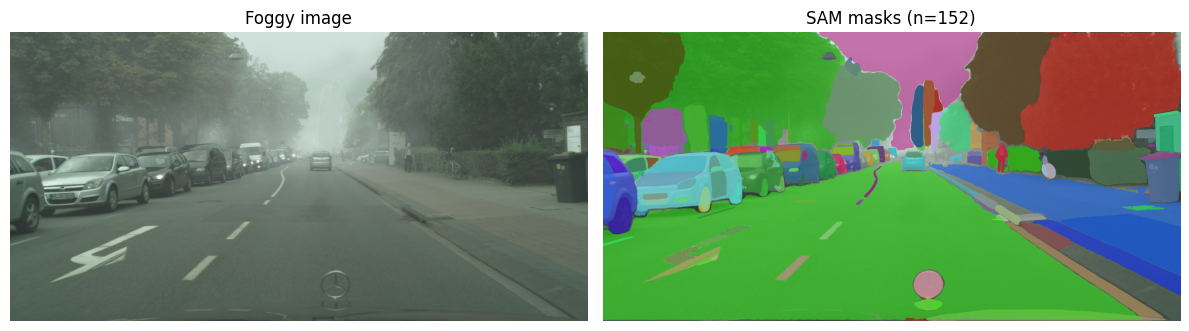

In [6]:
# === cell 4: visualize all masks ===
def show_sam_masks(image, masks, alpha=0.6, max_masks=None):
    if max_masks is not None:
        masks = masks[:max_masks]
    h, w, _ = image.shape
    canvas = image.copy().astype(np.float32)

    # random color per mask
    rng = np.random.default_rng(0)
    for m in masks:
        seg = m["segmentation"]  # (H,W) bool
        color = rng.integers(0, 255, size=(3,), dtype=np.uint8)
        canvas[seg] = 0.4 * canvas[seg] + 0.6 * color

    canvas = np.clip(canvas, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Foggy image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"SAM masks (n={len(masks)})")
    plt.imshow(canvas)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sam_masks(foggy_np, masks, max_masks=None)


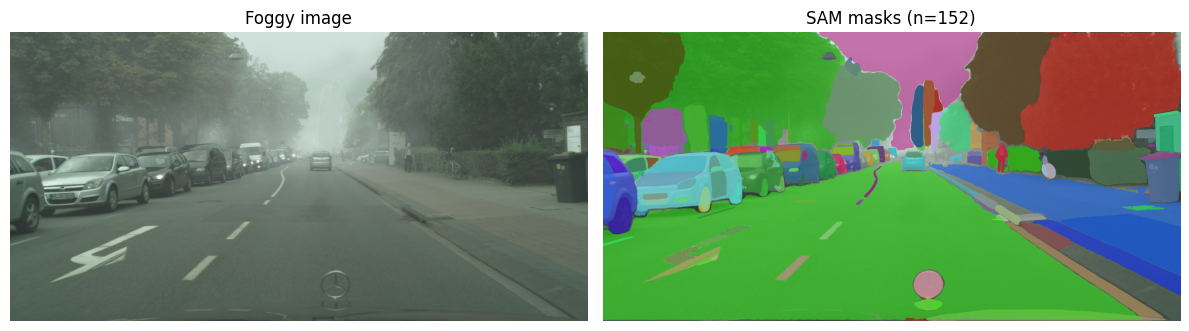

In [8]:
# === cell 4: visualize all masks ===
def show_sam_masks(image, masks, alpha=0.6, max_masks=None):
    if max_masks is not None:
        masks = masks[:max_masks]
    h, w, _ = image.shape
    canvas = image.copy().astype(np.float32)

    # random color per mask
    rng = np.random.default_rng(0)
    for m in masks:
        seg = m["segmentation"]  # (H,W) bool
        color = rng.integers(0, 255, size=(3,), dtype=np.uint8)
        canvas[seg] = 0.4 * canvas[seg] + 0.6 * color

    canvas = np.clip(canvas, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Foggy image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"SAM masks (n={len(masks)})")
    plt.imshow(canvas)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sam_masks(foggy_np, masks, max_masks=None)


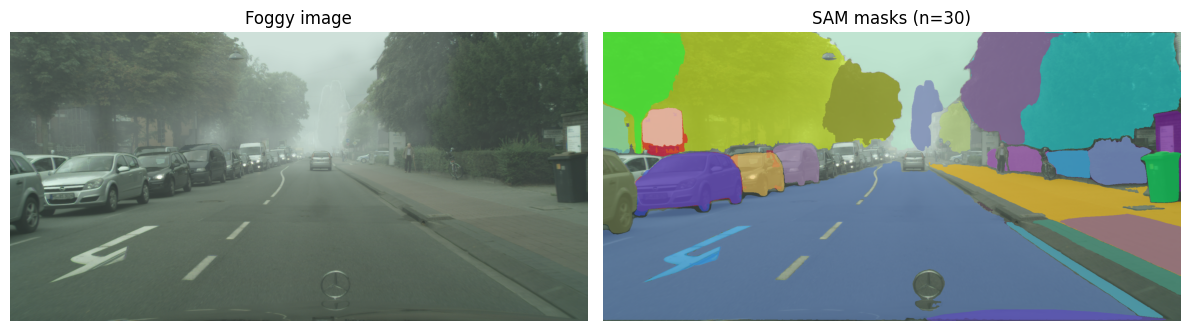

In [29]:
# === cell 5: visualize only largest K masks ===
masks_sorted = sorted(masks, key=lambda m: m["area"], reverse=True)
show_sam_masks(foggy_np, masks_sorted, max_masks=30)


Mask index: 17
Area: 22935
BBox: [137, 268, 162, 172]
predicted_iou: 0.9333665370941162
stability_score: 0.9348191618919373


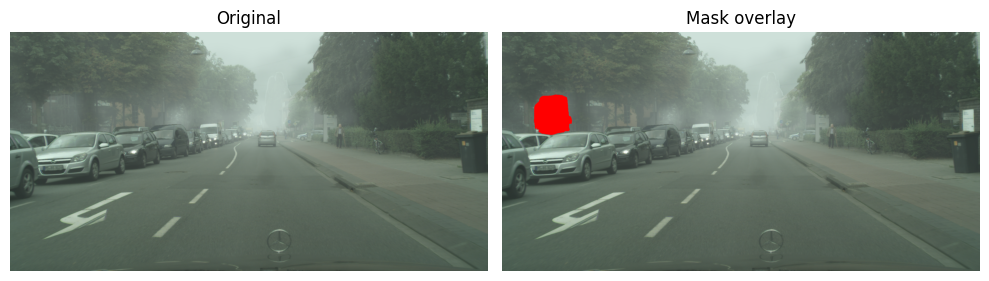

In [23]:
# === cell 6: inspect one mask ===
k = 17# change index
m = masks_sorted[k]
seg = m["segmentation"]

print("Mask index:", k)
print("Area:", m["area"])
print("BBox:", m["bbox"])
print("predicted_iou:", m["predicted_iou"])
print("stability_score:", m["stability_score"])

overlay = foggy_np.copy().astype(np.float32)
overlay[seg] = [255, 0, 0]  # red overlay

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(foggy_np)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Mask overlay")
plt.imshow(overlay.astype(np.uint8))
plt.axis("off")
plt.tight_layout()
plt.show()


In [36]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_ROOT = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/leftImg8bit_foggyDBF/val/lindau")
GT_ROOT  = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_data_foggy_19/val_lbls")

SAM_CKPT = "/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth"

# pick one image you know (adjust city/file if needed)
rel = "lindau_000000_000019_leftImg8bit_foggy_beta_0.01.png"
img_path = IMG_ROOT / rel
gt_path  = GT_ROOT / rel  # same filename in your 19-class foggy GT

foggy = np.array(Image.open(img_path).convert("RGB"))
gt    = np.array(Image.open(gt_path))  # [H,W] 19-trainIds

print("foggy shape:", foggy.shape, "gt unique:", np.unique(gt))


foggy shape: (1024, 2048, 3) gt unique: [  0   1   2   3   4   5   7   8   9  10  13  14 255]


In [37]:
# load SAM + generator (same hyperparams as pseudo script)
sam = sam_model_registry["vit_h"](checkpoint=SAM_CKPT)
sam.to(DEVICE).eval()

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
)

masks = mask_generator.generate(foggy)
print("SAM masks:", len(masks))


SAM masks: 180


In [56]:
CAR_ID = 13 # from CITYSCAPES_CLASSES_19

car_gt = (gt == CAR_ID)  # [H,W] bool
print("car GT pixels:", car_gt.sum())


car GT pixels: 175059


In [57]:
def iou_bool(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

ious = []
for i, m in enumerate(masks):
    seg = m["segmentation"]  # bool [H,W]
    ious.append((i, iou_bool(seg, car_gt), m["area"]))

# sort by IoU descending
ious_sorted = sorted(ious, key=lambda x: x[1], reverse=True)
print("Top 10 SAM masks for 'car' by IoU:")
for i, iou, area in ious_sorted[:10]:
    print(f"  idx={i:3d} | IoU={iou:.3f} | area={area}")


Top 10 SAM masks for 'car' by IoU:
  idx=116 | IoU=0.603 | area=105717
  idx= 34 | IoU=0.233 | area=41683
  idx=  0 | IoU=0.112 | area=19687
  idx=171 | IoU=0.081 | area=14133
  idx=117 | IoU=0.078 | area=13625
  idx=158 | IoU=0.057 | area=9921
  idx= 37 | IoU=0.043 | area=7532
  idx= 46 | IoU=0.031 | area=5384
  idx=165 | IoU=0.029 | area=5103
  idx= 51 | IoU=0.029 | area=4992


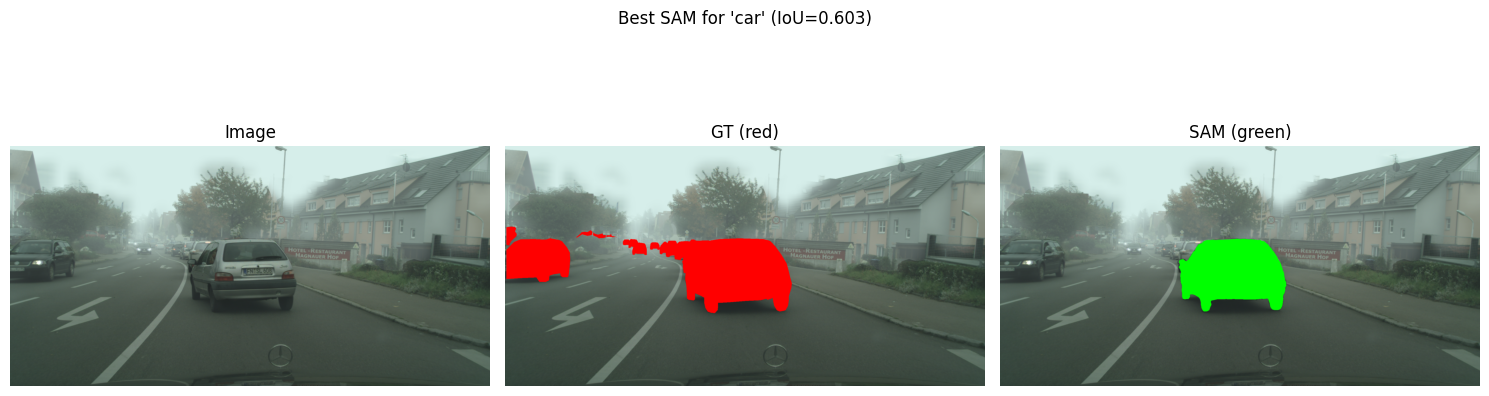

In [58]:
import matplotlib.pyplot as plt

def visualize_mask_pair(image, gt_mask, sam_mask, title=""):
    overlay_gt  = image.copy().astype(np.float32)
    overlay_sam = image.copy().astype(np.float32)

    overlay_gt[gt_mask]   = [255, 0, 0]   # red = GT
    overlay_sam[sam_mask] = [0, 255, 0]   # green = SAM

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].set_title("Image"); axs[0].imshow(image); axs[0].axis("off")
    axs[1].set_title("GT (red)"); axs[1].imshow(overlay_gt.astype(np.uint8)); axs[1].axis("off")
    axs[2].set_title("SAM (green)"); axs[2].imshow(overlay_sam.astype(np.uint8)); axs[2].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# best SAM car mask
best_idx, best_iou, _ = ious_sorted[0]
best_seg = masks[best_idx]["segmentation"]
visualize_mask_pair(foggy, car_gt, best_seg, title=f"Best SAM for 'car' (IoU={best_iou:.3f})")


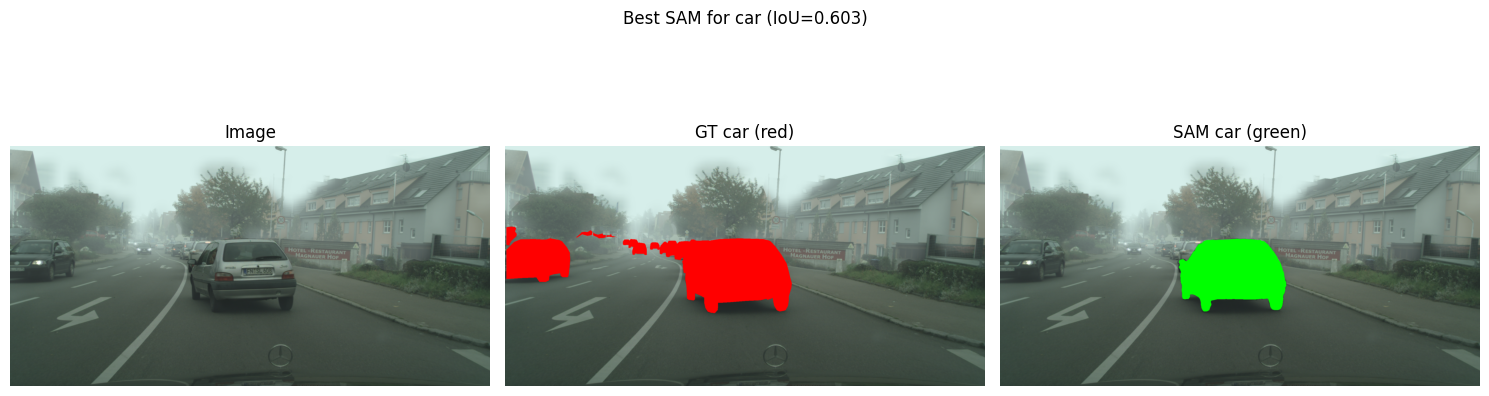

In [59]:
def visualize_mask_pair(image, gt_mask, sam_mask, title=""):
    overlay_gt  = image.copy().astype(np.float32)
    overlay_sam = image.copy().astype(np.float32)

    overlay_gt[gt_mask]   = [255, 0, 0]   # red = GT
    overlay_sam[sam_mask] = [0, 255, 0]   # green = SAM

    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].set_title("Image"); axs[0].imshow(image); axs[0].axis("off")
    axs[1].set_title("GT car (red)"); axs[1].imshow(overlay_gt.astype(np.uint8)); axs[1].axis("off")
    axs[2].set_title("SAM car (green)"); axs[2].imshow(overlay_sam.astype(np.uint8)); axs[2].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

best_idx, best_iou, _ = ious_sorted[0]
best_seg = masks[best_idx]["segmentation"]
visualize_mask_pair(foggy, car_gt, best_seg, title=f"Best SAM for car (IoU={best_iou:.3f})")


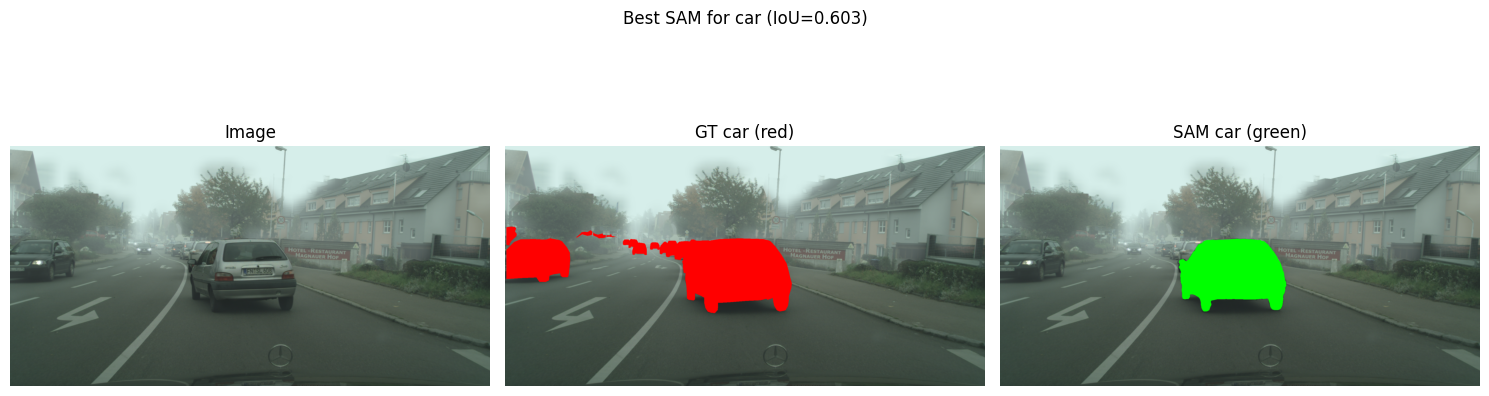

In [60]:
def visualize_mask_pair(image, gt_mask, sam_mask, title=""):
    overlay_gt  = image.copy().astype(np.float32)
    overlay_sam = image.copy().astype(np.float32)

    overlay_gt[gt_mask]   = [255, 0, 0]   # red = GT
    overlay_sam[sam_mask] = [0, 255, 0]   # green = SAM

    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].set_title("Image"); axs[0].imshow(image); axs[0].axis("off")
    axs[1].set_title("GT car (red)"); axs[1].imshow(overlay_gt.astype(np.uint8)); axs[1].axis("off")
    axs[2].set_title("SAM car (green)"); axs[2].imshow(overlay_sam.astype(np.uint8)); axs[2].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

best_idx, best_iou, _ = ious_sorted[0]
best_seg = masks[best_idx]["segmentation"]
visualize_mask_pair(foggy, car_gt, best_seg, title=f"Best SAM for car (IoU={best_iou:.3f})")


In [61]:
top_k = 3
top_idxs = [idx for idx, _, _ in ious_sorted[:top_k]]

union_mask = np.zeros_like(car_gt, dtype=bool)
for idx in top_idxs:
    union_mask |= masks[idx]["segmentation"]

union_iou = iou_bool(union_mask, car_gt)
print(f"Union IoU of top-{top_k} masks for 'car':", union_iou)


Union IoU of top-3 masks for 'car': 0.8342899399869166


In [62]:
sem_map = np.full((H, W), 255, dtype=np.uint8)   # IGNORE
conf_map = np.zeros((H, W), dtype=np.float32)

masks_sorted = sorted(masks, key=lambda m: m["area"], reverse=True)

for m in masks_sorted:
    seg = m["segmentation"]
    # classify → get cls_idx, prob
    if not fusion_res["is_confident"]:
        continue
    cls_idx = fusion_res["pred_idx"]
    prob    = fusion_res["max_prob"]

    seg_idx = seg & (prob > conf_map)
    sem_map[seg_idx]  = cls_idx
    conf_map[seg_idx] = prob


NameError: name 'H' is not defined

## gta checkpoinzt

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import random

GTA_ROOT = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/gta5_official")
GTA_IMG_DIR = GTA_ROOT / "images"
GTA_LBL_DIR = GTA_ROOT / "labels_trainId"   # <-- use your converted trainId labels (0..18, 255)

GTA_CSV_TRAIN = GTA_ROOT / "gta5_evaclip_train.csv"
GTA_CSV_VAL   = GTA_ROOT / "gta5_evaclip_val.csv"

CITYSCAPES_CLASSES_19 = [
    "road","sidewalk","building","wall","fence","pole","traffic light","traffic sign",
    "vegetation","terrain","sky","person","rider","car","truck","bus","train","motorcycle","bicycle"
]

CITYSCAPES_TEXT_LABELS_19 = [
    "the road surface",
    "the sidewalk next to the road",
    "urban building facades",
    "a city wall or barrier",
    "a fence along the road",
    "a thin vertical pole",
    "a traffic light at an intersection",
    "a traffic sign on the street",
    "trees and green vegetation",
    "grass or ground terrain",
    "the sky above the city",
    "a walking person",
    "a person riding a bike or motorcycle",
    "a car on the road",
    "a truck on the road",
    "a bus on the road",
    "a train on the tracks",
    "a motorcycle on the road",
    "a bicycle on the road",
]

# You can keep your Cityscapes templates, but GTA-specific phrasing often helps:
GTA_TEMPLATES = [
    "a GTA5 street scene with {}",
    "a synthetic driving scene showing {}",
    "a dashcam view with {}",
    "an urban road scene containing {}",
    "in this driving scene, you can see {}",
]


In [10]:
def sample_label_ids(lbl_dir: Path, n=50, seed=0):
    rng = random.Random(seed)
    files = sorted(lbl_dir.glob("*.png"))
    files = [files[i] for i in rng.sample(range(len(files)), k=min(n, len(files)))]
    ids = set()
    for p in files:
        arr = np.array(Image.open(p), dtype=np.int64)
        ids |= set(np.unique(arr).tolist())
    return sorted(ids)

ids = sample_label_ids(GTA_LBL_DIR, n=50, seed=42)
print("Unique IDs (sample):", ids)


Unique IDs (sample): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 255]


In [11]:
THINGS_IDS = set([11,12,13,14,15,16,17,18])   # person..bicycle
STUFF_IDS  = set(range(19)) - THINGS_IDS

def _list_common_stems(img_dir: Path, lbl_dir: Path, exts=(".png",".jpg",".jpeg")):
    imgs = {}
    for e in exts:
        for p in img_dir.glob(f"*{e}"):
            imgs[p.stem] = p
    lbls = {p.stem: p for p in lbl_dir.glob("*.png")}
    common = sorted(set(imgs.keys()) & set(lbls.keys()))
    return common, imgs, lbls

def _clip_bbox(x0,y0,x1,y1,W,H):
    x0 = max(0, min(x0, W-1)); x1 = max(1, min(x1, W))
    y0 = max(0, min(y0, H-1)); y1 = max(1, min(y1, H))
    if x1 <= x0 or y1 <= y0:
        return None
    return (x0,y0,x1,y1)

def build_gta5_evaclip_csv(
    img_dir: Path,
    lbl_dir: Path,
    out_train_csv: Path,
    out_val_csv: Path,
    max_images=10_000,
    val_frac=0.10,
    samples_per_class_per_image=2,
    seed=42,
    crop_sizes_things=(96,128,160),
    crop_sizes_stuff=(160,224,288),
    min_dom_things=0.35,
    min_dom_stuff=0.55,
):
    rng = np.random.default_rng(seed)

    common, imgs_map, lbls_map = _list_common_stems(img_dir, lbl_dir)
    print("Common image/label pairs:", len(common))

    # subsample images if needed
    if max_images and len(common) > max_images:
        common = rng.choice(common, size=max_images, replace=False).tolist()
        common = sorted(common)

    # split by IMAGE (prevents leakage across train/val crops)
    rng.shuffle(common)
    n_val = int(round(len(common) * val_frac))
    val_stems = set(common[:n_val])
    train_stems = common[n_val:]

    rows_train, rows_val = [], []

    for stem in common:
        img_path = imgs_map[stem]
        lbl_path = lbls_map[stem]

        gt = np.array(Image.open(lbl_path), dtype=np.int64)
        H, W = gt.shape[:2]

        present = np.unique(gt)
        present = [int(c) for c in present if c != 255 and 0 <= int(c) <= 18]
        if len(present) == 0:
            continue

        for cid in present:
            ys, xs = np.where(gt == cid)
            if len(xs) < 50:
                continue

            # choose crop sizes + dominance threshold based on thing/stuff
            if cid in THINGS_IDS:
                sizes = crop_sizes_things
                min_dom = min_dom_things
            else:
                sizes = crop_sizes_stuff
                min_dom = min_dom_stuff

            # sample a few crops for this class in this image
            for _ in range(samples_per_class_per_image):
                ok = False
                for _try in range(20):
                    j = rng.integers(0, len(xs))
                    cx, cy = int(xs[j]), int(ys[j])
                    s = int(rng.choice(sizes))
                    x0 = cx - s//2; x1 = cx + s//2
                    y0 = cy - s//2; y1 = cy + s//2
                    bb = _clip_bbox(x0,y0,x1,y1,W,H)
                    if bb is None:
                        continue
                    x0,y0,x1,y1 = bb

                    patch = gt[y0:y1, x0:x1]
                    dom = float((patch == cid).mean())
                    if dom >= min_dom:
                        ok = True
                        break

                if not ok:
                    continue

                row = {
                    "img_path": str(img_path),
                    "x1": int(x0), "y1": int(y0), "x2": int(x1), "y2": int(y1),
                    "class_id": int(cid),
                    "class_name": CITYSCAPES_CLASSES_19[int(cid)],
                }

                if stem in val_stems:
                    rows_val.append(row)
                else:
                    rows_train.append(row)

    df_tr = pd.DataFrame(rows_train)
    df_va = pd.DataFrame(rows_val)

    out_train_csv.parent.mkdir(parents=True, exist_ok=True)
    df_tr.to_csv(out_train_csv, index=False)
    df_va.to_csv(out_val_csv, index=False)

    print("Wrote:", out_train_csv, "rows:", len(df_tr))
    print("Wrote:", out_val_csv,   "rows:", len(df_va))
    print("Train class counts:\n", df_tr["class_name"].value_counts().head(10))
    print("Val class counts:\n", df_va["class_name"].value_counts().head(10))

build_gta5_evaclip_csv(
    GTA_IMG_DIR, GTA_LBL_DIR,
    GTA_CSV_TRAIN, GTA_CSV_VAL,
    max_images=10_000,
    samples_per_class_per_image=2,  # bump to 3–4 later if you want more crops
)


Common image/label pairs: 15000


KeyboardInterrupt: 

In [ ]:
from PIL import Image
from torch.utils.data import Dataset
import pandas as pd

def pad_bbox_xyxy(xmin, ymin, xmax, ymax, pad_ratio, W, H):
    bw = xmax - xmin + 1
    bh = ymax - ymin + 1
    pad = int(round(pad_ratio * max(bw, bh)))
    x0 = max(0, xmin - pad)
    y0 = max(0, ymin - pad)
    x1 = min(W - 1, xmax + pad)
    y1 = min(H - 1, ymax + pad)
    return x0, y0, x1, y1

class SegCropWithGlobalDataset(Dataset):
    """
    CSV columns: img_path, x1, y1, x2, y2, class_id, class_name
    Returns: crop_tensor, ctx_tensor, class_id, class_name
    """
    def __init__(self, csv_path, crop_preprocess, global_preprocess=None, max_samples=None, ctx_pad=0.40):
        df = pd.read_csv(csv_path)
        if max_samples is not None and max_samples < len(df):
            df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
        self.df = df
        self.crop_preprocess = crop_preprocess
        self.global_preprocess = global_preprocess if global_preprocess is not None else crop_preprocess
        self.ctx_pad = ctx_pad

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[int(idx)]
        img_path = row["img_path"]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])

        # tight crop = object crop
        crop_pil = img.crop((x1, y1, x2, y2))

        # context crop = padded bbox (matches pipeline usage)
        cx0, cy0, cx1, cy1 = pad_bbox_xyxy(x1, y1, x2, y2, self.ctx_pad, W, H)
        ctx_pil = img.crop((cx0, cy0, cx1, cy1))

        crop_t = self.crop_preprocess(crop_pil)
        ctx_t  = self.global_preprocess(ctx_pil)

        class_id = int(row["class_id"])
        class_name = row["class_name"]
        return crop_t, ctx_t, class_id, class_name


In [ ]:
import random
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF

class SAMLikeCropNoise:
    def __init__(self, p_tight=0.35, p_pad=0.35, tight_scale=(0.65, 0.95), pad_frac=(0.05, 0.25)):
        self.p_tight = p_tight
        self.p_pad = p_pad
        self.tight_scale = tight_scale
        self.pad_frac = pad_frac

    @staticmethod
    def _reflect_pad_pil(img, pad):
        if pad <= 0:
            return img
        arr = np.array(img)
        arr = np.pad(arr, ((pad,pad),(pad,pad),(0,0)), mode="reflect")
        return Image.fromarray(arr)

    def __call__(self, img):
        w, h = img.size

        # missing parts (tight crop)
        if random.random() < self.p_tight:
            s = random.uniform(*self.tight_scale)
            nw, nh = max(2,int(w*s)), max(2,int(h*s))
            left = random.randint(0, max(0, w - nw))
            top  = random.randint(0, max(0, h - nh))
            img = TF.resized_crop(img, top, left, nh, nw, size=[h, w], interpolation=TF.InterpolationMode.BICUBIC)

        # extra background (pad then crop back)
        if random.random() < self.p_pad:
            pad = int(random.uniform(*self.pad_frac) * min(h, w))
            padded = self._reflect_pad_pil(img, pad)
            pw, ph = padded.size
            left = random.randint(0, max(0, pw - w))
            top  = random.randint(0, max(0, ph - h))
            img = TF.crop(padded, top, left, h, w)

        return img


#lora

In [ ]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()


25

In [ ]:
from pathlib import Path
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms

# -----------------------
# MUST: EVA expects 224x224 (strict_img_size=True)
# -----------------------
IMG_SZ = 224

train_preprocess = transforms.Compose([
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_preprocess = train_preprocess

MAX_SAMPLES_TRAIN = 120_000
MAX_SAMPLES_VAL   = 20_000

train_ds = SegCropWithGlobalDataset(GTA_CSV_TRAIN, train_preprocess, max_samples=MAX_SAMPLES_TRAIN)
val_ds   = SegCropWithGlobalDataset(GTA_CSV_VAL,   val_preprocess,   max_samples=MAX_SAMPLES_VAL)

# -----------------------
# FIX: batch=1 + grad accumulation (keeps VRAM low)
# -----------------------
TRAIN_BS   = 1
VAL_BS     = 2
GRAD_ACCUM = 16  # effective batch = TRAIN_BS * GRAD_ACCUM

train_dl = DataLoader(train_ds, batch_size=TRAIN_BS, shuffle=True,  num_workers=4, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=VAL_BS,   shuffle=False, num_workers=4, pin_memory=True)

lr = 1e-5
weight_decay = 0.0
optimizer = torch.optim.AdamW(clip_model.parameters(), lr=lr, weight_decay=weight_decay)
scaler = GradScaler()

NUM_EPOCHS = 10
beta = 0.2
alpha = 0.1

ckpt_dir = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "eva_clip_ft_gta5_ctxfusion_19cls.pt"

best_val_top1 = -1.0

# -----------------------
# (Optional but recommended) FIX: enable grad checkpointing for EVA trunk
# -----------------------
if hasattr(clip_model, "visual") and hasattr(clip_model.visual, "trunk"):
    t = clip_model.visual.trunk
    if hasattr(t, "set_grad_checkpointing"):
        t.set_grad_checkpointing(True)
        print("Enabled grad checkpointing on visual.trunk")
    elif hasattr(t, "grad_checkpointing"):
        t.grad_checkpointing = True
        print("Enabled grad checkpointing on visual.trunk (attr)")

# -----------------------
# FIX: global encoding safely (global_t stays on CPU; move 1-by-1 to GPU)
# -----------------------
@torch.no_grad()
def encode_global_cpu_batch_to_feats(model, global_t_cpu, device):
    feats = []
    for i in range(global_t_cpu.size(0)):
        g_i = global_t_cpu[i:i+1].to(device, non_blocking=True)
        with autocast():
            f = model.encode_image(g_i)
            f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.to(torch.float16))  # keep global feats light
        del g_i
    return torch.cat(feats, dim=0)

@torch.no_grad()
def eval_top1_top5(model, loader):
    model.eval()
    top1 = top5 = total = 0

    for crop_t, global_t, y, _ in loader:
        crop_t = crop_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        with autocast():
            obj_feat = model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

        g_feat = encode_global_cpu_batch_to_feats(model, global_t, device).to(obj_feat.dtype)

        scene_fused = F.normalize(obj_feat + beta * (g_feat - obj_feat), dim=-1)
        text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
        fused_feat = F.normalize(scene_fused + alpha * (text_mean_batch - scene_fused), dim=-1)

        logits = fused_feat @ text_embeds.T
        pred1 = logits.argmax(dim=-1)
        top1 += (pred1 == y).sum().item()

        pred5 = logits.topk(5, dim=-1).indices
        top5 += (pred5 == y.unsqueeze(1)).any(dim=1).sum().item()

        total += y.numel()

    return top1 / max(1, total), top5 / max(1, total)

# -----------------------
# NEW TRAIN LOOP: grad accumulation + occasional cache clear
# -----------------------
clip_model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    running = 0.0
    n = 0

    optimizer.zero_grad(set_to_none=True)

    for step, (crop_t, global_t, y, _) in enumerate(train_dl):
        crop_t = crop_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        # ---- crop feat (grad) ----
        with autocast():
            obj_feat = clip_model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

        # ---- global feat (no grad; global_t remains CPU) ----
        with torch.no_grad():
            g_feat = encode_global_cpu_batch_to_feats(clip_model, global_t, device).to(obj_feat.dtype)

        # ---- fuse ----
        scene_fused = F.normalize(obj_feat + beta * (g_feat - obj_feat), dim=-1)
        text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
        fused_feat = F.normalize(scene_fused + alpha * (text_mean_batch - scene_fused), dim=-1)

        # ---- loss ----
        with autocast():
            logits = fused_feat @ text_embeds.T
            loss = F.cross_entropy(logits, y) / GRAD_ACCUM

        scaler.scale(loss).backward()

        # step optimizer every GRAD_ACCUM steps
        if (step + 1) % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running += (loss.item() * GRAD_ACCUM) * crop_t.size(0)
        n += crop_t.size(0)

        # optional: reduce fragmentation a bit
        if (step + 1) % 200 == 0:
            torch.cuda.empty_cache()

    # flush leftover grads if epoch ended mid-accum
    if (step + 1) % GRAD_ACCUM != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_loss = running / max(1, n)
    val_top1, val_top5 = eval_top1_top5(clip_model, val_dl)

    print(f"Epoch {epoch:02d} | train_loss {avg_loss:.4f} | val_top1 {val_top1*100:.2f}% | val_top5 {val_top5*100:.2f}%")

    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        torch.save(
            {
                "model_state_dict": clip_model.state_dict(),
                "epoch": epoch,
                "val_top1": float(best_val_top1),
                "classes": CITYSCAPES_CLASSES_19,
                "templates": GTA_TEMPLATES,
                "alpha": float(alpha),
                "beta": float(beta),
                "train_csv": str(GTA_CSV_TRAIN),
                "val_csv": str(GTA_CSV_VAL),
                "img_sz": int(IMG_SZ),
                "train_bs": int(TRAIN_BS),
                "grad_accum": int(GRAD_ACCUM),
            },
            ckpt_path
        )
        print("  -> saved best:", ckpt_path)

print("Done. Best val top1:", best_val_top1, "ckpt:", ckpt_path)


Enabled grad checkpointing on visual.trunk


/local/temp_shubhang/ipykernel_301672/3045939682.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/local/temp_shubhang/ipykernel_301672/3045939682.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/local/temp_shubhang/ipykernel_301672/3045939682.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/local/temp_shubhang/ipykernel_301672/3045939682.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


/local/temp_shubhang/ipykernel_301672/3045939682.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | train_loss 2.5259 | val_top1 94.54% | val_top5 99.26%
  -> saved best: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_gta5_ctxfusion_19cls.pt
Epoch 02 | train_loss 2.5165 | val_top1 95.88% | val_top5 99.41%
  -> saved best: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_gta5_ctxfusion_19cls.pt
Epoch 03 | train_loss 2.5125 | val_top1 95.57% | val_top5 99.12%
Epoch 04 | train_loss 2.5102 | val_top1 95.29% | val_top5 99.26%
Epoch 05 | train_loss 2.5089 | val_top1 95.28% | val_top5 99.27%
Epoch 06 | train_loss 2.5076 | val_top1 96.59% | val_top5 99.36%
  -> saved best: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_gta5_ctxfusion_19cls.pt
Epoch 07 | train_loss 2.5067 | val_top1 96.06% | val_top5 99.24%
Epoch 08 | train_loss 2.5060 | val_top1 96.50% | val_top5 99.36%
Epoch 09 | train_loss 2.5051 | val_top1 95.78% | val_top5 99.24%
Epoch 10 |

### lora

In [19]:
# ============================================================
# GTA -> EVA-CLIP LoRA finetune (FAST + pipeline-consistent)
#  - crop: SAM-like noise (train only)
#  - ctx : padded bbox crop (matches pipeline)
#  - LoRA on EVA visual trunk linears
#  - AMP + grad accumulation
#  - ctx encoding is BATCHED on GPU (FAST)
#  - disables trunk grad checkpointing
#  - saves RAW LoRA + MERGED vanilla ckpt
# ============================================================

from pathlib import Path
import math, random
import numpy as np
import pandas as pd
from PIL import Image
import contextlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torch.amp import autocast, GradScaler


# -----------------------
# 0) Speed knobs
# -----------------------
FAST_DEV_RUN = True   # <-- set False when you're confident everything works

# TF32 speeds up matmuls on Ampere+ GPUs
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

# Seed (optional)
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

assert "text_embeds" in globals() and "text_feat_mean" in globals(), "Need text_embeds + text_feat_mean"
assert "clip_model" in globals() and "device" in globals(), "Need clip_model + device"


# -----------------------
# 1) Dataset
# -----------------------
def pad_bbox_xyxy(xmin, ymin, xmax, ymax, pad_ratio, W, H):
    bw = xmax - xmin + 1
    bh = ymax - ymin + 1
    pad = int(round(pad_ratio * max(bw, bh)))
    x0 = max(0, xmin - pad)
    y0 = max(0, ymin - pad)
    x1 = min(W - 1, xmax + pad)
    y1 = min(H - 1, ymax + pad)
    return x0, y0, x1, y1

class SegCropWithGlobalDataset(Dataset):
    """
    CSV columns: img_path, x1, y1, x2, y2, class_id, class_name
    Returns: crop_tensor, ctx_tensor, class_id, class_name
    """
    def __init__(self, csv_path, crop_preprocess, global_preprocess=None, max_samples=None, ctx_pad=0.40):
        df = pd.read_csv(csv_path)
        if max_samples is not None and max_samples < len(df):
            df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
        self.df = df
        self.crop_preprocess = crop_preprocess
        self.global_preprocess = global_preprocess if global_preprocess is not None else crop_preprocess
        self.ctx_pad = ctx_pad

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[int(idx)]
        img_path = row["img_path"]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])

        crop_pil = img.crop((x1, y1, x2, y2))

        cx0, cy0, cx1, cy1 = pad_bbox_xyxy(x1, y1, x2, y2, self.ctx_pad, W, H)
        ctx_pil = img.crop((cx0, cy0, cx1, cy1))

        crop_t = self.crop_preprocess(crop_pil)
        ctx_t  = self.global_preprocess(ctx_pil)

        class_id = int(row["class_id"])
        class_name = row["class_name"]
        return crop_t, ctx_t, class_id, class_name


# -----------------------
# 2) SAM-like crop noise (train crops only)
# -----------------------
class SAMLikeCropNoise:
    def __init__(self, p_tight=0.35, p_pad=0.35, tight_scale=(0.65, 0.95), pad_frac=(0.05, 0.25)):
        self.p_tight = p_tight
        self.p_pad = p_pad
        self.tight_scale = tight_scale
        self.pad_frac = pad_frac

    @staticmethod
    def _reflect_pad_pil(img, pad):
        if pad <= 0:
            return img
        arr = np.array(img)
        arr = np.pad(arr, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")
        return Image.fromarray(arr)

    def __call__(self, img):
        w, h = img.size

        if random.random() < self.p_tight:
            s = random.uniform(*self.tight_scale)
            nw, nh = max(2, int(w * s)), max(2, int(h * s))
            left = random.randint(0, max(0, w - nw))
            top  = random.randint(0, max(0, h - nh))
            img = TF.resized_crop(img, top, left, nh, nw, size=[h, w],
                                  interpolation=TF.InterpolationMode.BICUBIC)

        if random.random() < self.p_pad:
            pad = int(random.uniform(*self.pad_frac) * min(h, w))
            padded = self._reflect_pad_pil(img, pad)
            pw, ph = padded.size
            left = random.randint(0, max(0, pw - w))
            top  = random.randint(0, max(0, ph - h))
            img = TF.crop(padded, top, left, h, w)

        return img


# -----------------------
# 3) LoRA (device-stable; checkpoint-safe)
# -----------------------
class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r=8, alpha=16, dropout=0.0):
        super().__init__()
        self.base = base
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r
        self.dropout = nn.Dropout(dropout) if dropout and dropout > 0 else nn.Identity()

        in_f = base.in_features
        out_f = base.out_features
        dev = base.weight.device

        self.lora_A = nn.Parameter(torch.empty(r, in_f, device=dev, dtype=torch.float32))
        self.lora_B = nn.Parameter(torch.zeros(out_f, r, device=dev, dtype=torch.float32))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

        for p in self.base.parameters():
            p.requires_grad = False

    def forward(self, x):
        out = self.base(x)
        x32 = self.dropout(x).to(torch.float32)
        lora = (x32 @ self.lora_A.t()) @ self.lora_B.t()
        return out + (lora * self.scaling).to(out.dtype)

def _get_parent(model, name):
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]

def inject_lora_visual(
    clip_model,
    target_substrings=("q_proj","k_proj","v_proj","qkv","proj","fc1","fc2"),
    r=8, alpha=16, dropout=0.0,
    train_norms=True,
    train_logit_scale=True,
):
    for p in clip_model.parameters():
        p.requires_grad = False

    to_replace = []
    for name, module in clip_model.named_modules():
        if isinstance(module, nn.Linear) and any(s in name for s in target_substrings):
            if hasattr(clip_model, "visual") and not name.startswith("visual"):
                continue
            to_replace.append((name, module))

    for name, module in to_replace:
        parent, child = _get_parent(clip_model, name)
        setattr(parent, child, LoRALinear(module, r=r, alpha=alpha, dropout=dropout))

    if train_norms:
        for name, module in clip_model.named_modules():
            if hasattr(clip_model, "visual") and not name.startswith("visual"):
                continue
            if isinstance(module, (nn.LayerNorm, nn.GroupNorm, nn.BatchNorm1d, nn.BatchNorm2d)):
                for p in module.parameters():
                    p.requires_grad = True

    if train_logit_scale and hasattr(clip_model, "logit_scale"):
        clip_model.logit_scale.requires_grad = True

    trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in clip_model.parameters())
    print(f"[LoRA] replaced {len(to_replace)} Linear layers | trainable {trainable/1e6:.2f}M / total {total/1e6:.2f}M")
    return clip_model

def merge_and_unwrap_lora(model):
    for name, module in list(model.named_modules()):
        if isinstance(module, LoRALinear):
            delta = (module.lora_B @ module.lora_A) * module.scaling
            delta = delta.to(module.base.weight.device, dtype=module.base.weight.dtype)
            module.base.weight.data += delta
            parent, child = _get_parent(model, name)
            setattr(parent, child, module.base)


# -----------------------
# 4) Preprocess + DataLoaders
# -----------------------
IMG_SZ = 224

crop_train_preprocess = transforms.Compose([
    SAMLikeCropNoise(),
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

crop_val_preprocess = transforms.Compose([
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

global_preprocess = transforms.Compose([
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

MAX_SAMPLES_TRAIN = 20_000 if FAST_DEV_RUN else 120_000
MAX_SAMPLES_VAL   = 2_000  if FAST_DEV_RUN else 20_000
NUM_EPOCHS        = 2      if FAST_DEV_RUN else 10

train_ds = SegCropWithGlobalDataset(
    GTA_CSV_TRAIN,
    crop_preprocess=crop_train_preprocess,
    global_preprocess=global_preprocess,
    max_samples=MAX_SAMPLES_TRAIN,
    ctx_pad=0.40,
)
val_ds = SegCropWithGlobalDataset(
    GTA_CSV_VAL,
    crop_preprocess=crop_val_preprocess,
    global_preprocess=global_preprocess,
    max_samples=MAX_SAMPLES_VAL,
    ctx_pad=0.40,
)

TRAIN_BS   = 1
VAL_BS     = 2
GRAD_ACCUM = 16

num_workers = 8  # bump this if your storage can handle it
train_dl = DataLoader(
    train_ds, batch_size=TRAIN_BS, shuffle=True,
    num_workers=num_workers, pin_memory=True, drop_last=True,
    persistent_workers=(num_workers > 0), prefetch_factor=4
)
val_dl = DataLoader(
    val_ds, batch_size=VAL_BS, shuffle=False,
    num_workers=num_workers, pin_memory=True,
    persistent_workers=(num_workers > 0), prefetch_factor=4
)


# -----------------------
# 5) Model setup (order matters)
# -----------------------
is_cuda = str(device).startswith("cuda")
amp_enabled = is_cuda
scaler = GradScaler("cuda") if is_cuda else GradScaler()
amp_ctx = (lambda: autocast(device_type="cuda", dtype=torch.float16, enabled=amp_enabled)) if is_cuda else (lambda: contextlib.nullcontext())

clip_model = clip_model.to(device)

# Disable EVA trunk grad checkpointing (prevents your prior CheckpointError issues)
if hasattr(clip_model, "visual") and hasattr(clip_model.visual, "trunk"):
    t = clip_model.visual.trunk
    if hasattr(t, "set_grad_checkpointing"):
        try:
            t.set_grad_checkpointing(False)
        except TypeError:
            t.set_grad_checkpointing(enable=False)
    if hasattr(t, "grad_checkpointing"):
        t.grad_checkpointing = False
    print("[Info] Disabled trunk grad checkpointing (if supported).")

# Inject LoRA AFTER model is on device
clip_model = inject_lora_visual(clip_model, r=8, alpha=16, dropout=0.0)
clip_model = clip_model.to(device)

# sanity
for n, p in clip_model.named_parameters():
    if "lora_A" in n:
        print("[Sanity] LoRA param:", n, p.device, p.dtype)
        break


# -----------------------
# 6) Optimizer
# -----------------------
lr = 1e-4
weight_decay = 0.0
optimizer = torch.optim.AdamW(
    (p for p in clip_model.parameters() if p.requires_grad),
    lr=lr,
    weight_decay=weight_decay
)

beta = 0.2
alpha = 0.1

ckpt_dir = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
raw_ckpt_path    = ckpt_dir / "eva_clip_ft_gta5_ctxfusion_19cls_LORA_RAW.pt"
merged_ckpt_path = ckpt_dir / "eva_clip_ft_gta5_ctxfusion_19cls_MERGED.pt"
best_val_top1 = -1.0


# -----------------------
# 7) FAST batched ctx encoder (this is the huge speedup)
# -----------------------
@torch.no_grad()
def encode_ctx_batch(model, ctx_t, device, out_dtype):
    ctx_t = ctx_t.to(device, non_blocking=True)
    with amp_ctx():
        f = model.encode_image(ctx_t)
        f = f / f.norm(dim=-1, keepdim=True)
    return f.to(out_dtype)

@torch.no_grad()
def eval_top1_top5(model, loader, device):
    model.eval()
    top1 = top5 = total = 0
    for crop_t, ctx_t, y, _ in loader:
        crop_t = crop_t.to(device, non_blocking=True)
        ctx_t  = ctx_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        with amp_ctx():
            obj_feat = model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

            ctx_feat = model.encode_image(ctx_t)
            ctx_feat = ctx_feat / ctx_feat.norm(dim=-1, keepdim=True)

            scene_fused = F.normalize(obj_feat + beta * (ctx_feat - obj_feat), dim=-1)
            text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
            fused_feat = F.normalize(scene_fused + alpha * (text_mean_batch - scene_fused), dim=-1)

            logits = fused_feat @ text_embeds.T
            pred1 = logits.argmax(dim=-1)
            top1 += (pred1 == y).sum().item()

            pred5 = logits.topk(5, dim=-1).indices
            top5 += (pred5 == y.unsqueeze(1)).any(dim=1).sum().item()

        total += y.numel()
    return top1 / max(1, total), top5 / max(1, total)


# -----------------------
# 8) Train loop
# -----------------------
clip_model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    running = 0.0
    n = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (crop_t, ctx_t, y, _) in enumerate(train_dl):
        crop_t = crop_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        with amp_ctx():
            # crop forward (grad)
            obj_feat = clip_model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

            # ctx forward (no grad, but BATCHED on GPU)
            with torch.no_grad():
                ctx_feat = encode_ctx_batch(clip_model, ctx_t, device, obj_feat.dtype)

            # fuse
            scene_fused = F.normalize(obj_feat + beta * (ctx_feat - obj_feat), dim=-1)
            text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
            fused_feat = F.normalize(scene_fused + alpha * (text_mean_batch - scene_fused), dim=-1)

            logits = fused_feat @ text_embeds.T
            loss = F.cross_entropy(logits, y) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running += (loss.item() * GRAD_ACCUM) * crop_t.size(0)
        n += crop_t.size(0)

        if (step + 1) % 200 == 0:
            print(f"  step {step+1}/{len(train_dl)} | loss {running/max(1,n):.4f}")

    if (step + 1) % GRAD_ACCUM != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_loss = running / max(1, n)
    val_top1, val_top5 = eval_top1_top5(clip_model, val_dl, device)
    print(f"Epoch {epoch:02d} | train_loss {avg_loss:.4f} | val_top1 {val_top1*100:.2f}% | val_top5 {val_top5*100:.2f}%")

    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        torch.save(
            {
                "model_state_dict": clip_model.state_dict(),  # RAW LoRA-shaped
                "epoch": epoch,
                "val_top1": float(best_val_top1),
                "classes": CITYSCAPES_CLASSES_19,
                "templates": GTA_TEMPLATES,
                "alpha": float(alpha),
                "beta": float(beta),
                "train_csv": str(GTA_CSV_TRAIN),
                "val_csv": str(GTA_CSV_VAL),
                "img_sz": int(IMG_SZ),
                "train_bs": int(TRAIN_BS),
                "grad_accum": int(GRAD_ACCUM),
                "lora_r": 8,
                "lora_alpha": 16,
                "lora_dropout": 0.0,
                "ctx_pad": 0.40,
                "fast_dev_run": bool(FAST_DEV_RUN),
            },
            raw_ckpt_path
        )
        print("  -> saved best RAW LoRA:", raw_ckpt_path)

print("Done. Best val top1:", best_val_top1, "| raw ckpt:", raw_ckpt_path)


# -----------------------
# 9) Export merged vanilla checkpoint (pipeline-loadable)
# -----------------------
if raw_ckpt_path.exists():
    best = torch.load(raw_ckpt_path, map_location="cpu", weights_only=False)
    clip_model.load_state_dict(best["model_state_dict"], strict=True)

    merge_and_unwrap_lora(clip_model)  # in-place: becomes vanilla nn.Linear

    # save vanilla state_dict on CPU
    merged_state = {k: v.detach().cpu() for k, v in clip_model.state_dict().items()}
    best["model_state_dict"] = merged_state
    best["lora_merged"] = True

    torch.save(best, merged_ckpt_path)
    print("Saved MERGED vanilla checkpoint for pipeline:", merged_ckpt_path)
else:
    print("WARNING: raw_ckpt_path not found; cannot export merged checkpoint.")


[Info] Disabled trunk grad checkpointing (if supported).
[LoRA] replaced 168 Linear layers | trainable 4.02M / total 431.49M
[Sanity] LoRA param: visual.trunk.blocks.0.attn.q_proj.lora_A cuda:0 torch.float32
  step 200/20000 | loss 2.8767
  step 400/20000 | loss 2.8380
  step 600/20000 | loss 2.8064
  step 800/20000 | loss 2.7852
  step 1000/20000 | loss 2.7654
  step 1200/20000 | loss 2.7487
  step 1400/20000 | loss 2.7332
  step 1600/20000 | loss 2.7189
  step 1800/20000 | loss 2.7067
  step 2000/20000 | loss 2.6963
  step 2200/20000 | loss 2.6871
  step 2400/20000 | loss 2.6789
  step 2600/20000 | loss 2.6720
  step 2800/20000 | loss 2.6659
  step 3000/20000 | loss 2.6600
  step 3200/20000 | loss 2.6534
  step 3400/20000 | loss 2.6485
  step 3600/20000 | loss 2.6448
  step 3800/20000 | loss 2.6404
  step 4000/20000 | loss 2.6365
  step 4200/20000 | loss 2.6331
  step 4400/20000 | loss 2.6300
  step 4600/20000 | loss 2.6263
  step 4800/20000 | loss 2.6233
  step 5000/20000 | loss 2.6

## IOSB

In [1]:
from pathlib import Path
import sys
import torch

PROJECT_ROOT = Path("/home/wiss/shubhangi/da-seg/thesis_da_segmentation/sam_clip_full")
sys.path.insert(0, str(PROJECT_ROOT))

BASE = Path("/home/wiss/shubhangi/home/scs_deal_projects_notapebackup")
DATA_ROOT = BASE / "shared/DATASET/waste_dataset"

IOSB_ROOT = DATA_ROOT / "iosb_packform9"
IMG_DIR = IOSB_ROOT / "images"
LBL_DIR = IOSB_ROOT / "masks"

# If you want to train only on split folders instead, use:
# IMG_DIR = IOSB_ROOT / "train_imgs"
# LBL_DIR = IOSB_ROOT / "train_lbls"

RUN_ROOT = PROJECT_ROOT / "camera_ready_runs"
CKPT_DIR = RUN_ROOT / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = CKPT_DIR / "eva_clip_ft_iosb_packform9_FULL.pt"

print("Project:", PROJECT_ROOT, PROJECT_ROOT.exists())
print("IOSB_ROOT:", IOSB_ROOT, IOSB_ROOT.exists())
print("IMG_DIR:", IMG_DIR, IMG_DIR.exists())
print("LBL_DIR:", LBL_DIR, LBL_DIR.exists())
print("CKPT_PATH:", CKPT_PATH)
print("CUDA:", torch.cuda.is_available())

Project: /home/wiss/shubhangi/da-seg/thesis_da_segmentation/sam_clip_full True
IOSB_ROOT: /home/wiss/shubhangi/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9 True
IMG_DIR: /home/wiss/shubhangi/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9/images True
LBL_DIR: /home/wiss/shubhangi/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9/masks True
CKPT_PATH: /home/wiss/shubhangi/da-seg/thesis_da_segmentation/sam_clip_full/camera_ready_runs/checkpoints/eva_clip_ft_iosb_packform9_FULL.pt
CUDA: False


In [2]:
import open_clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

EVA_MODEL_NAME = "EVA02-L-14"
EVA_PRETRAINED_TAG = "merged2b_s4b_b131k"

print("device:", device)
print("Loading:", EVA_MODEL_NAME, EVA_PRETRAINED_TAG)

clip_model, _, preprocess = open_clip.create_model_and_transforms(
    EVA_MODEL_NAME,
    pretrained=EVA_PRETRAINED_TAG,
    device=device,
)

tokenizer = open_clip.get_tokenizer(EVA_MODEL_NAME)

clip_model = clip_model.to(device)
print("EVA model loaded.")

/home/wiss/shubhangi/da-seg/thesis_da_segmentation/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu
Loading: EVA02-L-14 merged2b_s4b_b131k
EVA model loaded.


In [3]:
# ============================================================
# IOSB (packaging-form 9-class) -> EVA-CLIP FULL finetune
#  - builds crop CSVs from iosb_packform9/{images,masks}
#  - trains on classes 1..8 (background excluded) => train labels 0..7
#  - crop = tight bbox crops + ctx padded crops (pipeline-consistent)
#  - ctx fusion: beta, text-mean fusion: alpha (same as GTA)
#  - AMP + grad accumulation (low VRAM)
#  - saves best checkpoint
#
# NOTE:
# - This script assumes you already have EVA-CLIP loaded as `clip_model`
#   and `device` set (cuda recommended), exactly like in your GTA notebook.
# - It also builds text embeddings internally (no GTA code reuse).
# ============================================================

from pathlib import Path
import random
import json
import math
import gc

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler

# -----------------------
# 0) Paths
# -----------------------
# IOSB_ROOT = Path("/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9")
# IMG_DIR   = IOSB_ROOT / "images"
# LBL_DIR   = IOSB_ROOT / "masks"

# CSV_TRAIN = IOSB_ROOT / "iosb_evaclip_train.csv"
# CSV_VAL   = IOSB_ROOT / "iosb_evaclip_val.csv"

# CKPT_DIR  = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints")
# CKPT_DIR.mkdir(parents=True, exist_ok=True)
# CKPT_PATH = CKPT_DIR / "eva_clip_ft_iosb_packform9_FULL.pt"
IOSB_ROOT = Path("/home/wiss/shubhangi/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9")

IMG_DIR   = IOSB_ROOT / "images"
LBL_DIR   = IOSB_ROOT / "masks"

CSV_TRAIN = IOSB_ROOT / "iosb_evaclip_train.csv"
CSV_VAL   = IOSB_ROOT / "iosb_evaclip_val.csv"

CKPT_DIR  = Path("/home/wiss/shubhangi/da-seg/thesis_da_segmentation/sam_clip_full/camera_ready_runs/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CKPT_DIR / "eva_clip_ft_iosb_packform9_FULL.pt"

# -----------------------
# 1) Classes (0..8 in masks; train on 1..8)
#     Train labels become 0..7 (cid-1)
# -----------------------
IOSB_CLASSES_9 = [
    "background",
    "bottle",
    "bag_film",
    "cup_tray",
    "lid_cap",
    "carton",
    "can",
    "foam",
    "other_packaging",
]
TRAIN_CLASSES_8 = IOSB_CLASSES_9[1:]  # 8 classes

# IOSB_TEXT_LABELS_9 = [
#     "background",
#     "a plastic bottle",
#     "a plastic bag or plastic film",
#     "a cup, tray, or food container",
#     "a lid or cap",
#     "a beverage carton or liquid carton",
#     "a metal can",
#     "foam packaging material",
#     "other packaging item",
# ]
# TRAIN_TEXTS_8 = IOSB_TEXT_LABELS_9[1:]

IOSB_TEMPLATES = [
    "a waste sorting image containing {}",
    "an industrial waste stream showing {}",
    "a conveyor-belt scene with {}",
    "a waste item: {}",
    "an image of {} in a waste sorting setting",
]

In [4]:
IOSB_CLASSES_9 = [
    "background",
    "bottle",
    "bag_film",
    "cup_tray",
    "lid_cap",
    "carton",
    "can",
    "foam",
    "other_packaging",
]
TRAIN_CLASSES_8 = IOSB_CLASSES_9[1:]  # 8 classes (train ids 0..7 after cid-1)

IOSB_SYNONYMS = {
  "bottle": [
    "a plastic bottle", "a PET bottle", "a water bottle", "a soda bottle"
  ],
  "bag_film": [
    "a plastic bag", "plastic film", "shrink wrap", "wrapping film", "plastic wrapper"
  ],
  "cup_tray": [
    "a plastic cup", "a food tray", "a plastic tray", "a takeaway container",
    "a food container", "a clamshell container"
  ],
  "lid_cap": [
    "a bottle cap", "a plastic cap", "a lid", "a container lid"
  ],
  "carton": [
    "a beverage carton", "a milk carton", "a juice carton", "a liquid carton (Tetra Pak)"
  ],
  "can": [
    "a metal can", "an aluminum can", "a soda can", "a tin can"
  ],
  "foam": [
    "foam packaging", "styrofoam", "expanded polystyrene foam", "foam tray"
  ],
  "other_packaging": [
    "other packaging", "miscellaneous packaging", "unknown packaging item"
  ],
}

IOSB_TEMPLATES = [
  "a waste sorting image containing {}",
  "an industrial waste stream showing {}",
  "a conveyor-belt scene with {}",
  "a waste item: {}",
  "an image of {} in a waste sorting setting",
  "a piece of {} packaging on a conveyor belt",
]


In [5]:

# -----------------------
# 2) CSV builder (no GTA reuse)
# -----------------------
def _list_common_stems(img_dir: Path, lbl_dir: Path, exts=(".png", ".jpg", ".jpeg")):
    imgs = {}
    for e in exts:
        for p in img_dir.glob(f"*{e}"):
            imgs[p.stem] = p
    lbls = {p.stem: p for p in lbl_dir.glob("*.png")}
    common = sorted(set(imgs.keys()) & set(lbls.keys()))
    return common, imgs, lbls

def _clip_bbox(x0, y0, x1, y1, W, H):
    x0 = max(0, min(int(x0), W - 1))
    y0 = max(0, min(int(y0), H - 1))
    x1 = max(1, min(int(x1), W))
    y1 = max(1, min(int(y1), H))
    if x1 <= x0 or y1 <= y0:
        return None
    return x0, y0, x1, y1

def build_iosb_evaclip_csv(
    img_dir: Path,
    lbl_dir: Path,
    out_train_csv: Path,
    out_val_csv: Path,
    max_images=None,
    val_frac=0.10,
    samples_per_class_per_image=2,
    seed=42,
    crop_sizes=(96, 128, 160, 192),
    min_dom=0.55,
    min_pixels_per_class=500,
):
    rng = np.random.default_rng(seed)

    common, imgs_map, lbls_map = _list_common_stems(img_dir, lbl_dir)
    print("[CSV] Common image/label pairs:", len(common))

    if max_images is not None and len(common) > max_images:
        common = rng.choice(common, size=max_images, replace=False).tolist()
        common = sorted(common)

    rng.shuffle(common)
    n_val = int(round(len(common) * val_frac))
    val_stems = set(common[:n_val])

    rows_train, rows_val = [], []

    for stem in common:
        img_path = imgs_map[stem]
        lbl_path = lbls_map[stem]

        gt = np.array(Image.open(lbl_path), dtype=np.int64)
        H, W = gt.shape[:2]

        present = np.unique(gt)
        present = [int(c) for c in present if 1 <= int(c) <= 8]  # exclude background=0
        if len(present) == 0:
            continue

        for cid in present:
            ys, xs = np.where(gt == cid)
            if len(xs) < min_pixels_per_class:
                continue

            for _ in range(samples_per_class_per_image):
                ok = False
                for _try in range(30):
                    j = rng.integers(0, len(xs))
                    cx, cy = int(xs[j]), int(ys[j])
                    s = int(rng.choice(crop_sizes))

                    x0 = cx - s // 2
                    x1 = cx + s // 2
                    y0 = cy - s // 2
                    y1 = cy + s // 2

                    bb = _clip_bbox(x0, y0, x1, y1, W, H)
                    if bb is None:
                        continue
                    x0, y0, x1, y1 = bb

                    patch = gt[y0:y1, x0:x1]
                    dom = float((patch == cid).mean())
                    if dom >= min_dom:
                        ok = True
                        break

                if not ok:
                    continue

                # IMPORTANT: train class_id is contiguous 0..7 (cid-1)
                row = {
                    "img_path": str(img_path),
                    "x1": int(x0), "y1": int(y0), "x2": int(x1), "y2": int(y1),
                    "class_id": int(cid - 1),
                    "class_name": TRAIN_CLASSES_8[int(cid - 1)],
                }

                if stem in val_stems:
                    rows_val.append(row)
                else:
                    rows_train.append(row)

    df_tr = pd.DataFrame(rows_train)
    df_va = pd.DataFrame(rows_val)

    out_train_csv.parent.mkdir(parents=True, exist_ok=True)
    df_tr.to_csv(out_train_csv, index=False)
    df_va.to_csv(out_val_csv, index=False)

    print("[CSV] Wrote:", out_train_csv, "rows:", len(df_tr))
    print("[CSV] Wrote:", out_val_csv,   "rows:", len(df_va))
    if len(df_tr):
        print("[CSV] Train counts:\n", df_tr["class_name"].value_counts())
    if len(df_va):
        print("[CSV] Val counts:\n", df_va["class_name"].value_counts())

# Build CSVs (run once; safe to overwrite)
build_iosb_evaclip_csv(
    IMG_DIR, LBL_DIR,
    CSV_TRAIN, CSV_VAL,
    max_images=None,
    val_frac=0.10,
    samples_per_class_per_image=2,
    crop_sizes=(96, 128, 160, 192),
    min_dom=0.55,
    min_pixels_per_class=500,
)

[CSV] Common image/label pairs: 662
[CSV] Wrote: /home/wiss/shubhangi/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9/iosb_evaclip_train.csv rows: 4579
[CSV] Wrote: /home/wiss/shubhangi/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9/iosb_evaclip_val.csv rows: 487
[CSV] Train counts:
 class_name
bag_film           1126
other_packaging    1088
cup_tray            743
foam                466
lid_cap             360
carton              332
can                 242
bottle              222
Name: count, dtype: int64
[CSV] Val counts:
 class_name
bag_film           126
other_packaging    122
cup_tray            86
foam                51
lid_cap             40
carton              28
bottle              18
can                 16
Name: count, dtype: int64


In [6]:
import open_clip

tokenize = open_clip.tokenize


# -----------------------
# 3) Dataset (same interface you used)
# -----------------------
def pad_bbox_xyxy(xmin, ymin, xmax, ymax, pad_ratio, W, H):
    bw = xmax - xmin + 1
    bh = ymax - ymin + 1
    pad = int(round(pad_ratio * max(bw, bh)))
    x0 = max(0, xmin - pad)
    y0 = max(0, ymin - pad)
    x1 = min(W - 1, xmax + pad)
    y1 = min(H - 1, ymax + pad)
    return x0, y0, x1, y1

class SegCropWithGlobalDataset(Dataset):
    """
    CSV columns: img_path, x1, y1, x2, y2, class_id, class_name
    Returns: crop_tensor, ctx_tensor, class_id, class_name
    """
    def __init__(self, csv_path, crop_preprocess, global_preprocess=None, max_samples=None, ctx_pad=0.40):
        df = pd.read_csv(csv_path)
        if max_samples is not None and max_samples < len(df):
            df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
        self.df = df
        self.crop_preprocess = crop_preprocess
        self.global_preprocess = global_preprocess if global_preprocess is not None else crop_preprocess
        self.ctx_pad = ctx_pad

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[int(idx)]
        img_path = row["img_path"]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])

        crop_pil = img.crop((x1, y1, x2, y2))

        cx0, cy0, cx1, cy1 = pad_bbox_xyxy(x1, y1, x2, y2, self.ctx_pad, W, H)
        ctx_pil = img.crop((cx0, cy0, cx1, cy1))

        crop_t = self.crop_preprocess(crop_pil)
        ctx_t  = self.global_preprocess(ctx_pil)

        class_id = int(row["class_id"])   # 0..7
        class_name = row["class_name"]
        return crop_t, ctx_t, class_id, class_name

# -----------------------
# 4) Preprocess + Loaders
# -----------------------
IMG_SZ = 224

train_preprocess = transforms.Compose([
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_preprocess = train_preprocess

MAX_SAMPLES_TRAIN = 120_000
MAX_SAMPLES_VAL   = 20_000

train_ds = SegCropWithGlobalDataset(CSV_TRAIN, train_preprocess, max_samples=MAX_SAMPLES_TRAIN, ctx_pad=0.40)
val_ds   = SegCropWithGlobalDataset(CSV_VAL,   val_preprocess,   max_samples=MAX_SAMPLES_VAL,   ctx_pad=0.40)

TRAIN_BS   = 1
VAL_BS     = 2
GRAD_ACCUM = 16

train_dl = DataLoader(train_ds, batch_size=TRAIN_BS, shuffle=True,  num_workers=4, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=VAL_BS,   shuffle=False, num_workers=4, pin_memory=True)


In [7]:
# -----------------------
# 5) Build text embeddings (synonym pooling)
# -----------------------
import open_clip
tokenize = open_clip.tokenize  # keep this here or earlier (after imports)

assert "clip_model" in globals(), "You must have clip_model loaded (EVA-CLIP)."
assert "device" in globals(), "You must have device set."
assert "tokenize" in globals(), "Need open_clip.tokenize (or EVA tokenizer) in scope."

clip_model = clip_model.to(device)

def build_text_embeds_from_synonyms(
    model,
    class_names,          # TRAIN_CLASSES_8 (len=8)
    synonyms_dict,        # IOSB_SYNONYMS
    templates,
    device,
    pool="mean",          # "mean" or "max"
):
    """
    Returns:
      text_embeds: (C, D)
      text_feat_mean: (1, D)
      phrase_counts: dict[class_name] -> int (#synonyms)
    """
    model.eval()
    phrase_counts = {}

    with torch.no_grad():
        class_vecs = []

        for cname in class_names:
            phrases = synonyms_dict.get(cname, None)
            if not phrases:
                phrases = [cname]  # fallback
            phrase_counts[cname] = len(phrases)

            # templates × phrases
            prompts = []
            for ph in phrases:
                prompts.extend([t.format(ph) for t in templates])

            tok = tokenize(prompts).to(device)

            with autocast():
                z = model.encode_text(tok)                 # (N, D)
                z = z / z.norm(dim=-1, keepdim=True)

            if pool == "max":
                z_cls = z.max(dim=0, keepdim=True).values  # (1, D)
            else:
                z_cls = z.mean(dim=0, keepdim=True)        # (1, D)

            z_cls = z_cls / z_cls.norm(dim=-1, keepdim=True)
            class_vecs.append(z_cls)

        text_embeds = torch.cat(class_vecs, dim=0)         # (C, D)
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

        text_feat_mean = text_embeds.mean(dim=0, keepdim=True)
        text_feat_mean = text_feat_mean / text_feat_mean.norm(dim=-1, keepdim=True)

    model.train()
    return text_embeds, text_feat_mean, phrase_counts


# Build pooled text embeddings (8 classes)
text_embeds, text_feat_mean, phrase_counts = build_text_embeds_from_synonyms(
    clip_model,
    class_names=TRAIN_CLASSES_8,
    synonyms_dict=IOSB_SYNONYMS,
    templates=IOSB_TEMPLATES,
    device=device,
    pool="mean",
)

print("text_embeds:", tuple(text_embeds.shape), "text_feat_mean:", tuple(text_feat_mean.shape))
print("phrases per class:", phrase_counts)


/tmp/ipykernel_171987/828640441.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/home/wiss/shubhangi/da-seg/thesis_da_segmentation/venv/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


text_embeds: (8, 768) text_feat_mean: (1, 768)
phrases per class: {'bottle': 4, 'bag_film': 5, 'cup_tray': 6, 'lid_cap': 4, 'carton': 4, 'can': 4, 'foam': 4, 'other_packaging': 3}


In [8]:
# -----------------------
# 5) Build text embeddings (no GTA globals)
# -----------------------
assert "clip_model" in globals(), "You must have clip_model loaded (EVA-CLIP)."
assert "device" in globals(), "You must have device set."

clip_model = clip_model.to(device)

# def build_text_embeds(model, class_texts, templates, device):
#     model.eval()
#     with torch.no_grad():
#         # You already have a tokenizer path in your EVA setup; EVA-CLIP wrappers usually expose a tokenize fn.
#         # In your GTA notebook, you had `text_embeds` already prepared.
#         # Here we assume you have `tokenize` in scope. If not, replace with your EVA tokenizer call.
#         assert "tokenize" in globals(), (
#             "Need a `tokenize(...)` function in scope (same as your GTA notebook).\n"
#             "Use the exact tokenize you used earlier for EVA-CLIP."
#         )

#         all_feats = []
#         for cname in class_texts:
#             prompts = [t.format(cname) for t in templates]
#             tok = tokenize(prompts).to(device)
#             with autocast():
#                 tf = model.encode_text(tok)
#                 tf = tf / tf.norm(dim=-1, keepdim=True)
#             all_feats.append(tf.mean(dim=0, keepdim=True))  # (1,D)
#         text_embeds = torch.cat(all_feats, dim=0)          # (C,D)
#         text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
#         text_feat_mean = text_embeds.mean(dim=0, keepdim=True)
#         text_feat_mean = text_feat_mean / text_feat_mean.norm(dim=-1, keepdim=True)
#     model.train()
#     return text_embeds, text_feat_mean

# text_embeds, text_feat_mean = build_text_embeds(
#     clip_model, TRAIN_TEXTS_8, IOSB_TEMPLATES, device
# )
# print("text_embeds:", tuple(text_embeds.shape), "text_feat_mean:", tuple(text_feat_mean.shape))

# -----------------------
# 6) Eval helpers (same logic)
# -----------------------
beta  = 0.2
alpha = 0.1

@torch.no_grad()
def encode_global_cpu_batch_to_feats(model, global_t_cpu, device):
    feats = []
    for i in range(global_t_cpu.size(0)):
        g_i = global_t_cpu[i:i+1].to(device, non_blocking=True)
        with autocast():
            f = model.encode_image(g_i)
            f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.to(torch.float16))
        del g_i
    return torch.cat(feats, dim=0)

@torch.no_grad()
@torch.no_grad()
def eval_top1_top5(model, loader):
    model.eval()
    top1 = top5 = total = 0

    for crop_t, global_t, y, _ in loader:
        crop_t = crop_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        with autocast():
            obj_feat = model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

        g_feat = encode_global_cpu_batch_to_feats(model, global_t, device).to(obj_feat.dtype)

        # ----- dynamic beta (agreement-gated) -----
        sim_og = (obj_feat * g_feat).sum(dim=-1, keepdim=True)   # [-1,1]
        gate = torch.sigmoid(8.0 * (sim_og - 0.2))               # [0,1]
        beta_dyn = 0.0 + (0.4 - 0.0) * gate

        scene_fused = F.normalize(obj_feat + beta_dyn * (g_feat - obj_feat), dim=-1)

        # ----- dynamic alpha (uncertainty-gated) -----
        logits0 = scene_fused @ text_embeds.T
        p = logits0.softmax(dim=-1)
        conf = p.max(dim=-1, keepdim=True).values                # [0,1]
        alpha_dyn = 0.0 + (0.2 - 0.0) * (1.0 - conf)

        text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
        fused_feat = F.normalize(scene_fused + alpha_dyn * (text_mean_batch - scene_fused), dim=-1)

        logits = fused_feat @ text_embeds.T

        pred1 = logits.argmax(dim=-1)
        top1 += (pred1 == y).sum().item()

        pred5 = logits.topk(5, dim=-1).indices
        top5 += (pred5 == y.unsqueeze(1)).any(dim=1).sum().item()

        total += y.numel()

    model.train()
    return top1 / max(1, total), top5 / max(1, total)



In [9]:
def disable_all_grad_checkpointing(model):
    """
    Robustly disables checkpointing across different EVA/open_clip implementations.
    Call AFTER model.to(device) and BEFORE training.
    """
    # 1) Common EVA trunk API
    if hasattr(model, "visual") and hasattr(model.visual, "trunk"):
        trunk = model.visual.trunk

        # open_clip EVA often has this
        if hasattr(trunk, "set_grad_checkpointing"):
            try:
                trunk.set_grad_checkpointing(False)
            except TypeError:
                trunk.set_grad_checkpointing(enable=False)

        # some variants just store a flag
        if hasattr(trunk, "grad_checkpointing"):
            trunk.grad_checkpointing = False

        # sometimes per-block flags exist
        for m in trunk.modules():
            for attr in ("use_checkpoint", "grad_checkpointing", "checkpoint", "use_ckpt"):
                if hasattr(m, attr):
                    try:
                        setattr(m, attr, False)
                    except Exception:
                        pass

    # 2) Some implementations put flags elsewhere in visual
    if hasattr(model, "visual"):
        for m in model.visual.modules():
            for attr in ("use_checkpoint", "grad_checkpointing", "checkpoint", "use_ckpt"):
                if hasattr(m, attr):
                    try:
                        setattr(m, attr, False)
                    except Exception:
                        pass
            if hasattr(m, "set_grad_checkpointing"):
                try:
                    m.set_grad_checkpointing(False)
                except TypeError:
                    m.set_grad_checkpointing(enable=False)

    print("[OK] Disabled grad checkpointing (best-effort).")

# --- use it like this ---
clip_model = clip_model.to(device)
disable_all_grad_checkpointing(clip_model)


[OK] Disabled grad checkpointing (best-effort).


In [ ]:

# -----------------------
# 7) Training loop (FULL finetune)
# -----------------------
import torch.nn as nn

# Enable grad checkpointing if you want (optional). You used it earlier; keep off if it caused issues.
# If you want it ON:
# if hasattr(clip_model, "visual") and hasattr(clip_model.visual, "trunk"):
#     t = clip_model.visual.trunk
#     if hasattr(t, "set_grad_checkpointing"):
#         t.set_grad_checkpointing(True)

lr = 1e-5
weight_decay = 0.0
optimizer = torch.optim.AdamW(clip_model.parameters(), lr=lr, weight_decay=weight_decay)
scaler = GradScaler()

NUM_EPOCHS = 25
best_val_top1 = -1.0

torch.cuda.empty_cache()
gc.collect()

clip_model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    running = 0.0
    n = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (crop_t, global_t, y, _) in enumerate(train_dl):
        crop_t = crop_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        # ---- crop feat (grad) ----
        with autocast():
            obj_feat = clip_model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

        # ---- global feat (no grad; keep CPU batch, move 1-by-1) ----
        with torch.no_grad():
            g_feat = encode_global_cpu_batch_to_feats(clip_model, global_t, device).to(obj_feat.dtype)

        # ---- fuse ----
        scene_fused = F.normalize(obj_feat + beta * (g_feat - obj_feat), dim=-1)
        text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
        fused_feat = F.normalize(scene_fused + alpha * (text_mean_batch - scene_fused), dim=-1)

        # ---- loss ----
        with autocast():
            logits = fused_feat @ text_embeds.T
            loss = F.cross_entropy(logits, y) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running += (loss.item() * GRAD_ACCUM) * crop_t.size(0)
        n += crop_t.size(0)

        if (step + 1) % 200 == 0:
            torch.cuda.empty_cache()

    if (step + 1) % GRAD_ACCUM != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_loss = running / max(1, n)
    val_top1, val_top5 = eval_top1_top5(clip_model, val_dl)
    print(f"Epoch {epoch:02d} | train_loss {avg_loss:.4f} | val_top1 {val_top1*100:.2f}% | val_top5 {val_top5*100:.2f}%")

    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        torch.save(
            {
                "model_state_dict": clip_model.state_dict(),
                "epoch": epoch,
                "val_top1": float(best_val_top1),
                "classes": TRAIN_CLASSES_8,
                "synonyms": IOSB_SYNONYMS,
                "templates": IOSB_TEMPLATES,
                "text_pool": "mean",
                "alpha": float(alpha),
                "beta": float(beta),
                "train_csv": str(CSV_TRAIN),
                "val_csv": str(CSV_VAL),
                "img_sz": int(IMG_SZ),
                "train_bs": int(TRAIN_BS),
                "grad_accum": int(GRAD_ACCUM),
                "note": "IOSB packform9 full finetune; background excluded; class_id 0..7",
            },
            CKPT_PATH
        )
        print("  -> saved best:", CKPT_PATH)

print("Done. Best val top1:", best_val_top1, "ckpt:", CKPT_PATH)

/tmp/ipykernel_171987/1062720869.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/wiss/shubhangi/da-seg/thesis_da_segmentation/venv/lib/python3.12/site-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/tmp/ipykernel_171987/1062720869.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_171987/1674871676.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_171987/1062720869.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


### LORA

In [ ]:
# ============================================================
# IOSB (packaging-form) -> EVA-CLIP LoRA finetune (FAST + consistent)
#  - uses the CSVs already built above (class_id 0..7)
#  - SAM-like crop noise (train only)
#  - ctx padded bbox crop (matches pipeline)
#  - LoRA on EVA visual trunk linears
#  - AMP + grad accumulation
#  - ctx encoding BATCHED on GPU (FAST)
#  - disables trunk grad checkpointing (prevents checkpoint errors)
#  - saves RAW LoRA + MERGED vanilla checkpoint
#
# NOTE:
# - Assumes you still have: `clip_model`, `device`, `tokenize`
# - Assumes you have built: `text_embeds`, `text_feat_mean`
#   (you can re-run build_text_embeds cell if needed)
# - Optionally load the FULL finetuned ckpt before LoRA to start from it.
# ============================================================

from pathlib import Path
import math, random
import numpy as np
import pandas as pd
from PIL import Image
import contextlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torch.amp import autocast, GradScaler

# -----------------------
# 0) Speed knobs
# -----------------------
FAST_DEV_RUN = False  # set True for a quick smoke test

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

assert "clip_model" in globals() and "device" in globals(), "Need clip_model + device"
assert "text_embeds" in globals() and "text_feat_mean" in globals(), "Need text_embeds + text_feat_mean"
assert "CSV_TRAIN" in globals() and "CSV_VAL" in globals(), "Need CSV_TRAIN + CSV_VAL"
assert "TRAIN_CLASSES_8" in globals() and "IOSB_TEMPLATES" in globals(), "Need TRAIN_CLASSES_8 + IOSB_TEMPLATES"

# -----------------------
# 1) Optionally load FULL finetuned checkpoint as starting point
# -----------------------
FULL_CKPT_PATH = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_iosb_packform9_FULL.pt")
if FULL_CKPT_PATH.exists():
    ck = torch.load(FULL_CKPT_PATH, map_location="cpu", weights_only=False)
    missing, unexpected = clip_model.load_state_dict(ck["model_state_dict"], strict=False)
    print("[Init] Loaded FULL ckpt:", FULL_CKPT_PATH)
    if missing: print("[Init] missing keys:", len(missing))
    if unexpected: print("[Init] unexpected keys:", len(unexpected))
else:
    print("[Init] FULL ckpt not found, continuing from current clip_model weights.")


[Init] Loaded FULL ckpt: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_iosb_packform9_FULL.pt


In [ ]:
# -----------------------
# 2) Dataset (same as before)
# -----------------------
def pad_bbox_xyxy(xmin, ymin, xmax, ymax, pad_ratio, W, H):
    bw = xmax - xmin + 1
    bh = ymax - ymin + 1
    pad = int(round(pad_ratio * max(bw, bh)))
    x0 = max(0, xmin - pad)
    y0 = max(0, ymin - pad)
    x1 = min(W - 1, xmax + pad)
    y1 = min(H - 1, ymax + pad)
    return x0, y0, x1, y1

class SegCropWithGlobalDataset(Dataset):
    def __init__(self, csv_path, crop_preprocess, global_preprocess=None, max_samples=None, ctx_pad=0.40):
        df = pd.read_csv(csv_path)
        if max_samples is not None and max_samples < len(df):
            df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
        self.df = df
        self.crop_preprocess = crop_preprocess
        self.global_preprocess = global_preprocess if global_preprocess is not None else crop_preprocess
        self.ctx_pad = ctx_pad

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[int(idx)]
        img = Image.open(row["img_path"]).convert("RGB")
        W, H = img.size

        x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])

        crop_pil = img.crop((x1, y1, x2, y2))
        cx0, cy0, cx1, cy1 = pad_bbox_xyxy(x1, y1, x2, y2, self.ctx_pad, W, H)
        ctx_pil  = img.crop((cx0, cy0, cx1, cy1))

        crop_t = self.crop_preprocess(crop_pil)
        ctx_t  = self.global_preprocess(ctx_pil)

        return crop_t, ctx_t, int(row["class_id"]), row["class_name"]


In [ ]:
# -----------------------
# 3) SAM-like crop noise (train crops only)
# -----------------------
class SAMLikeCropNoise:
    def __init__(self, p_tight=0.35, p_pad=0.35, tight_scale=(0.65, 0.95), pad_frac=(0.05, 0.25)):
        self.p_tight = p_tight
        self.p_pad = p_pad
        self.tight_scale = tight_scale
        self.pad_frac = pad_frac

    @staticmethod
    def _reflect_pad_pil(img, pad):
        if pad <= 0:
            return img
        arr = np.array(img)
        arr = np.pad(arr, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")
        return Image.fromarray(arr)

    def __call__(self, img):
        w, h = img.size

        if random.random() < self.p_tight:
            s = random.uniform(*self.tight_scale)
            nw, nh = max(2, int(w * s)), max(2, int(h * s))
            left = random.randint(0, max(0, w - nw))
            top  = random.randint(0, max(0, h - nh))
            img = TF.resized_crop(img, top, left, nh, nw, size=[h, w],
                                  interpolation=TF.InterpolationMode.BICUBIC)

        if random.random() < self.p_pad:
            pad = int(random.uniform(*self.pad_frac) * min(h, w))
            padded = self._reflect_pad_pil(img, pad)
            pw, ph = padded.size
            left = random.randint(0, max(0, pw - w))
            top  = random.randint(0, max(0, ph - h))
            img = TF.crop(padded, top, left, h, w)

        return img

# -----------------------
# 4) LoRA modules
# -----------------------
class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r=8, alpha=16, dropout=0.0):
        super().__init__()
        self.base = base
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r
        self.dropout = nn.Dropout(dropout) if dropout and dropout > 0 else nn.Identity()

        in_f = base.in_features
        out_f = base.out_features
        dev = base.weight.device

        self.lora_A = nn.Parameter(torch.empty(r, in_f, device=dev, dtype=torch.float32))
        self.lora_B = nn.Parameter(torch.zeros(out_f, r, device=dev, dtype=torch.float32))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

        for p in self.base.parameters():
            p.requires_grad = False

    def forward(self, x):
        out = self.base(x)
        x32 = self.dropout(x).to(torch.float32)
        lora = (x32 @ self.lora_A.t()) @ self.lora_B.t()
        return out + (lora * self.scaling).to(out.dtype)

def _get_parent(model, name):
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]

def inject_lora_visual(
    clip_model,
    target_substrings=("q_proj","k_proj","v_proj","qkv","proj","fc1","fc2"),
    r=8, alpha=16, dropout=0.0,
    train_norms=True,
    train_logit_scale=True,
):
    for p in clip_model.parameters():
        p.requires_grad = False

    to_replace = []
    for name, module in clip_model.named_modules():
        if isinstance(module, nn.Linear) and any(s in name for s in target_substrings):
            if hasattr(clip_model, "visual") and not name.startswith("visual"):
                continue
            to_replace.append((name, module))

    for name, module in to_replace:
        parent, child = _get_parent(clip_model, name)
        setattr(parent, child, LoRALinear(module, r=r, alpha=alpha, dropout=dropout))

    if train_norms:
        for name, module in clip_model.named_modules():
            if hasattr(clip_model, "visual") and not name.startswith("visual"):
                continue
            if isinstance(module, (nn.LayerNorm, nn.GroupNorm, nn.BatchNorm1d, nn.BatchNorm2d)):
                for p in module.parameters():
                    p.requires_grad = True

    if train_logit_scale and hasattr(clip_model, "logit_scale"):
        clip_model.logit_scale.requires_grad = True

    trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in clip_model.parameters())
    print(f"[LoRA] replaced {len(to_replace)} Linear layers | trainable {trainable/1e6:.2f}M / total {total/1e6:.2f}M")
    return clip_model

def merge_and_unwrap_lora(model):
    for name, module in list(model.named_modules()):
        if isinstance(module, LoRALinear):
            delta = (module.lora_B @ module.lora_A) * module.scaling
            delta = delta.to(module.base.weight.device, dtype=module.base.weight.dtype)
            module.base.weight.data += delta
            parent, child = _get_parent(model, name)
            setattr(parent, child, module.base)

In [ ]:
# -----------------------
# 5) Preprocess + DataLoaders
# -----------------------
IMG_SZ = 224

crop_train_preprocess = transforms.Compose([
    SAMLikeCropNoise(),
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

crop_val_preprocess = transforms.Compose([
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

global_preprocess = transforms.Compose([
    transforms.Resize(IMG_SZ, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SZ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

MAX_SAMPLES_TRAIN = 20_000 if FAST_DEV_RUN else 120_000
MAX_SAMPLES_VAL   = 2_000  if FAST_DEV_RUN else 20_000
NUM_EPOCHS        = 10    if FAST_DEV_RUN else 10

train_ds = SegCropWithGlobalDataset(
    CSV_TRAIN,
    crop_preprocess=crop_train_preprocess,
    global_preprocess=global_preprocess,
    max_samples=MAX_SAMPLES_TRAIN,
    ctx_pad=0.40,
)
val_ds = SegCropWithGlobalDataset(
    CSV_VAL,
    crop_preprocess=crop_val_preprocess,
    global_preprocess=global_preprocess,
    max_samples=MAX_SAMPLES_VAL,
    ctx_pad=0.40,
)

TRAIN_BS   = 1
VAL_BS     = 2
GRAD_ACCUM = 16

num_workers = 8
train_dl = DataLoader(
    train_ds, batch_size=TRAIN_BS, shuffle=True,
    num_workers=num_workers, pin_memory=True, drop_last=True,
    persistent_workers=(num_workers > 0), prefetch_factor=4
)
val_dl = DataLoader(
    val_ds, batch_size=VAL_BS, shuffle=False,
    num_workers=num_workers, pin_memory=True,
    persistent_workers=(num_workers > 0), prefetch_factor=4
)

# -----------------------
# 6) Model setup
# -----------------------
is_cuda = str(device).startswith("cuda")
amp_enabled = is_cuda
scaler = GradScaler("cuda") if is_cuda else GradScaler()
amp_ctx = (lambda: autocast(device_type="cuda", dtype=torch.float16, enabled=amp_enabled)) if is_cuda else (lambda: contextlib.nullcontext())

clip_model = clip_model.to(device)

# Disable EVA trunk grad checkpointing (important)
if hasattr(clip_model, "visual") and hasattr(clip_model.visual, "trunk"):
    t = clip_model.visual.trunk
    if hasattr(t, "set_grad_checkpointing"):
        try:
            t.set_grad_checkpointing(False)
        except TypeError:
            t.set_grad_checkpointing(enable=False)
    if hasattr(t, "grad_checkpointing"):
        t.grad_checkpointing = False
    print("[Info] Disabled trunk grad checkpointing (if supported).")

# Inject LoRA AFTER model is on device
clip_model = inject_lora_visual(clip_model, r=8, alpha=16, dropout=0.0).to(device)

# -----------------------
# 7) Optimizer + ckpts
# -----------------------
lr = 1e-4
weight_decay = 0.0
optimizer = torch.optim.AdamW(
    (p for p in clip_model.parameters() if p.requires_grad),
    lr=lr,
    weight_decay=weight_decay
)

beta  = 0.2
alpha = 0.1

RAW_CKPT_PATH    = CKPT_DIR / "eva_clip_ft_iosb_packform9_LORA_RAW.pt"
MERGED_CKPT_PATH = CKPT_DIR / "eva_clip_ft_iosb_packform9_LORA_MERGED.pt"
best_val_top1 = -1.0

# -----------------------
# 8) Fast batched ctx encoder
# -----------------------
@torch.no_grad()
def encode_ctx_batch(model, ctx_t, device, out_dtype):
    ctx_t = ctx_t.to(device, non_blocking=True)
    with amp_ctx():
        f = model.encode_image(ctx_t)
        f = f / f.norm(dim=-1, keepdim=True)
    return f.to(out_dtype)

@torch.no_grad()
def eval_top1_top5(model, loader, device):
    model.eval()
    top1 = top5 = total = 0
    for crop_t, ctx_t, y, _ in loader:
        crop_t = crop_t.to(device, non_blocking=True)
        ctx_t  = ctx_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        with amp_ctx():
            obj_feat = model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

            ctx_feat = model.encode_image(ctx_t)
            ctx_feat = ctx_feat / ctx_feat.norm(dim=-1, keepdim=True)

            scene_fused = F.normalize(obj_feat + beta * (ctx_feat - obj_feat), dim=-1)
            text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
            fused_feat = F.normalize(scene_fused + alpha * (text_mean_batch - scene_fused), dim=-1)

            logits = fused_feat @ text_embeds.T
            pred1 = logits.argmax(dim=-1)
            top1 += (pred1 == y).sum().item()

            pred5 = logits.topk(5, dim=-1).indices
            top5 += (pred5 == y.unsqueeze(1)).any(dim=1).sum().item()

        total += y.numel()
    model.train()
    return top1 / max(1, total), top5 / max(1, total)

# -----------------------
# 9) Train loop (LoRA)
# -----------------------
clip_model.train()
for epoch in range(1, NUM_EPOCHS + 1):
    running = 0.0
    n = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (crop_t, ctx_t, y, _) in enumerate(train_dl):
        crop_t = crop_t.to(device, non_blocking=True)
        y      = y.to(device, non_blocking=True)

        with amp_ctx():
            # crop forward (grad)
            obj_feat = clip_model.encode_image(crop_t)
            obj_feat = obj_feat / obj_feat.norm(dim=-1, keepdim=True)

            # ctx forward (no grad; batched on GPU)
            with torch.no_grad():
                ctx_feat = encode_ctx_batch(clip_model, ctx_t, device, obj_feat.dtype)

            # fuse
            scene_fused = F.normalize(obj_feat + beta * (ctx_feat - obj_feat), dim=-1)
            text_mean_batch = text_feat_mean.to(scene_fused.device).expand_as(scene_fused)
            fused_feat = F.normalize(scene_fused + alpha * (text_mean_batch - scene_fused), dim=-1)

            logits = fused_feat @ text_embeds.T
            loss = F.cross_entropy(logits, y) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running += (loss.item() * GRAD_ACCUM) * crop_t.size(0)
        n += crop_t.size(0)

        if (step + 1) % 200 == 0:
            print(f"  step {step+1}/{len(train_dl)} | loss {running/max(1,n):.4f}")

    if (step + 1) % GRAD_ACCUM != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_loss = running / max(1, n)
    val_top1, val_top5 = eval_top1_top5(clip_model, val_dl, device)
    print(f"Epoch {epoch:02d} | train_loss {avg_loss:.4f} | val_top1 {val_top1*100:.2f}% | val_top5 {val_top5*100:.2f}%")

    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        torch.save(
            {
                "model_state_dict": clip_model.state_dict(),  # RAW LoRA-shaped
                "epoch": epoch,
                "val_top1": float(best_val_top1),
                "classes": TRAIN_CLASSES_8,
                "synonyms": IOSB_SYNONYMS,
                "templates": IOSB_TEMPLATES,
                "text_pool": "mean",
                "alpha": float(alpha),
                "beta": float(beta),
                "train_csv": str(CSV_TRAIN),
                "val_csv": str(CSV_VAL),
                "img_sz": int(IMG_SZ),
                "train_bs": int(TRAIN_BS),
                "grad_accum": int(GRAD_ACCUM),
                "lora_r": 8,
                "lora_alpha": 16,
                "lora_dropout": 0.0,
                "ctx_pad": 0.40,
                "fast_dev_run": bool(FAST_DEV_RUN),
                "note": "IOSB packform9 LoRA; background excluded; class_id 0..7",
            },
            RAW_CKPT_PATH
        )
        print("  -> saved best RAW LoRA:", RAW_CKPT_PATH)

print("Done. Best val top1:", best_val_top1, "| raw ckpt:", RAW_CKPT_PATH)

# -----------------------
# 10) Export merged vanilla checkpoint (pipeline-loadable)
# -----------------------
# if RAW_CKPT_PATH.exists():
#     best = torch.load(RAW_CKPT_PATH, map_location="cpu", weights_only=False)
#     clip_model.load_state_dict(best["model_state_dict"], strict=True)

#     merge_and_unwrap_lora(clip_model)  # in-place: becomes vanilla nn.Linear

#     merged_state = {k: v.detach().cpu() for k, v in clip_model.state_dict().items()}
#     best["model_state_dict"] = merged_state
#     best["lora_merged"] = True

#     torch.save(best, MERGED_CKPT_PATH)
#     print("Saved MERGED vanilla checkpoint for pipeline:", MERGED_CKPT_PATH)
# else:
#     print("WARNING: RAW_CKPT_PATH not found; cannot export merged checkpoint.")

[Info] Disabled trunk grad checkpointing (if supported).
[LoRA] replaced 168 Linear layers | trainable 4.02M / total 435.23M
  step 200/4622 | loss 1.7071
  step 400/4622 | loss 1.7057
  step 600/4622 | loss 1.7082
  step 800/4622 | loss 1.7067
  step 1000/4622 | loss 1.7070
  step 1200/4622 | loss 1.7065
  step 1400/4622 | loss 1.7079
  step 1600/4622 | loss 1.7073
  step 1800/4622 | loss 1.7064
  step 2000/4622 | loss 1.7069
  step 2200/4622 | loss 1.7073
  step 2400/4622 | loss 1.7076
  step 2600/4622 | loss 1.7077
  step 2800/4622 | loss 1.7077
  step 3000/4622 | loss 1.7080
  step 3200/4622 | loss 1.7079
  step 3400/4622 | loss 1.7084
  step 3600/4622 | loss 1.7074
  step 3800/4622 | loss 1.7072
  step 4000/4622 | loss 1.7069
  step 4200/4622 | loss 1.7066
  step 4400/4622 | loss 1.7068
  step 4600/4622 | loss 1.7064
Epoch 01 | train_loss 1.7065 | val_top1 59.55% | val_top5 88.62%
  -> saved best RAW LoRA: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/check

AttributeError: 'LoRALinear' object has no attribute 'weight'

In [ ]:
import torch
import torch.nn as nn

def _get_parent(model, name):
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]

def _get_weight_and_bias(module):
    """
    Returns (weight_param, bias_param, setter_fn) for common linear wrappers.
    setter_fn(new_weight) writes the updated weight back.
    """
    # Standard nn.Linear
    if hasattr(module, "weight") and isinstance(module.weight, torch.Tensor):
        def _set_w(w_new):
            module.weight.data.copy_(w_new)
        return module.weight, getattr(module, "bias", None), _set_w

    # Some wrappers store linear inside
    if hasattr(module, "linear") and hasattr(module.linear, "weight"):
        def _set_w(w_new):
            module.linear.weight.data.copy_(w_new)
        return module.linear.weight, getattr(module.linear, "bias", None), _set_w

    return None, None, None

@torch.no_grad()
def merge_and_unwrap_lora(model):
    """
    In-place:
      LoRALinear(base=...)  -> merges delta into base weight -> replaces module with base
    Robust to base being a wrapper (tries base.weight or base.linear.weight).
    """
    n_merged = 0
    n_skipped = 0

    # list() because we will mutate modules
    for name, module in list(model.named_modules()):
        if module.__class__.__name__ != "LoRALinear":
            continue

        base = module.base  # whatever you wrapped
        w, _, set_w = _get_weight_and_bias(base)

        if w is None:
            n_skipped += 1
            # still unwrap (replace LoRA module by base) so your model is clean
            parent, child = _get_parent(model, name)
            setattr(parent, child, base)
            continue

        # compute delta: (out_f, r) @ (r, in_f) = (out_f, in_f)
        delta = (module.lora_B @ module.lora_A) * module.scaling
        delta = delta.to(device=w.device, dtype=w.dtype)

        # add into weight
        w_new = w.data + delta
        set_w(w_new)

        # unwrap: replace LoRALinear with base module
        parent, child = _get_parent(model, name)
        setattr(parent, child, base)

        n_merged += 1

    print(f"[merge] merged={n_merged} | skipped(no weight)={n_skipped}")
    return model


In [ ]:
if RAW_CKPT_PATH.exists():
    best = torch.load(RAW_CKPT_PATH, map_location="cpu", weights_only=False)
    clip_model.load_state_dict(best["model_state_dict"], strict=True)

    merge_and_unwrap_lora(clip_model)  # in-place: becomes vanilla nn.Linear

    merged_state = {k: v.detach().cpu() for k, v in clip_model.state_dict().items()}
    best["model_state_dict"] = merged_state
    best["lora_merged"] = True

    torch.save(best, MERGED_CKPT_PATH)
    print("Saved MERGED vanilla checkpoint for pipeline:", MERGED_CKPT_PATH)
else:
    print("WARNING: RAW_CKPT_PATH not found; cannot export merged checkpoint.")

[merge] merged=168 | skipped(no weight)=168
Saved MERGED vanilla checkpoint for pipeline: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_iosb_packform9_LORA_MERGED.pt


In [ ]:
# 1) ensure no LoRA modules remain
any_lora = any(m.__class__.__name__ == "LoRALinear" for m in clip_model.modules())
print("LoRA left?", any_lora)

# 2) ensure state_dict has no lora_A / lora_B
has_lora_keys = any(("lora_A" in k or "lora_B" in k) for k in clip_model.state_dict().keys())
print("LoRA keys left in state_dict?", has_lora_keys)


LoRA left? True
LoRA keys left in state_dict? True


In [ ]:
import os, sys
from pathlib import Path

# ✅ set this to the folder that CONTAINS the "sam_clip_full" directory
REPO_ROOT = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("sys.path[0] =", sys.path[0])



sys.path[0] = /home/scs_deal_projects_notapebackup/user/shubhang/thesis


In [18]:
# ============================================================
# 10) EXPORT: build clean model -> inject LoRA -> load RAW -> merge -> save MERGED
# (DO NOT merge on the training model)
# ============================================================

import copy
import torch
import torch.nn as nn
from sam_clip_full.clip_module import load_eva_clip, EVACLIPWrapper, DEFAULT_TEMPLATES

RAW_CKPT_PATH    = CKPT_DIR / "eva_clip_ft_iosb_packform9_LORA_RAW.pt"
MERGED_CKPT_PATH = CKPT_DIR / "eva_clip_ft_iosb_packform9_LORA_MERGED.pt"
assert RAW_CKPT_PATH.exists(), f"Missing RAW ckpt: {RAW_CKPT_PATH}"

# -----------------------
# A) Recreate a CLEAN EVA model (no LoRA inside)
# -----------------------
def make_eva_model():
    clip_model_base, preprocess, tokenize_fn = load_eva_clip(
        device=device,
        model_name="EVA02-L-14",
        pretrained="merged2b_s4b_b131k",
    )
    return model, tokenize_fn


export_model, _tok = make_eva_model()
export_model = export_model.to(device)

# Optional: start from FULL checkpoint weights (good practice)
FULL_CKPT_PATH = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_iosb_packform9_FULL.pt")
if FULL_CKPT_PATH.exists():
    ck = torch.load(FULL_CKPT_PATH, map_location="cpu", weights_only=False)
    export_model.load_state_dict(ck["model_state_dict"], strict=False)
    print("[Export Init] Loaded FULL:", FULL_CKPT_PATH)
else:
    print("[Export Init] FULL ckpt not found, exporting from base EVA weights.")

# Disable checkpointing (safe)
if hasattr(export_model, "visual") and hasattr(export_model.visual, "trunk"):
    t = export_model.visual.trunk
    if hasattr(t, "set_grad_checkpointing"):
        try:
            t.set_grad_checkpointing(False)
        except TypeError:
            t.set_grad_checkpointing(enable=False)
    if hasattr(t, "grad_checkpointing"):
        t.grad_checkpointing = False

# -----------------------
# B) Inject LoRA on export_model with SAME hyperparams used in training
# -----------------------
export_model = inject_lora_visual(export_model, r=8, alpha=16, dropout=0.0).to(device)

# -----------------------
# C) Load RAW LoRA weights
# -----------------------
best = torch.load(RAW_CKPT_PATH, map_location="cpu", weights_only=False)
missing, unexpected = export_model.load_state_dict(best["model_state_dict"], strict=True)
print("[Load RAW] missing:", len(missing), "unexpected:", len(unexpected))

# -----------------------
# D) Merge + unwrap LoRA robustly
# -----------------------
def _get_parent(model, name):
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]

def _find_linear_weight_setter(base_module):
    """
    Return (weight_tensor, setter_fn) for either:
      - nn.Linear (base_module.weight)
      - wrapper.linear.weight
      - wrapper.base.weight
    """
    # nn.Linear
    if isinstance(base_module, nn.Linear):
        return base_module.weight, lambda w: base_module.weight.data.copy_(w)

    # wrapper.linear
    if hasattr(base_module, "linear") and isinstance(base_module.linear, nn.Linear):
        return base_module.linear.weight, lambda w: base_module.linear.weight.data.copy_(w)

    # wrapper.base
    if hasattr(base_module, "base") and isinstance(base_module.base, nn.Linear):
        return base_module.base.weight, lambda w: base_module.base.weight.data.copy_(w)

    # fallback: attribute weight
    if hasattr(base_module, "weight") and isinstance(base_module.weight, torch.Tensor):
        return base_module.weight, lambda w: base_module.weight.data.copy_(w)

    return None, None

@torch.no_grad()
def merge_and_unwrap_lora_inplace(model):
    n_merged, n_unwrapped, n_fail = 0, 0, 0

    for name, module in list(model.named_modules()):
        if module.__class__.__name__ != "LoRALinear":
            continue

        base = module.base
        w, set_w = _find_linear_weight_setter(base)

        if w is None:
            n_fail += 1
            # still unwrap so we remove LoRA from graph
            parent, child = _get_parent(model, name)
            setattr(parent, child, base)
            n_unwrapped += 1
            continue

        delta = (module.lora_B @ module.lora_A) * module.scaling
        delta = delta.to(device=w.device, dtype=w.dtype)
        set_w(w.data + delta)

        parent, child = _get_parent(model, name)
        setattr(parent, child, base)
        n_merged += 1
        n_unwrapped += 1

    print(f"[merge] merged={n_merged} unwrapped={n_unwrapped} failed(no weight)={n_fail}")



# -----------------------
# E) Verify merged model is clean
# -----------------------
any_lora = any(m.__class__.__name__ == "LoRALinear" for m in export_model.modules())
has_lora_keys = any(("lora_A" in k or "lora_B" in k) for k in export_model.state_dict().keys())
print("LoRA left?", any_lora)
print("LoRA keys left in state_dict?", has_lora_keys)
assert not any_lora and not has_lora_keys, "Merge failed: LoRA still present."

# -----------------------
# F) Save merged checkpoint (pipeline-loadable)
# -----------------------
merged_state = {k: v.detach().cpu() for k, v in export_model.state_dict().items()}
best["model_state_dict"] = merged_state
best["lora_merged"] = True
torch.save(best, MERGED_CKPT_PATH)
print("Saved MERGED vanilla checkpoint:", MERGED_CKPT_PATH)


ModuleNotFoundError: No module named 'sam_clip_full'

In [ ]:
out = load_eva_clip(
    device=device,
    model_name="EVA02-L-14",
    pretrained="merged2b_s4b_b131k",
)
print("type:", type(out))
try:
    print("len:", len(out))
    print("types:", [type(x) for x in out])
except TypeError:
    print("not a tuple/list")


type: <class 'tuple'>
len: 3
types: [<class 'open_clip.model.CustomTextCLIP'>, <class 'torchvision.transforms.transforms.Compose'>, <class 'open_clip.tokenizer.SimpleTokenizer'>]


In [ ]:
import torch
import torch.nn as nn

def _get_parent_any(model: nn.Module, name: str):
    """
    Returns (parent_module, child_key) for a module path `name`.
    Works with attributes AND ModuleList/Sequential numeric indices.
    Example: "visual.trunk.blocks.0.attn.q_proj"
    """
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        if p.isdigit():
            parent = parent[int(p)]          # ModuleList / Sequential
        else:
            parent = getattr(parent, p)       # normal attribute
    return parent, parts[-1]

def _set_child(parent: nn.Module, child: str, new_module: nn.Module):
    """Set attribute or index child on parent."""
    if child.isdigit():
        parent[int(child)] = new_module
    else:
        setattr(parent, child, new_module)

def _get_weight_setter(base: nn.Module):
    """
    Return (weight_tensor, setter_fn) for a base linear-ish module.
    Handles:
      - nn.Linear (base.weight)
      - wrappers that store .linear.weight
    """
    if hasattr(base, "weight") and isinstance(base.weight, torch.Tensor):
        w = base.weight
        def set_w(w_new):
            base.weight.data.copy_(w_new)
        return w, set_w

    if hasattr(base, "linear") and hasattr(base.linear, "weight") and isinstance(base.linear.weight, torch.Tensor):
        w = base.linear.weight
        def set_w(w_new):
            base.linear.weight.data.copy_(w_new)
        return w, set_w

    return None, None

@torch.no_grad()
def merge_and_unwrap_lora_any(model: nn.Module, verbose=True):
    """
    In-place:
      LoRALinear(base=...) -> merges delta into base weight -> replaces module with base
    Robust to ModuleList indices in names and base wrappers.
    """
    # Snapshot names first because we mutate modules while iterating
    named = list(model.named_modules())

    n_found = 0
    n_merged = 0
    n_unwrapped_only = 0
    n_failed_parent = 0

    for name, module in named:
        if module.__class__.__name__ != "LoRALinear":
            continue
        n_found += 1

        base = module.base
        w, set_w = _get_weight_setter(base)

        # compute delta always (dtype/device match later if possible)
        delta = (module.lora_B @ module.lora_A) * module.scaling

        try:
            parent, child = _get_parent_any(model, name)
        except Exception:
            n_failed_parent += 1
            continue

        if w is not None:
            delta = delta.to(device=w.device, dtype=w.dtype)
            set_w(w.data + delta)
            n_merged += 1
        else:
            # cannot merge (unknown base wrapper), but still unwrap so LoRA modules disappear
            n_unwrapped_only += 1

        _set_child(parent, child, base)

    if verbose:
        print(f"[merge] found={n_found} merged={n_merged} unwrapped_only={n_unwrapped_only} parent_fail={n_failed_parent}")

    return model


In [ ]:
merge_and_unwrap_lora_inplace(export_model)

[merge] merged=168 unwrapped=168 failed(no weight)=0


In [ ]:
# -----------------------
# E) Verify merged model is clean
# -----------------------
any_lora = any(m.__class__.__name__ == "LoRALinear" for m in export_model.modules())
has_lora_keys = any(("lora_A" in k or "lora_B" in k) for k in export_model.state_dict().keys())
print("LoRA left?", any_lora)
print("LoRA keys left in state_dict?", has_lora_keys)
assert not any_lora and not has_lora_keys, "Merge failed: LoRA still present."

# -----------------------
# F) Save merged checkpoint (pipeline-loadable)
# -----------------------
merged_state = {k: v.detach().cpu() for k, v in export_model.state_dict().items()}
best["model_state_dict"] = merged_state
best["lora_merged"] = True
torch.save(best, MERGED_CKPT_PATH)
print("Saved MERGED vanilla checkpoint:", MERGED_CKPT_PATH)

LoRA left? False
LoRA keys left in state_dict? False
Saved MERGED vanilla checkpoint: /home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/eva_clip_ft_iosb_packform9_LORA_MERGED.pt


In [ ]:
from pathlib import Path

path = Path("/home/wiss/shubhangi/home/scs_deal_projects_notapebackup/shared/DATASET/waste_dataset/iosb_packform9/val_imgs")

print(path.exists())
print(path.is_dir())
print(list(path.iterdir())[:10])

: 